# PM2.5 True Multi-Step Forecasting with LSTM and GRU
## Tuned 7-Day, 14-Day and 30-Day Forecasts



**True multi-step targets:**
- 7-day model → predicts 7 future PM2.5 values
- 14-day model → predicts 14 future PM2.5 values
- 30-day model → predicts 30 future PM2.5 values

The historical **look-back window** is separate from the **forecast horizon**.

Six tuned models are evaluated:
LSTM/GRU × 7/14/30 days.

Six requested performance metrics:
**MBE, MSE, MAPE, R², RMSE, MAE**.

Metrics are reported overall and for each individual forecast day.

This notebook aims to accurately forecast PM2.5 levels for future days using advanced neural network models. We'll be creating models that predict not just the next day, but 7, 14, or even 30 days into the future all at once. We will compare two types of powerful models: Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU), and carefully adjust them to find the best settings for each forecasting task.

In [1]:
# ============================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import random
import warnings
from itertools import product

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Setting Up Our Workspace: Imports and Reproducibility

This section is like preparing our workbench. We import all the necessary tools (Python libraries like TensorFlow for building models, Pandas for handling data, and Matplotlib for creating charts). We also set up some basic configurations to ensure that our results are consistent every time we run the notebook.

In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

FILE_PATH = "/content/marylebone_train.csv"
TARGET = "pm25"

# Historical observations used as input
LOOK_BACK = 30

# Genuine future horizons
HORIZONS = [7, 14, 30]

# Chronological split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Training
MAX_EPOCHS = 100
PATIENCE = 10

# Hyperparameter grid
HYPERPARAM_GRID = {
    "units": [32, 64, 128],
    "dropout": [0.1, 0.2, 0.3],
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.0005]
}

# Full grid = 36 configurations per model/horizon.
# Six model/horizon combinations = 216 training runs.
#
# Set to e.g. 8 or 12 for a faster test run.
# Use None for the complete search.
MAX_CONFIGS = None

print("Look-back:", LOOK_BACK)
print("Forecast horizons:", HORIZONS)
print(
    "Configurations per model/horizon:",
    np.prod([len(v) for v in HYPERPARAM_GRID.values()])
)

Look-back: 30
Forecast horizons: [7, 14, 30]
Configurations per model/horizon: 36


## 2. Defining Our Project Settings

Here, we lay out all the important details for our forecasting project. This includes specifying where our data is located, what we're trying to predict (PM2.5 levels), and how many past days of data our models should 'look back' at. Crucially, we also define our "forecast horizons" – how many days into the future we want to predict (7, 14, and 30 days). We also set up how our data will be split into training, validation, and testing sets, and the range of settings we'll experiment with for our models (hyperparameters).

In [3]:
# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(FILE_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

if TARGET not in df.columns:
    raise ValueError(
        f"'{TARGET}' not found. Available columns: {df.columns.tolist()}"
    )

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

display(df.head())

Shape: (1000, 42)
Date range: 2022-04-07 00:00:00 to 2024-12-31 00:00:00


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


## 3. Getting Our Data Ready

In this step, we load our raw PM2.5 data from a CSV file. We then make sure the dates are correctly recognized and that the data is sorted chronologically, which is very important for time series forecasting. We also perform a quick check to ensure the target variable (PM2.5) exists and is in a usable format.

In [4]:
# ============================================================
# 4. BASIC DATA CLEANING
# ============================================================

print("Missing values before cleaning:")
display(df.isna().sum().sort_values(ascending=False).head(20))

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Fill numeric feature gaps using only chronological neighboring values.
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Target must exist
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Final shape:", df.shape)
print("Remaining numeric missing values:", df[numeric_cols].isna().sum().sum())

Missing values before cleaning:


,0
date,0
year,0
month,0
day_of_month,0
day_of_week_x,0
day_of_year,0
week_of_year,0
quarter,0
is_weekend,0
is_weekday,0


Final shape: (1000, 42)
Remaining numeric missing values: 0


## 4. Tidying Up the Data

Before we can feed the data into our models, we need to clean it up. This primarily involves dealing with any missing values. We fill in gaps using a method that looks at nearby values, ensuring our data remains continuous. Finally, we ensure that our main target variable (PM2.5) doesn't have any missing values, as these would prevent our models from learning correctly.

In [5]:
# ============================================================
# 5. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

n = len(df)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

for name, part in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:
    print(
        f"{name}: {part.shape} | "
        f"{part['date'].min().date()} to {part['date'].max().date()}"
    )

TRAIN: (700, 42) | 2022-04-07 to 2024-03-06
VALIDATION: (150, 42) | 2024-03-07 to 2024-08-03
TEST: (150, 42) | 2024-08-04 to 2024-12-31


## 5. Splitting Data for Training, Validation, and Testing

To properly evaluate our models, we divide our data into three parts based on time. The **training set** (the earliest 70%) is what our models learn from. The **validation set** (the next 15%) is used during the training process to fine-tune the model and prevent it from memorizing the training data. The **test set** (the last 15%) is kept completely separate and is only used at the very end to give us a true, unbiased measure of how well our final models perform on unseen future data.

In [6]:
# ============================================================
# 6. FEATURES AND SCALING
# ============================================================

feature_cols = df.select_dtypes(include=np.number).columns.tolist()

if TARGET not in feature_cols:
    feature_cols.append(TARGET)

feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[feature_cols])

target_scaler = MinMaxScaler()
target_scaler.fit(train_df[[TARGET]])

X_all_scaled = feature_scaler.transform(df[feature_cols])
y_all_scaled = target_scaler.transform(df[[TARGET]]).ravel()

dates = df["date"].reset_index(drop=True)

print("Input features:", len(feature_cols))
print(feature_cols)

Input features: 41
['year', 'month', 'day_of_month', 'day_of_week_x', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_weekday', 'season_code', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3', 'day_of_week_y', 'quarter_num', 'mean_relative_humidity_pct', 'relative_humidity_max_pct', 'relative_humidity_min_pct', 'total_precipitation_mm', 'precipitation_max_mm', 'precipitation_min_mm', 'mean_air_pressure_hpa', 'air_pressure_max_hpa', 'air_pressure_min_hpa', 'temperature_max_c', 'temperature_min_c', 'temperature_avg_c', 'mean_wind_speed_knots', 'wind_speed_max_knots', 'wind_speed_min_knots', 'wind_direction_deg', 'pm25']


## 6. Preparing Features and Scaling Data

Here, we identify all the numerical columns in our dataset that will serve as 'features' (inputs) for our models, including the PM2.5 target itself as a feature, since past PM2.5 values are crucial for forecasting. To help our neural networks learn more effectively and prevent some features from dominating others due to their scale, we use a technique called Min-Max Scaling. This transforms all our features and the target variable so their values fall between 0 and 1.

## 7. True multi-step sequence construction

Each sample contains:

`LOOK_BACK` historical observations → `HORIZON` future target values.

For example, with `LOOK_BACK=30` and `HORIZON=7`:

**30 historical days → next 7 PM2.5 values**

This is the key difference from the original single-step notebook.

In [7]:
# ============================================================
# 7. MULTI-STEP SEQUENCES
# ============================================================

def make_multistep_sequences(
    X_scaled,
    y_scaled,
    dates,
    look_back,
    horizon,
    target_start_idx,
    target_end_idx
):
    X, y, target_dates = [], [], []

    for i in range(look_back, len(X_scaled) - horizon + 1):

        future_end = i + horizon

        # Entire future target sequence must belong to this split
        if i < target_start_idx:
            continue

        if future_end > target_end_idx:
            continue

        X.append(X_scaled[i-look_back:i])
        y.append(y_scaled[i:future_end])
        target_dates.append(
            dates.iloc[i:future_end].to_numpy()
        )

    return np.asarray(X), np.asarray(y), np.asarray(target_dates)


split_bounds = {
    "train": (0, train_end),
    "val": (train_end, val_end),
    "test": (val_end, len(df))
}

datasets = {}

for horizon in HORIZONS:
    datasets[horizon] = {}

    for split_name, (start, end) in split_bounds.items():

        X, y, d = make_multistep_sequences(
            X_all_scaled,
            y_all_scaled,
            dates,
            LOOK_BACK,
            horizon,
            start,
            end
        )

        datasets[horizon][split_name] = {
            "X": X,
            "y": y,
            "dates": d
        }

        print(
            f"{horizon:2d}-day | {split_name:5s} | "
            f"X={X.shape} | y={y.shape}"
        )

 7-day | train | X=(664, 30, 41) | y=(664, 7)
 7-day | val   | X=(144, 30, 41) | y=(144, 7)
 7-day | test  | X=(144, 30, 41) | y=(144, 7)
14-day | train | X=(657, 30, 41) | y=(657, 14)
14-day | val   | X=(137, 30, 41) | y=(137, 14)
14-day | test  | X=(137, 30, 41) | y=(137, 14)
30-day | train | X=(641, 30, 41) | y=(641, 30)
30-day | val   | X=(121, 30, 41) | y=(121, 30)
30-day | test  | X=(121, 30, 41) | y=(121, 30)


## 7. Crafting Multi-Step Sequences for Forecasting

This is a crucial step for true multi-step forecasting. We transform our scaled data into sequences that the LSTM and GRU models can understand. Each 'sample' for our model will consist of two parts: a history of `LOOK_BACK` (e.g., 30) days of all features, and the corresponding future sequence of `HORIZON` (e.g., 7, 14, or 30) PM2.5 values that we want to predict. This section generates these input-output pairs for our training, validation, and test datasets, ensuring that each prediction covers the full future horizon.

In [8]:
# ============================================================
# 8. VERIFY TRUE MULTI-STEP TARGETS
# ============================================================

for horizon in HORIZONS:
    shape = datasets[horizon]["train"]["y"].shape
    print(f"{horizon}-day target shape: {shape}")

print("\nThe second dimension must equal the forecast horizon.")

7-day target shape: (664, 7)
14-day target shape: (657, 14)
30-day target shape: (641, 30)

The second dimension must equal the forecast horizon.


## 8. Confirming Our Forecast Targets

After creating the multi-step sequences, this step simply double-checks that the output part of each sequence (`y`) has the correct length. For example, if we're building a 7-day forecast model, we confirm that each output sequence contains exactly 7 future PM2.5 values. This ensures our data preparation is correct before model training begins.

In [9]:
# ============================================================
# 9. MODEL BUILDERS
# ============================================================

def build_lstm(
    look_back,
    n_features,
    horizon,
    units,
    dropout,
    learning_rate
):
    model = Sequential([
        Input(shape=(look_back, n_features)),
        LSTM(units, return_sequences=True),
        Dropout(dropout),
        LSTM(units),
        Dropout(dropout),
        Dense(horizon)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model


def build_gru(
    look_back,
    n_features,
    horizon,
    units,
    dropout,
    learning_rate
):
    model = Sequential([
        Input(shape=(look_back, n_features)),
        GRU(units, return_sequences=True),
        Dropout(dropout),
        GRU(units),
        Dropout(dropout),
        Dense(horizon)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model

## 9. Designing Our Neural Network Models

This section defines the blueprints for our two types of recurrent neural networks: LSTM (Long Short-Term Memory) and GRU (Gated Recurrent Unit). These functions describe how each model is structured, including layers that learn patterns over time, dropout layers to prevent overfitting, and an output layer designed to predict the full future forecast horizon. They also specify how the models will be compiled, using the Adam optimizer to adjust model weights and Mean Squared Error (MSE) as the primary measure of prediction accuracy during training.

# 10. Hyperparameter tuning

Each of the six model/horizon combinations is tuned independently.

The search covers:
- units: 32, 64, 128
- dropout: 0.1, 0.2, 0.3
- batch size: 16, 32
- learning rate: 0.001, 0.0005

The best configuration is selected using **validation loss**. The test set is not used during tuning.

In [10]:
# ============================================================
# 10. HYPERPARAMETER COMBINATIONS
# ============================================================

param_combinations = list(product(
    HYPERPARAM_GRID["units"],
    HYPERPARAM_GRID["dropout"],
    HYPERPARAM_GRID["batch_size"],
    HYPERPARAM_GRID["learning_rate"]
))

print("Total configurations per model/horizon:", len(param_combinations))
print("Total possible training runs:", len(param_combinations) * 6)

Total configurations per model/horizon: 36
Total possible training runs: 216


## 10. Generating Hyperparameter Combinations

Before training our models, we need to decide on their 'settings' or hyperparameters (like the number of units in a layer, dropout rate, batch size, and learning rate). This step systematically creates every possible combination of these settings from our `HYPERPARAM_GRID`. This ensures we explore a wide range of options to find the best configuration for each model and forecast horizon.

In [11]:
# ============================================================
# 11. RUN HYPERPARAMETER TUNING
# ============================================================

tuning_results = []
best_models = {}
best_histories = {}
best_parameters = {}

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        print("\n" + "=" * 80)
        print(f"TUNING {model_type} — {horizon}-DAY FORECAST")
        print("=" * 80)

        X_train = datasets[horizon]["train"]["X"]
        y_train = datasets[horizon]["train"]["y"]
        X_val = datasets[horizon]["val"]["X"]
        y_val = datasets[horizon]["val"]["y"]

        best_val_loss = np.inf
        best_model = None
        best_history = None
        best_params = None

        combinations = param_combinations
        if MAX_CONFIGS is not None:
            combinations = combinations[:MAX_CONFIGS]

        for trial, (units, dropout, batch_size, learning_rate) in enumerate(
            combinations, start=1
        ):

            print(
                f"Trial {trial}/{len(combinations)} | "
                f"units={units}, dropout={dropout}, "
                f"batch={batch_size}, lr={learning_rate}"
            )

            builder = build_lstm if model_type == "LSTM" else build_gru

            model = builder(
                LOOK_BACK,
                X_train.shape[2],
                horizon,
                units,
                dropout,
                learning_rate
            )

            early_stopping = EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=MAX_EPOCHS,
                batch_size=batch_size,
                callbacks=[early_stopping],
                verbose=0
            )

            min_val_loss = min(history.history["val_loss"])

            tuning_results.append({
                "Model": model_type,
                "Horizon": horizon,
                "Units": units,
                "Dropout": dropout,
                "Batch_Size": batch_size,
                "Learning_Rate": learning_rate,
                "Epochs_Used": len(history.history["loss"]),
                "Best_Val_Loss": min_val_loss
            })

            if min_val_loss < best_val_loss:
                best_val_loss = min_val_loss
                best_model = model
                best_history = history
                best_params = {
                    "units": units,
                    "dropout": dropout,
                    "batch_size": batch_size,
                    "learning_rate": learning_rate
                }

        best_models[(model_type, horizon)] = best_model
        best_histories[(model_type, horizon)] = best_history
        best_parameters[(model_type, horizon)] = best_params

        print("BEST:", best_params)
        print("Best validation loss:", best_val_loss)


TUNING LSTM — 7-DAY FORECAST
Trial 1/36 | units=32, dropout=0.1, batch=16, lr=0.001
Trial 2/36 | units=32, dropout=0.1, batch=16, lr=0.0005
Trial 3/36 | units=32, dropout=0.1, batch=32, lr=0.001
Trial 4/36 | units=32, dropout=0.1, batch=32, lr=0.0005
Trial 5/36 | units=32, dropout=0.2, batch=16, lr=0.001
Trial 6/36 | units=32, dropout=0.2, batch=16, lr=0.0005
Trial 7/36 | units=32, dropout=0.2, batch=32, lr=0.001
Trial 8/36 | units=32, dropout=0.2, batch=32, lr=0.0005
Trial 9/36 | units=32, dropout=0.3, batch=16, lr=0.001
Trial 10/36 | units=32, dropout=0.3, batch=16, lr=0.0005
Trial 11/36 | units=32, dropout=0.3, batch=32, lr=0.001
Trial 12/36 | units=32, dropout=0.3, batch=32, lr=0.0005
Trial 13/36 | units=64, dropout=0.1, batch=16, lr=0.001
Trial 14/36 | units=64, dropout=0.1, batch=16, lr=0.0005
Trial 15/36 | units=64, dropout=0.1, batch=32, lr=0.001
Trial 16/36 | units=64, dropout=0.1, batch=32, lr=0.0005
Trial 17/36 | units=64, dropout=0.2, batch=16, lr=0.001
Trial 18/36 | units

## 11. Optimizing Our Models: Hyperparameter Tuning

This is where the intensive training and selection process happens. For each type of model (LSTM and GRU) and each forecast horizon (7, 14, 30 days), we systematically train a model for every hyperparameter combination we generated. We monitor the model's performance on the validation set, using 'early stopping' to halt training if performance doesn't improve, thus saving time and preventing overfitting. The best-performing model (the one with the lowest validation loss) for each specific model type and horizon is then saved.

In [12]:
# ============================================================
# 12. HYPERPARAMETER RESULTS
# ============================================================

tuning_df = pd.DataFrame(tuning_results)

display(
    tuning_df.sort_values(
        ["Model", "Horizon", "Best_Val_Loss"]
    )
)

,Model,Horizon,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Val_Loss
142,GRU,7,128,0.3,32,0.0010,21,0.008869
123,GRU,7,64,0.1,32,0.0005,34,0.008911
118,GRU,7,32,0.3,32,0.0010,31,0.008991
139,GRU,7,128,0.2,32,0.0005,30,0.009023
126,GRU,7,64,0.2,32,0.0010,33,0.009051
...,...,...,...,...,...,...,...,...
103,LSTM,30,128,0.2,32,0.0005,31,0.007370
91,LSTM,30,64,0.2,32,0.0005,31,0.007429
87,LSTM,30,64,0.1,32,0.0005,31,0.007557
84,LSTM,30,64,0.1,16,0.0010,14,0.007573


## 12. Reviewing Hyperparameter Tuning Results

After all the models have been trained with various hyperparameter settings, this section consolidates and displays the results. It provides a table showing how each combination performed, allowing us to see which settings led to the lowest validation loss for different models and horizons. This helps in understanding the impact of different hyperparameters on model performance.

In [13]:
# ============================================================
# 13. BEST HYPERPARAMETERS TABLE
# ============================================================

best_rows = []

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:

        subset = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Horizon"] == horizon)
        ]

        row = subset.loc[
            subset["Best_Val_Loss"].idxmin()
        ]

        best_rows.append(row)

best_tuning_df = pd.DataFrame(best_rows).reset_index(drop=True)

display(best_tuning_df)

,Model,Horizon,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Val_Loss
0,LSTM,7,32,0.1,16,0.0010,43,0.009168
1,LSTM,14,32,0.2,16,0.0005,28,0.007716
2,LSTM,30,32,0.2,16,0.0005,30,0.006739
3,GRU,7,128,0.3,32,0.0010,21,0.008869
4,GRU,14,32,0.3,16,0.0010,20,0.007826
5,GRU,30,64,0.2,16,0.0010,24,0.007387


## 13. Identifying the Top Hyperparameters

From the detailed tuning results, this step extracts and presents a concise table of the absolute best hyperparameter configuration for each model type (LSTM and GRU) and each forecast horizon. This table highlights the optimal `units`, `dropout`, `batch_size`, and `learning_rate` that yielded the lowest validation loss, giving us the most effective settings for our final models.

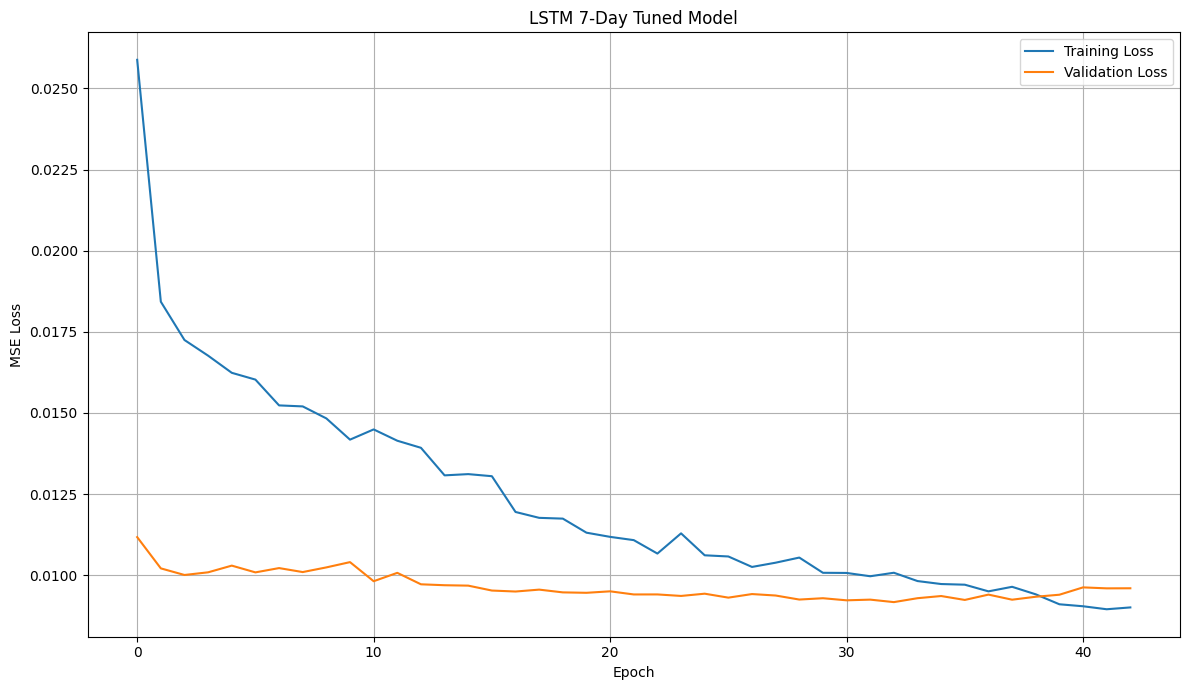

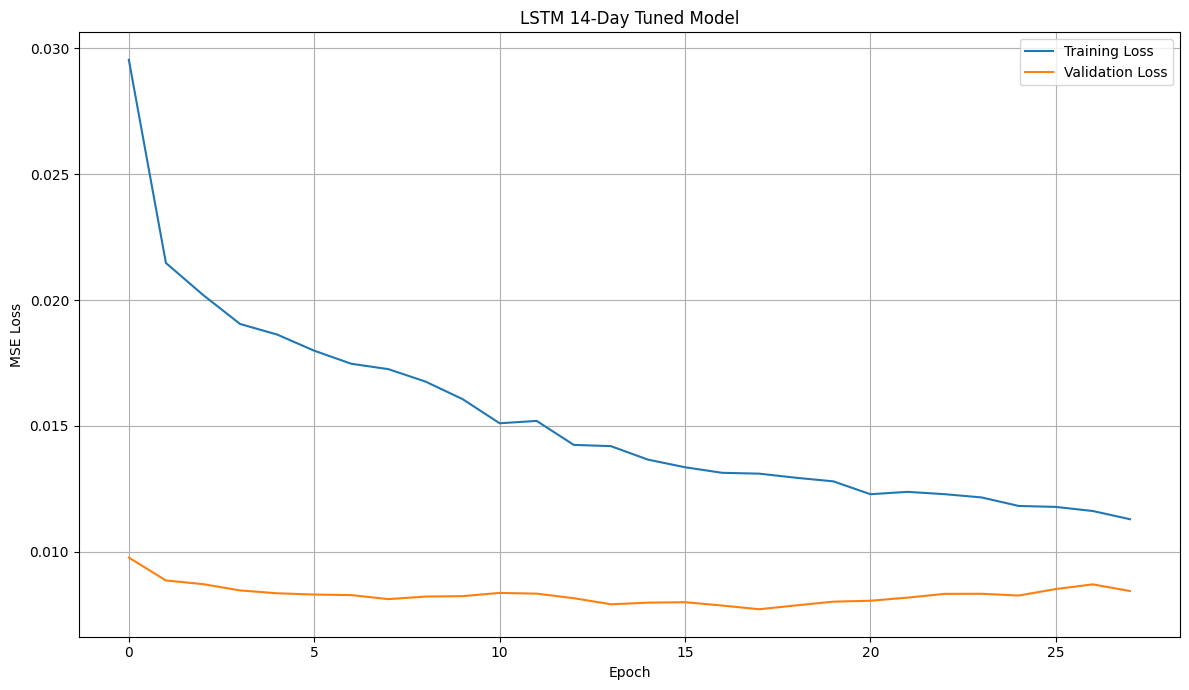

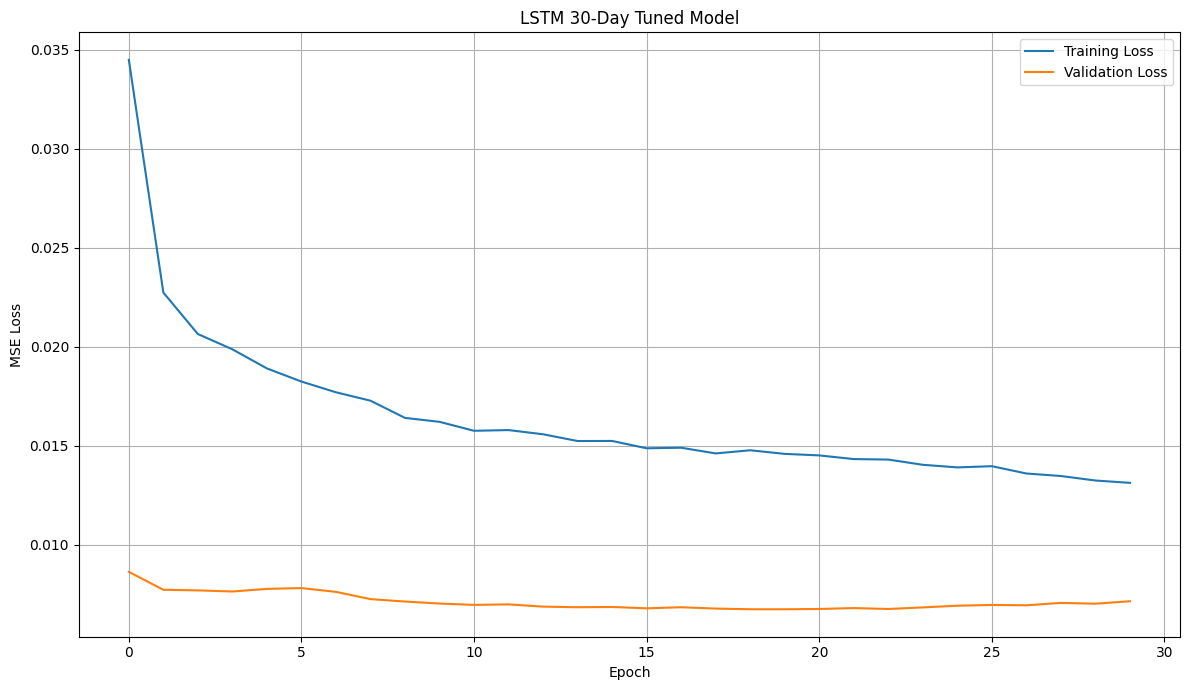

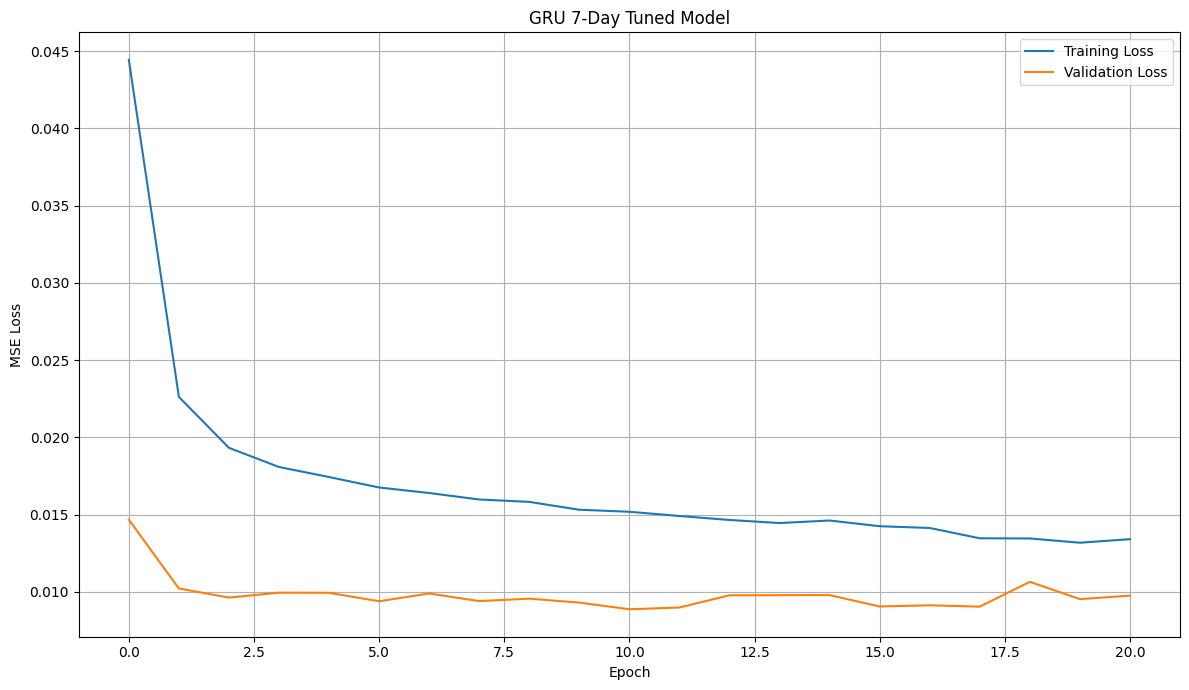

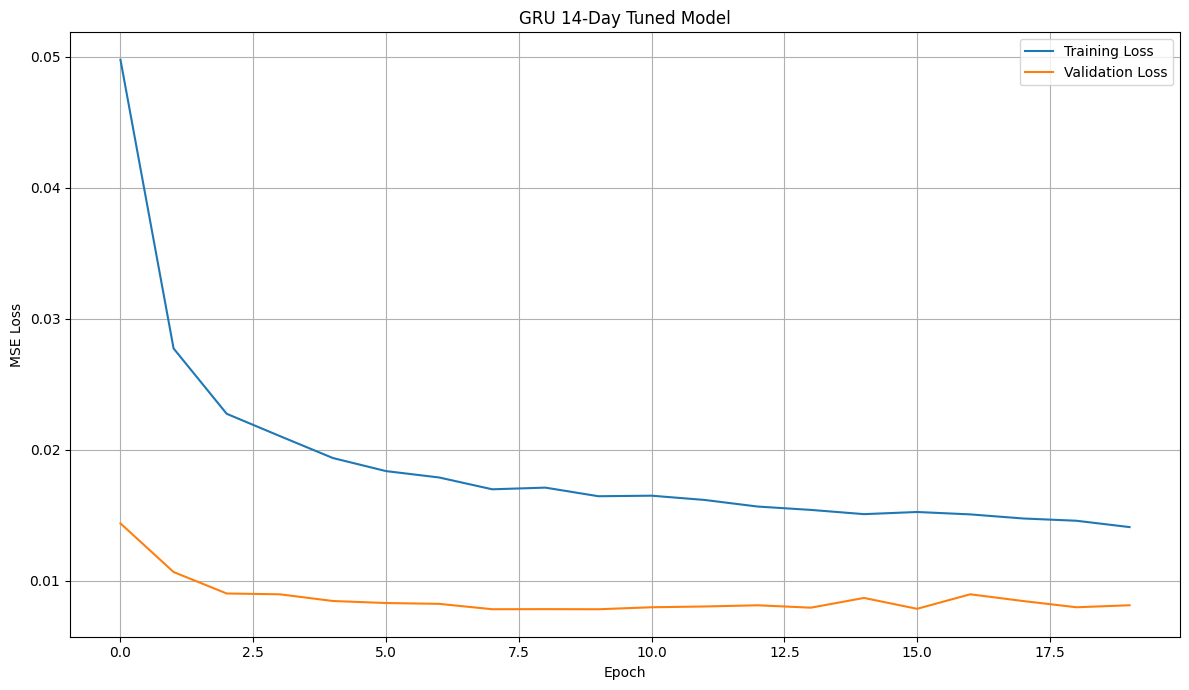

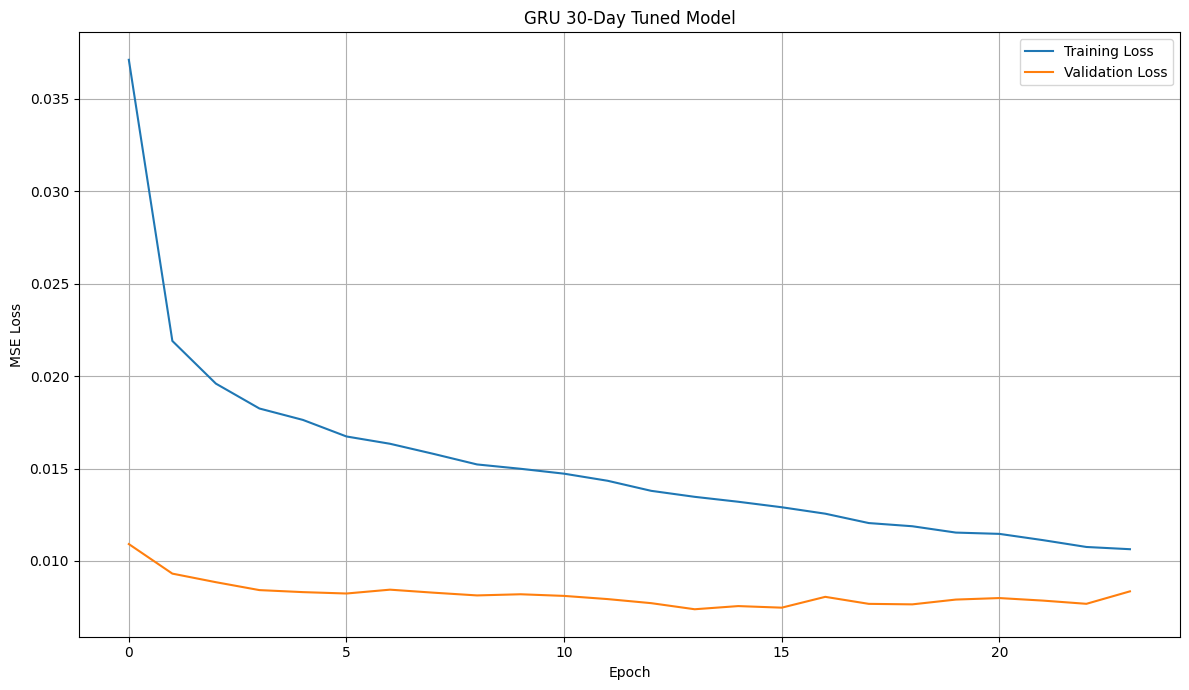

In [31]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:

        history = best_histories[(model_type, horizon)]

        plt.figure(figsize=(12, 6)) # Increased figure size

        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")

        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"{model_type} {horizon}-Day Tuned Model")
        plt.grid(True)
        plt.legend()
        plt.tight_layout() # Added for better spacing
        plt.show()


## 14. Visualizing Model Learning: Training and Validation Loss

These plots show how the training and validation loss changed over epochs for each of our best-tuned models. The **training loss** tells us how well the model is learning from the data it sees, while the **validation loss** indicates how well it generalizes to unseen data. Ideally, both should decrease and then level off, without the validation loss starting to increase (which would suggest overfitting).

# 15. Six evaluation metrics

The final test evaluation uses:

- **MBE** — Mean Bias Error
- **MSE** — Mean Squared Error
- **MAPE** — Mean Absolute Percentage Error
- **R²** — R-Squared
- **RMSE** — Root Mean Squared Error
- **MAE** — Mean Absolute Error

They are calculated both:
1. across the whole forecast horizon, and
2. separately for Day 1, Day 2, etc.

In [15]:
# ============================================================
# 15. METRIC FUNCTIONS
# ============================================================

def inverse_target(arr):
    arr = np.asarray(arr)
    shape = arr.shape

    return target_scaler.inverse_transform(
        arr.reshape(-1, 1)
    ).reshape(shape)


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0

    if not np.any(mask):
        return np.nan

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )


def calculate_all_metrics(y_true, y_pred):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mse = mean_squared_error(y_true, y_pred)

    return {
        "MBE": np.mean(y_pred - y_true),
        "MSE": mse,
        "MAPE (%)": safe_mape(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

## 16. Defining Performance Metrics

This section contains the custom functions we'll use to evaluate our models. It includes a function to `inverse_target` (converting our scaled predictions back to actual PM2.5 values) and `safe_mape` (calculating Mean Absolute Percentage Error while handling zero true values). The `calculate_all_metrics` function then bundles together the calculation of all six key performance metrics: Mean Bias Error (MBE), Mean Squared Error (MSE), MAPE, R-squared (R²), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

In [16]:
# ============================================================
# 16. FINAL TEST-SET EVALUATION
# ============================================================

overall_metrics = []
daily_metrics = []
predictions = {}

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        model = best_models[(model_type, horizon)]

        X_test = datasets[horizon]["test"]["X"]
        y_test_scaled = datasets[horizon]["test"]["y"]

        # Predict the complete future horizon
        y_pred_scaled = model.predict(
            X_test,
            verbose=0
        )

        y_true = inverse_target(y_test_scaled)
        y_pred = inverse_target(y_pred_scaled)

        predictions[(model_type, horizon)] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "dates": datasets[horizon]["test"]["dates"]
        }

        # Overall metrics
        metrics = calculate_all_metrics(
            y_true,
            y_pred
        )

        metrics.update({
            "Model": model_type,
            "Horizon": horizon
        })

        overall_metrics.append(metrics)

        # Metrics for each future day
        for day in range(horizon):

            day_metrics = calculate_all_metrics(
                y_true[:, day],
                y_pred[:, day]
            )

            day_metrics.update({
                "Model": model_type,
                "Horizon": horizon,
                "Forecast_Day": day + 1
            })

            daily_metrics.append(day_metrics)


overall_metrics_df = pd.DataFrame(overall_metrics)
daily_metrics_df = pd.DataFrame(daily_metrics)

overall_metrics_df = overall_metrics_df[
    ["Model", "Horizon", "MBE", "MSE",
     "MAPE (%)", "R²", "RMSE", "MAE"]
]

daily_metrics_df = daily_metrics_df[
    ["Model", "Horizon", "Forecast_Day",
     "MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]
]

print("OVERALL TEST PERFORMANCE")
display(overall_metrics_df)

OVERALL TEST PERFORMANCE


,Model,Horizon,MBE,MSE,MAPE (%),R²,RMSE,MAE
0,LSTM,7,-1.239134,25.159337,39.861884,0.040753,5.015908,3.436305
1,LSTM,14,-1.987657,30.749176,39.471302,-0.129949,5.545194,3.715748
2,LSTM,30,-2.656347,34.881026,35.637372,-0.209266,5.906016,3.763189
3,GRU,7,-1.274463,25.819719,42.984895,0.015575,5.081311,3.569732
4,GRU,14,-1.419457,28.260171,41.483365,-0.038485,5.316030,3.582326
5,GRU,30,-4.478873,48.975015,46.707423,-0.697881,6.998215,4.937678


## 17. Final Evaluation on Unseen Test Data

Now, we take our best-performing models (one for each model type and horizon) and use them to make predictions on the completely unseen **test set**. This section calculates all six performance metrics for these predictions, both across the entire forecast horizon (overall) and for each individual day within the forecast. This gives us a rigorous, unbiased assessment of our models' real-world performance.

In [17]:
# ============================================================
# 17. BEST MODEL FOR EACH HORIZON
# ============================================================

best_by_horizon = (
    overall_metrics_df
    .sort_values("RMSE")
    .groupby("Horizon", as_index=False)
    .first()
)

display(best_by_horizon)

,Horizon,Model,MBE,MSE,MAPE (%),R²,RMSE,MAE
0,7,LSTM,-1.239134,25.159337,39.861884,0.040753,5.015908,3.436305
1,14,GRU,-1.419457,28.260171,41.483365,-0.038485,5.316030,3.582326
2,30,LSTM,-2.656347,34.881026,35.637372,-0.209266,5.906016,3.763189


## 18. Identifying the Top Model for Each Forecast Horizon

This section takes the overall performance metrics calculated on the test set and identifies which model (LSTM or GRU) performed best for each specific forecast horizon (7, 14, and 30 days) based on the Root Mean Squared Error (RMSE) metric. It then displays a concise table summarizing these top performers.

In [18]:
# ============================================================
# 18. PER-DAY PERFORMANCE
# ============================================================

for horizon in HORIZONS:

    print(f"\n===== {horizon}-DAY FORECAST =====")

    display(
        daily_metrics_df[
            daily_metrics_df["Horizon"] == horizon
        ]
    )


===== 7-DAY FORECAST =====


,Model,Horizon,Forecast_Day,MBE,MSE,MAPE (%),R²,RMSE,MAE
0,LSTM,7,1,-0.979692,19.478146,36.498536,0.251545,4.413405,3.077035
1,LSTM,7,2,-0.249828,21.223092,44.322840,0.184282,4.606853,3.404293
2,LSTM,7,3,-1.597558,26.092852,39.048435,0.006436,5.108116,3.508995
3,LSTM,7,4,-1.088139,25.265221,41.317958,0.036741,5.026452,3.488845
4,LSTM,7,5,-1.265690,26.401910,39.894623,-0.006596,5.138279,3.461792
5,LSTM,7,6,-1.670122,28.342828,39.296265,-0.075292,5.323798,3.557235
6,LSTM,7,7,-1.822907,29.311314,38.654533,-0.107459,5.413992,3.555943
51,GRU,7,1,-1.960410,22.607106,38.620892,0.131314,4.754693,3.413006
52,GRU,7,2,-0.825080,21.810661,42.556581,0.161699,4.670189,3.391501
53,GRU,7,3,-0.572476,23.807736,46.372103,0.093448,4.879317,3.571180



===== 14-DAY FORECAST =====


,Model,Horizon,Forecast_Day,MBE,MSE,MAPE (%),R²,RMSE,MAE
7,LSTM,14,1,-0.401103,22.525330,45.217540,0.165705,4.746086,3.547303
8,LSTM,14,2,-0.974572,24.010677,42.091684,0.114431,4.900069,3.483299
9,LSTM,14,3,-2.001826,28.059929,36.888617,-0.035054,5.297162,3.503373
10,LSTM,14,4,-1.612541,27.650825,40.157045,-0.019837,5.258405,3.573431
11,LSTM,14,5,-1.474723,29.404420,40.672666,-0.082264,5.422584,3.654759
12,LSTM,14,6,-1.537189,29.136620,40.836352,-0.074360,5.397835,3.662314
13,LSTM,14,7,-1.201015,27.297821,40.890482,-0.007945,5.224732,3.545220
14,LSTM,14,8,-2.681522,33.884550,36.944313,-0.252123,5.821044,3.767702
15,LSTM,14,9,-2.260421,33.065661,39.030560,-0.222403,5.750275,3.811249
16,LSTM,14,10,-2.664384,34.744801,38.961581,-0.270865,5.894472,3.920028



===== 30-DAY FORECAST =====


,Model,Horizon,Forecast_Day,MBE,MSE,MAPE (%),R²,RMSE,MAE
21,LSTM,30,1,-1.845475,25.979377,31.890422,0.049662,5.096997,3.298073
22,LSTM,30,2,-1.832757,27.345703,33.325861,-0.002590,5.229312,3.424184
23,LSTM,30,3,-1.934858,28.915254,33.399872,-0.057259,5.377291,3.477035
24,LSTM,30,4,-2.895246,35.019152,31.917141,-0.275867,5.917698,3.689870
25,LSTM,30,5,-3.384095,37.255929,32.240511,-0.358254,6.103764,3.846707
26,LSTM,30,6,-2.431083,32.267327,33.486619,-0.163273,5.680434,3.583226
27,LSTM,30,7,-2.695624,34.089611,33.912704,-0.214114,5.838631,3.648017
28,LSTM,30,8,-2.735753,35.106582,34.528584,-0.241654,5.925081,3.714130
29,LSTM,30,9,-2.166364,31.959828,36.533987,-0.121062,5.653302,3.599485
30,LSTM,30,10,-2.732632,35.385259,36.329586,-0.232070,5.948551,3.787761


## 19. Detailed Per-Day Performance Analysis

Beyond overall metrics, it's insightful to see how well our models perform for each individual day within the forecast horizon. This section displays a series of tables, one for each forecast horizon, showing all six evaluation metrics (MBE, MSE, MAPE, R², RMSE, MAE) for Day 1, Day 2, up to Day 7, Day 14, or Day 30. This helps us understand if performance degrades as we predict further into the future.

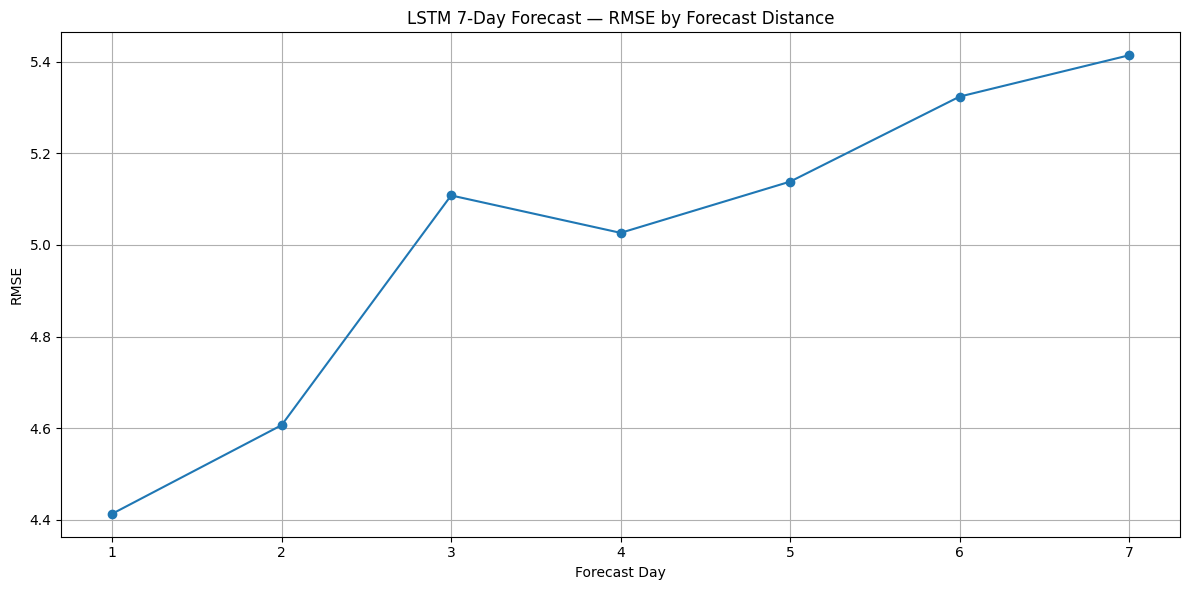

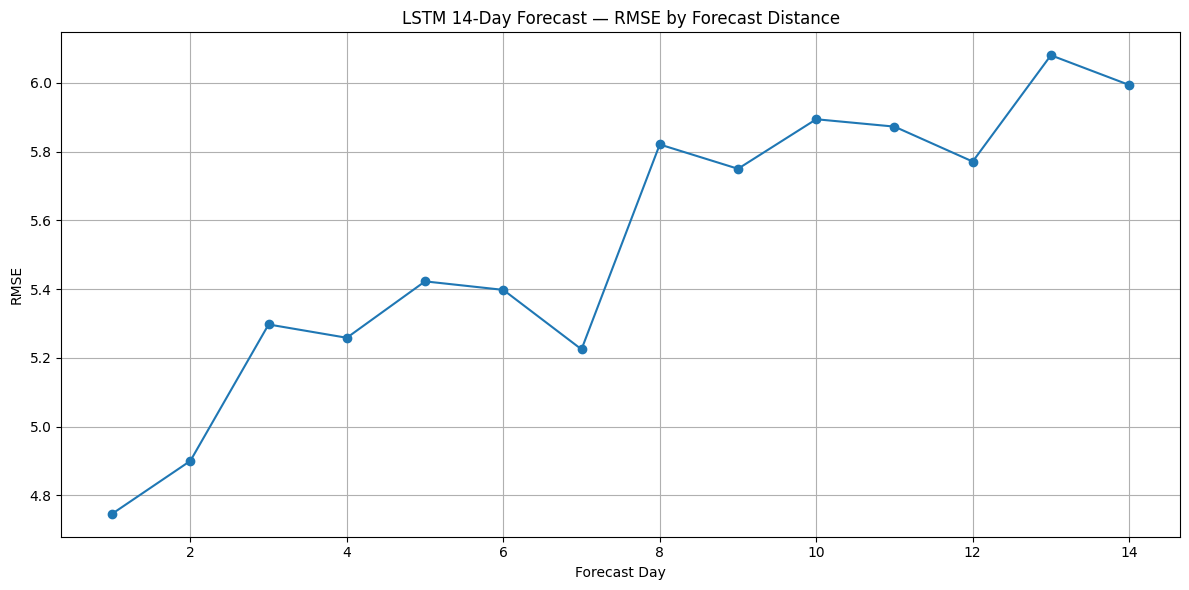

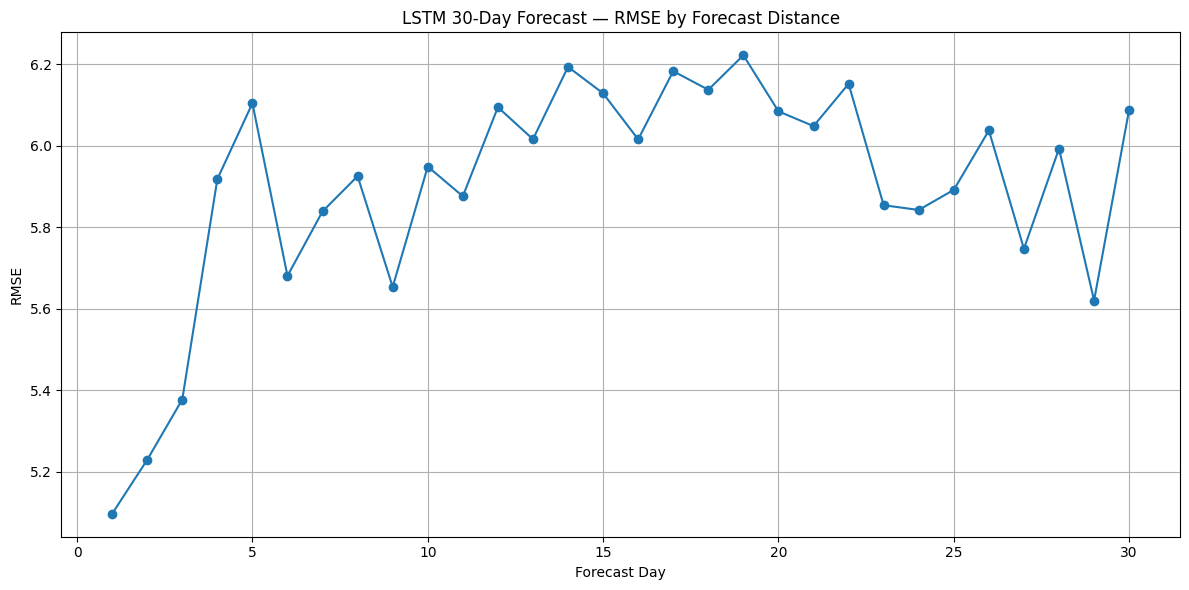

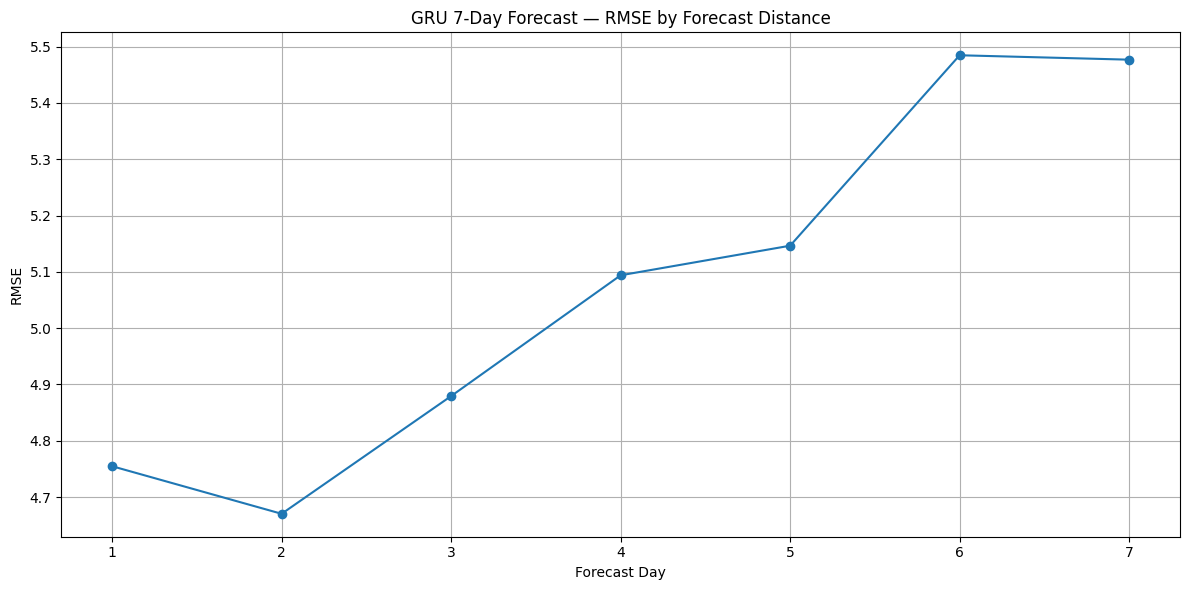

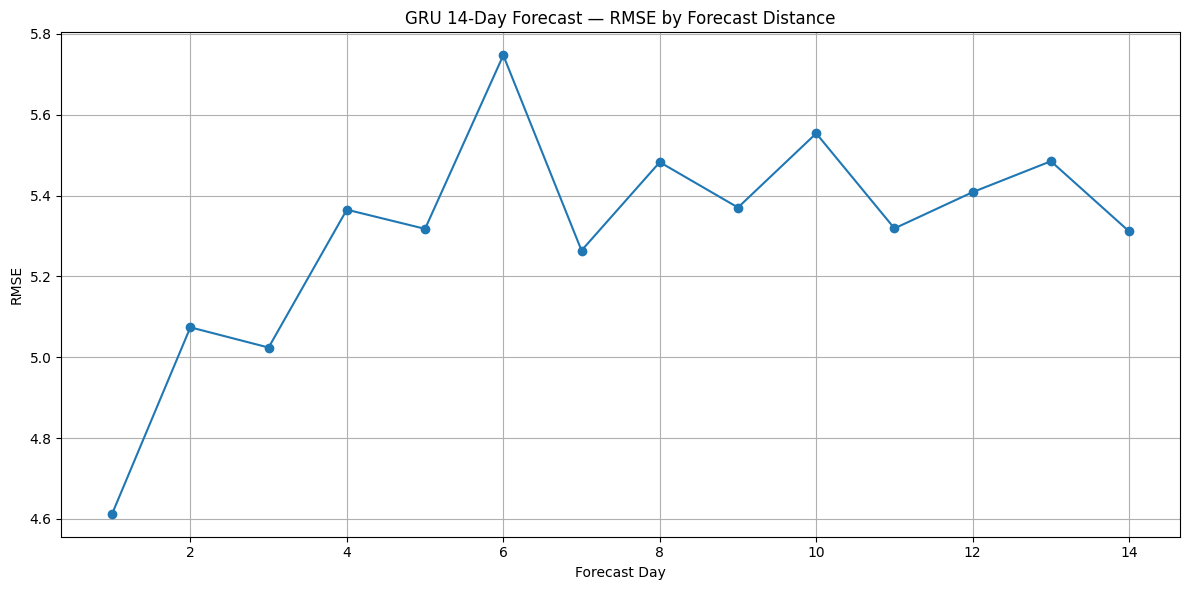

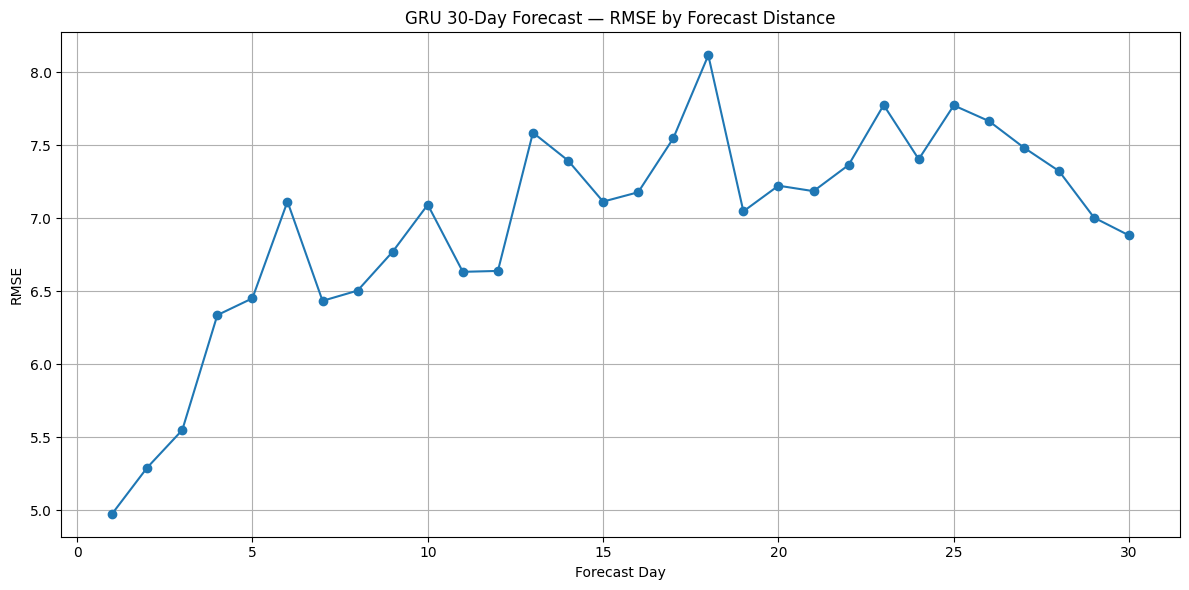

In [28]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        subset = daily_metrics_df[
            (daily_metrics_df["Model"] == model_type) &
            (daily_metrics_df["Horizon"] == horizon)
        ]

        plt.figure(figsize=(12, 6)) # Increased figure size

        plt.plot(
            subset["Forecast_Day"],
            subset["RMSE"],
            marker="o"
        )

        plt.xlabel("Forecast Day")
        plt.ylabel("RMSE")
        plt.title(
            f"{model_type} {horizon}-Day Forecast — "
            "RMSE by Forecast Distance"
        )
        plt.grid(True)
        plt.tight_layout() # Added for better spacing
        plt.show()


## 20. Visualizing RMSE by Forecast Distance

These plots illustrate how the Root Mean Squared Error (RMSE) changes as the forecast distance increases for each model (LSTM and GRU) and horizon. It helps us visually identify if the model's accuracy degrades significantly for predictions further into the future. Ideally, RMSE should remain relatively stable or increase predictably.

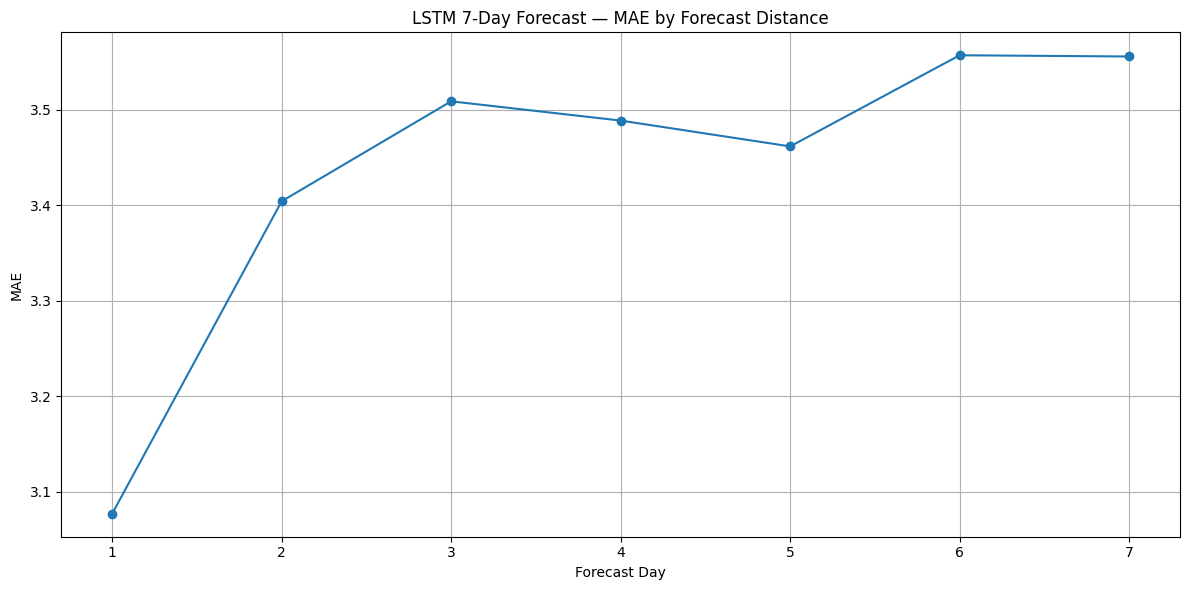

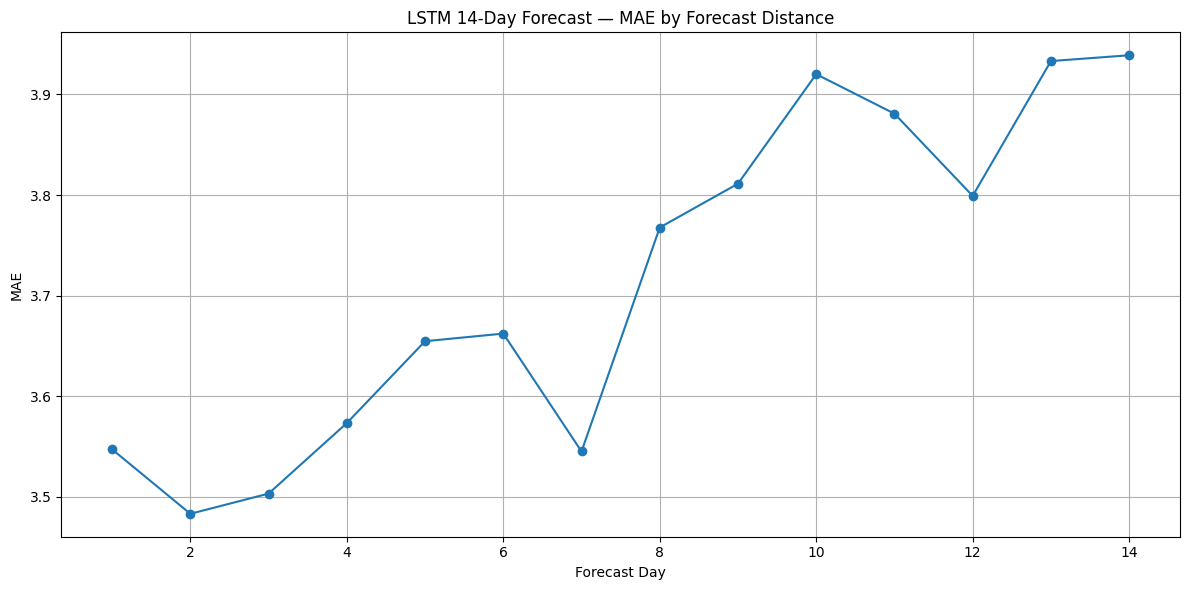

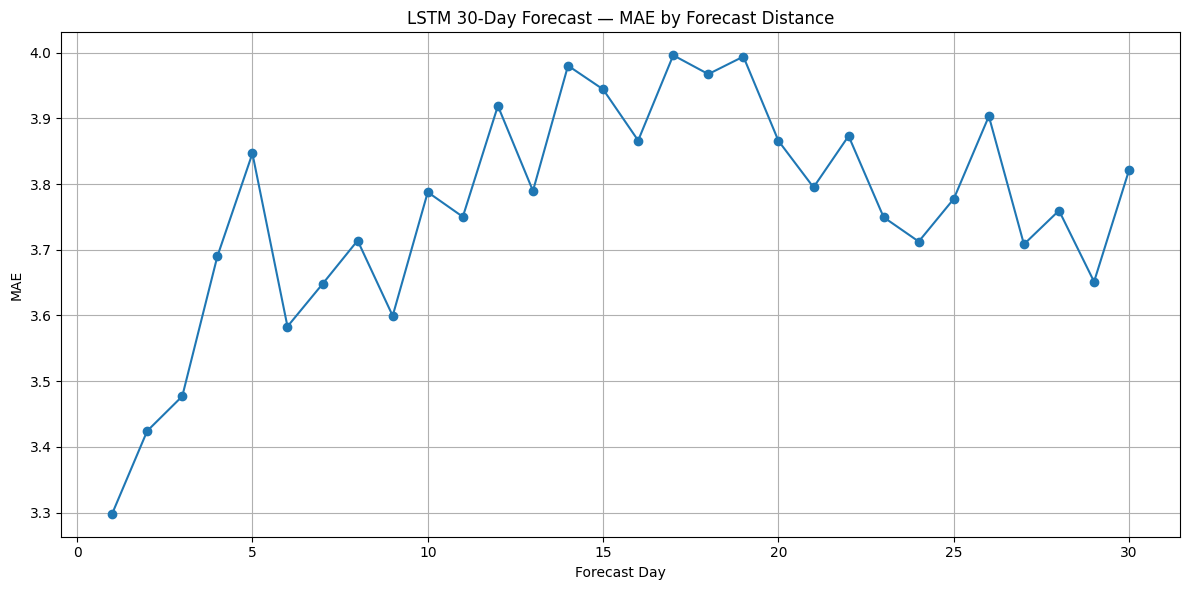

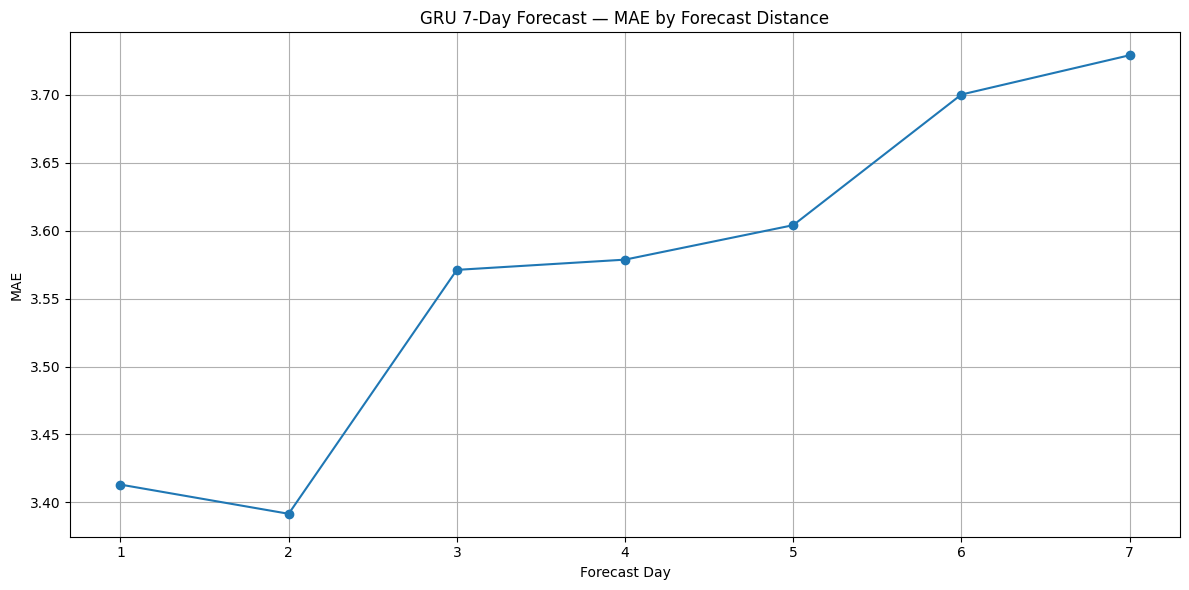

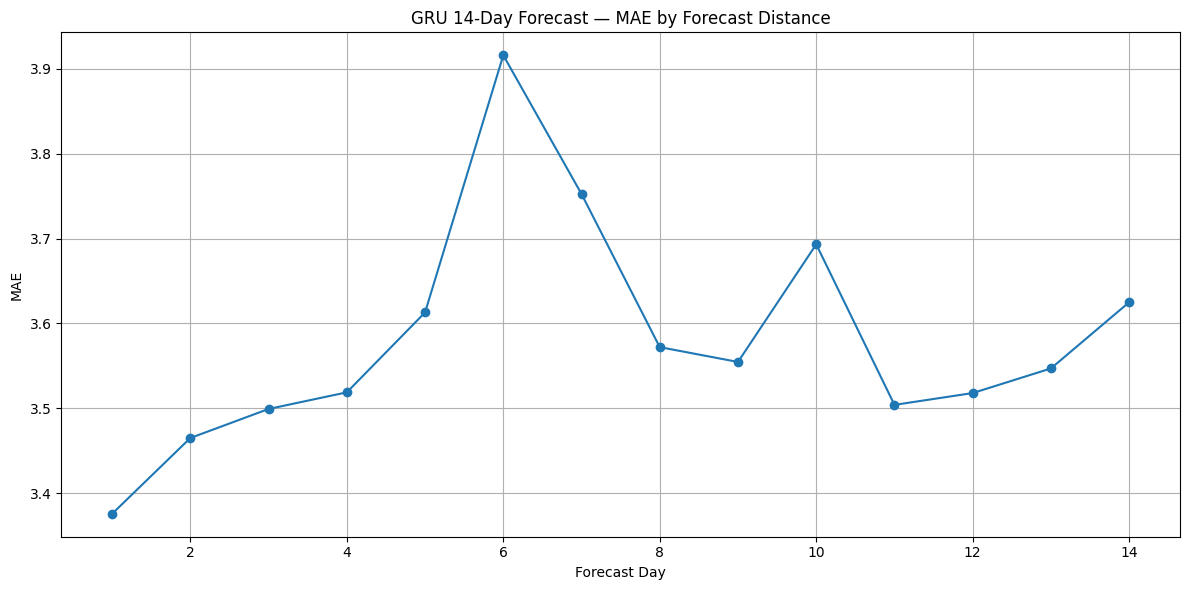

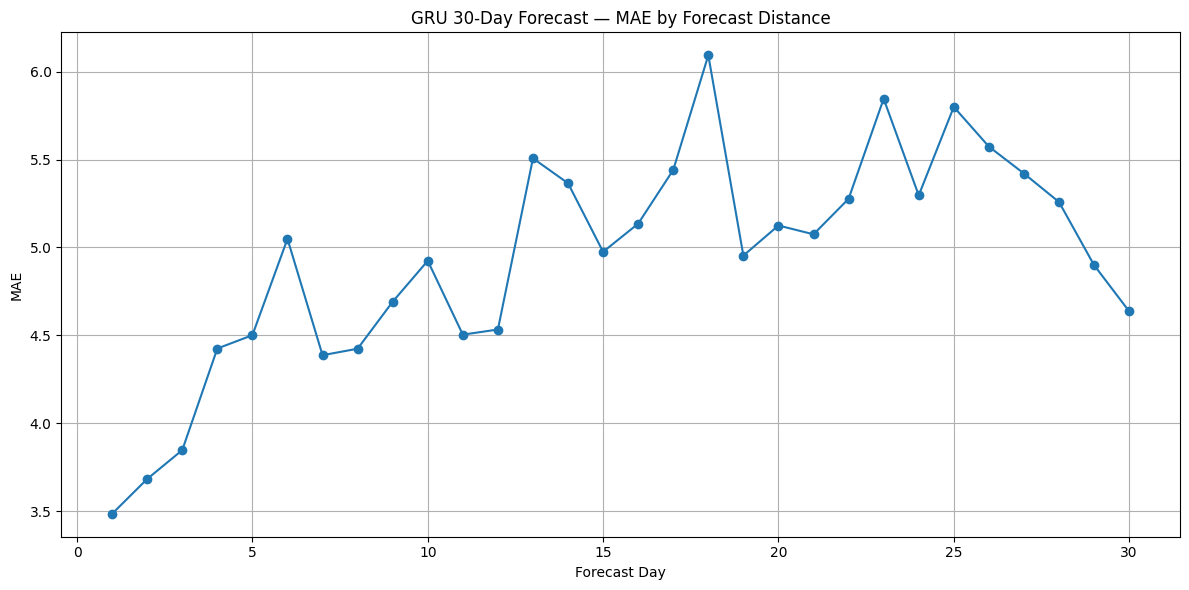

In [29]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        subset = daily_metrics_df[
            (daily_metrics_df["Model"] == model_type) &
            (daily_metrics_df["Horizon"] == horizon)
        ]

        plt.figure(figsize=(12, 6)) # Increased figure size

        plt.plot(
            subset["Forecast_Day"],
            subset["MAE"],
            marker="o"
        )

        plt.xlabel("Forecast Day")
        plt.ylabel("MAE")
        plt.title(
            f"{model_type} {horizon}-Day Forecast — "
            "MAE by Forecast Distance"
        )
        plt.grid(True)
        plt.tight_layout() # Added for better spacing
        plt.show()


## 21. Visualizing MAE by Forecast Distance

Similar to the RMSE plots, these charts show how the Mean Absolute Error (MAE) varies across different forecast days for each model and horizon. MAE gives us an average of the absolute magnitude of errors, providing another perspective on how prediction accuracy changes with increasing forecast distance.

### Mean Bias Error (MBE) by Forecast Distance

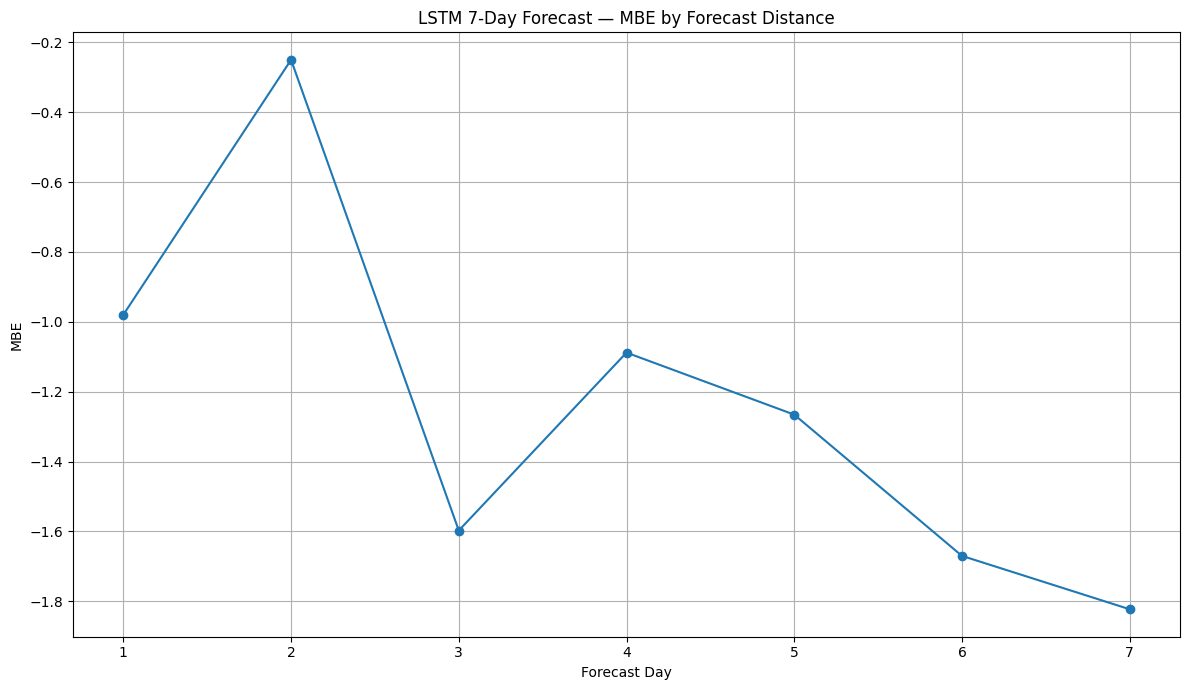

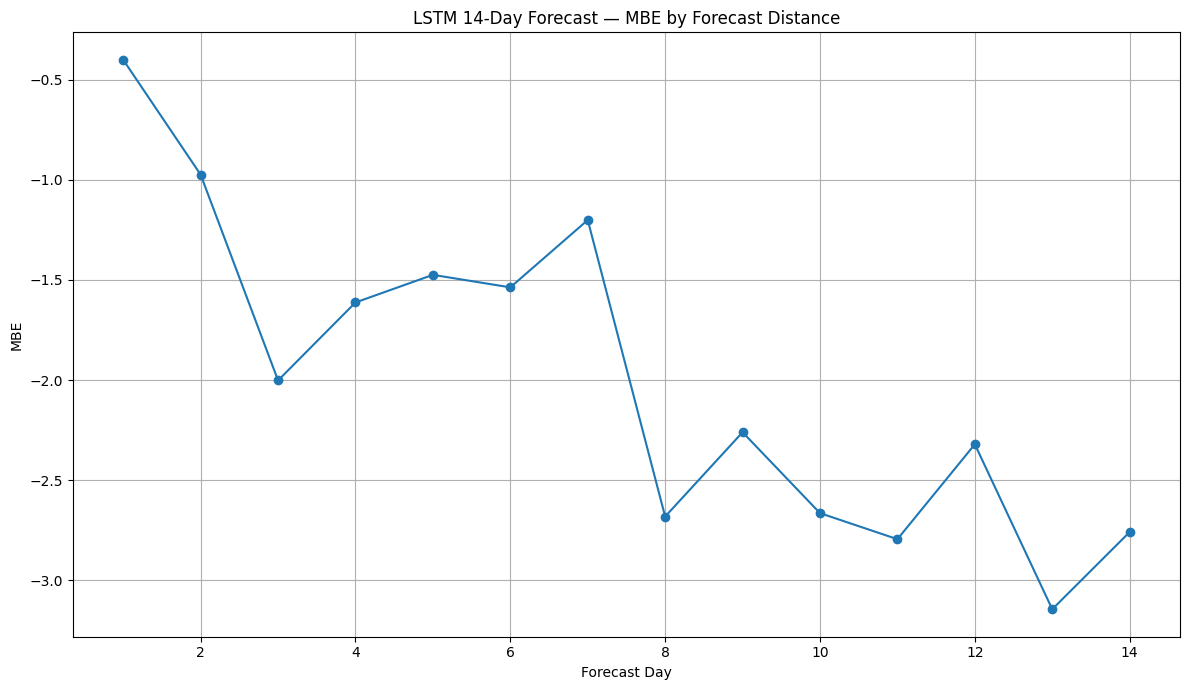

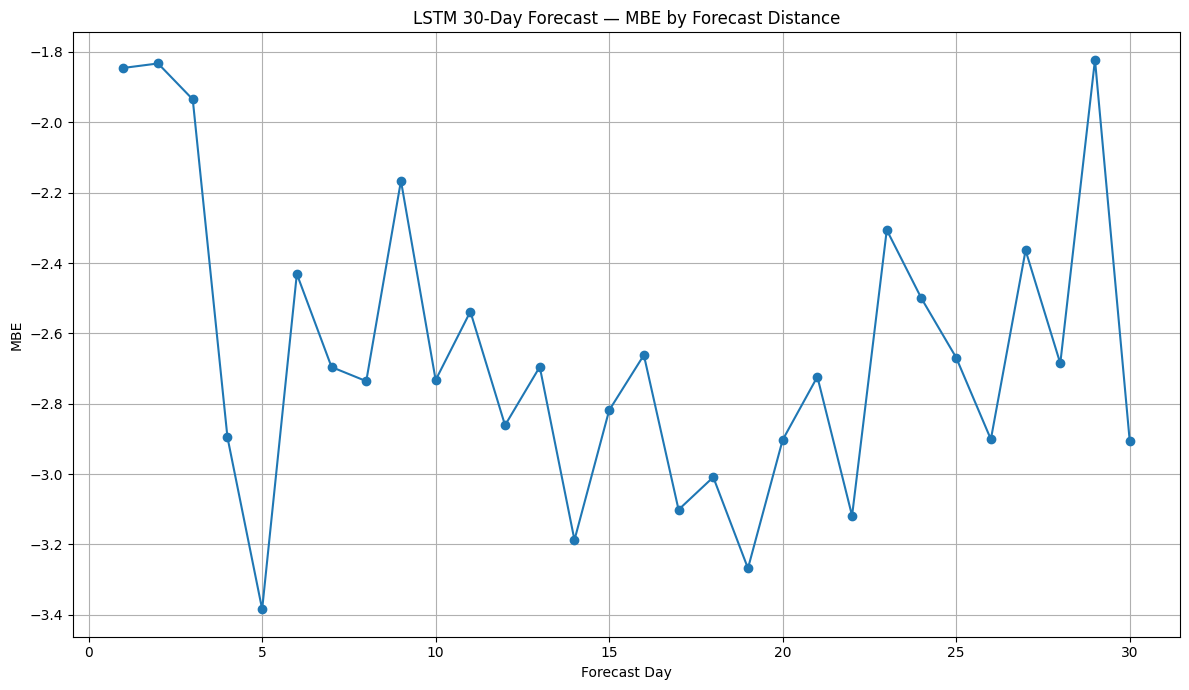

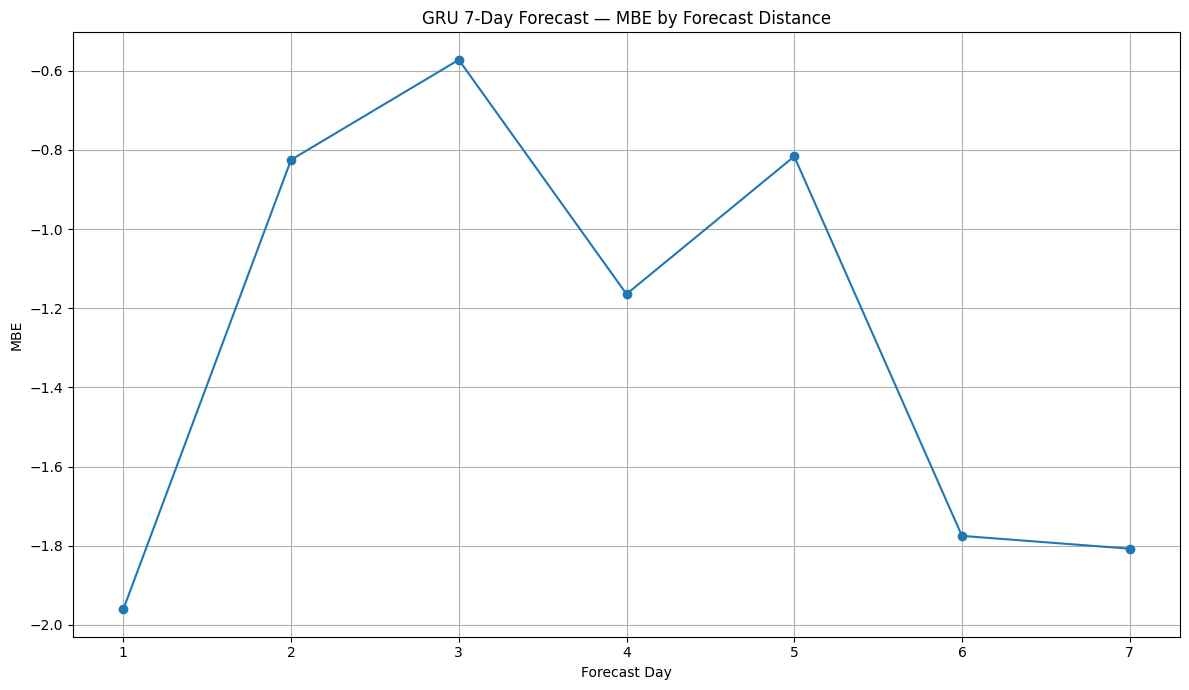

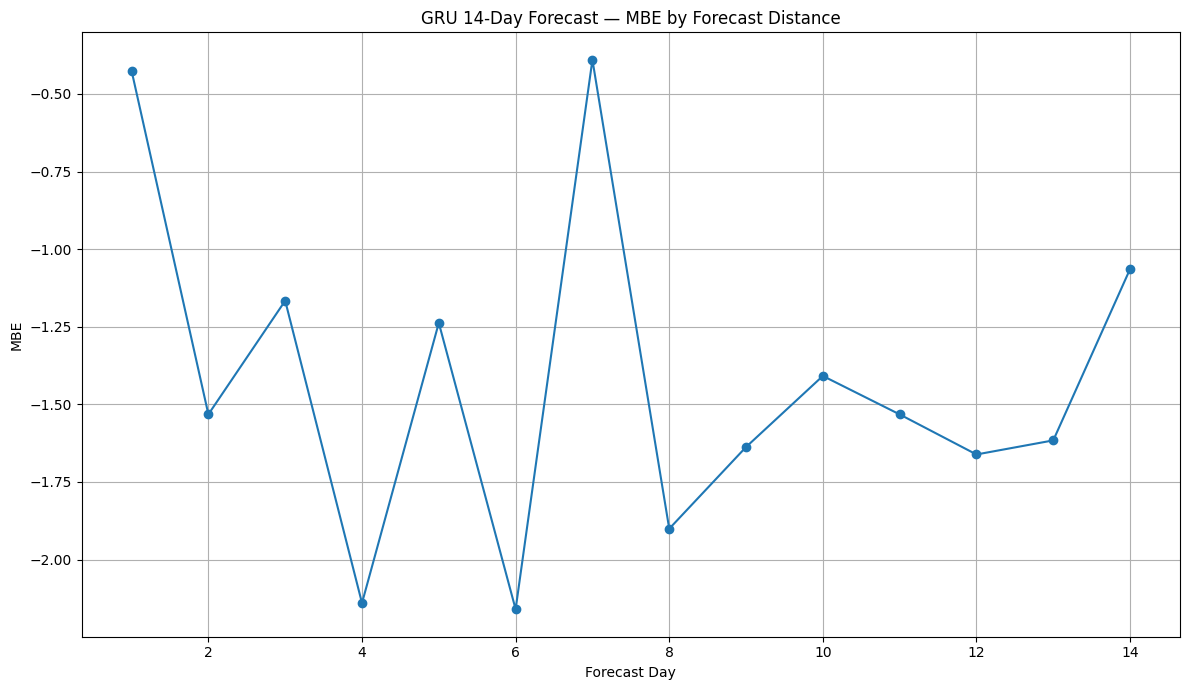

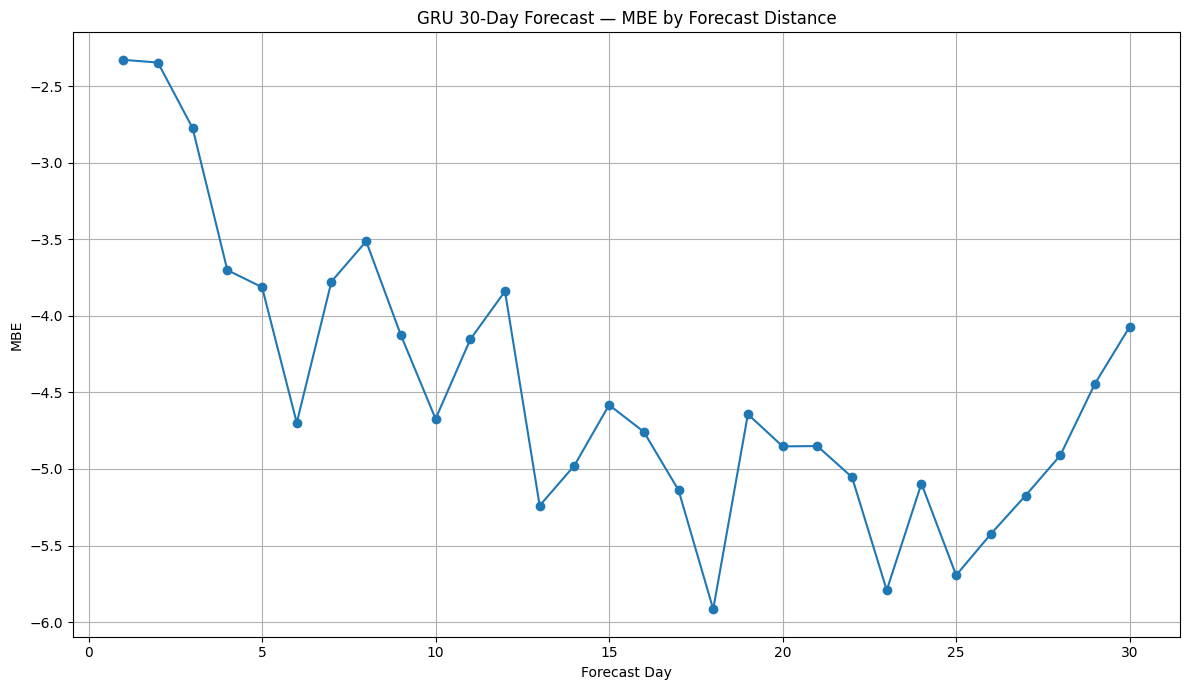

In [32]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        subset = daily_metrics_df[
            (daily_metrics_df["Model"] == model_type) &
            (daily_metrics_df["Horizon"] == horizon)
        ]

        plt.figure(figsize=(12, 7)) # Increased figure height for more separation

        plt.plot(
            subset["Forecast_Day"],
            subset["MBE"],
            marker="o"
        )

        plt.xlabel("Forecast Day")
        plt.ylabel("MBE")
        plt.title(
            f"{model_type} {horizon}-Day Forecast — "
            "MBE by Forecast Distance"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()


## 22. Visualizing Mean Bias Error (MBE) by Forecast Distance

These plots show the Mean Bias Error (MBE) for each forecast day within the given horizons. MBE indicates the average direction of the error – whether the model is consistently over-predicting (positive bias) or under-predicting (negative bias). A value close to zero suggests no systematic bias.

### Mean Squared Error (MSE) by Forecast Distance

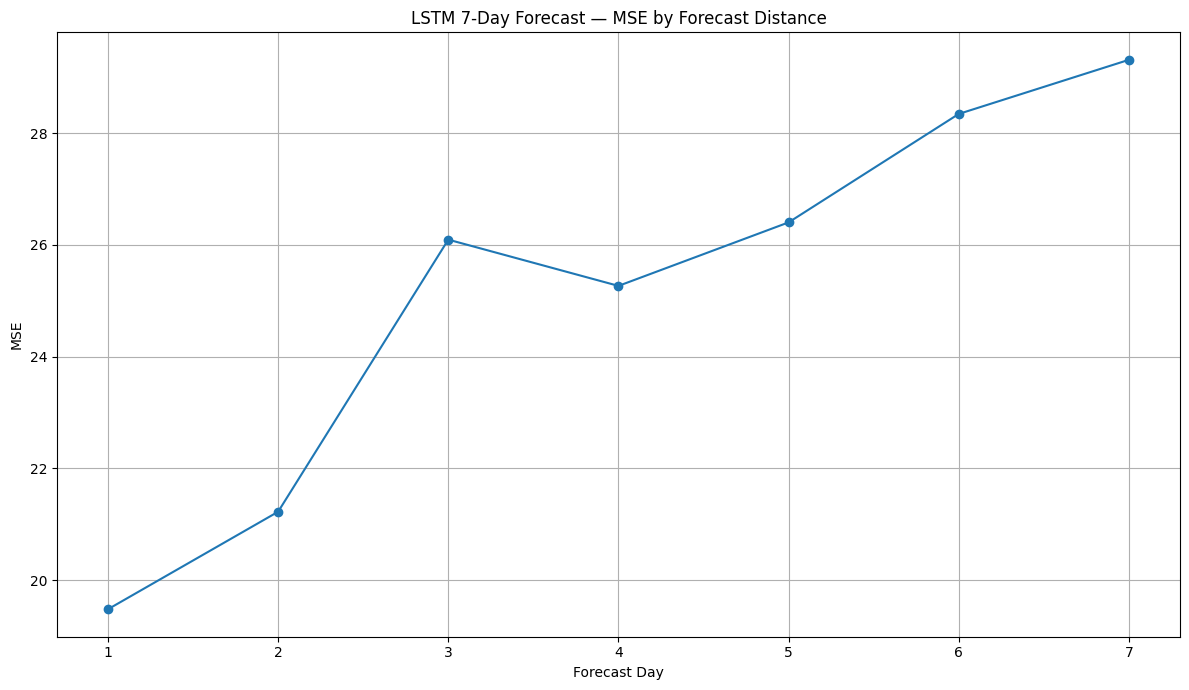

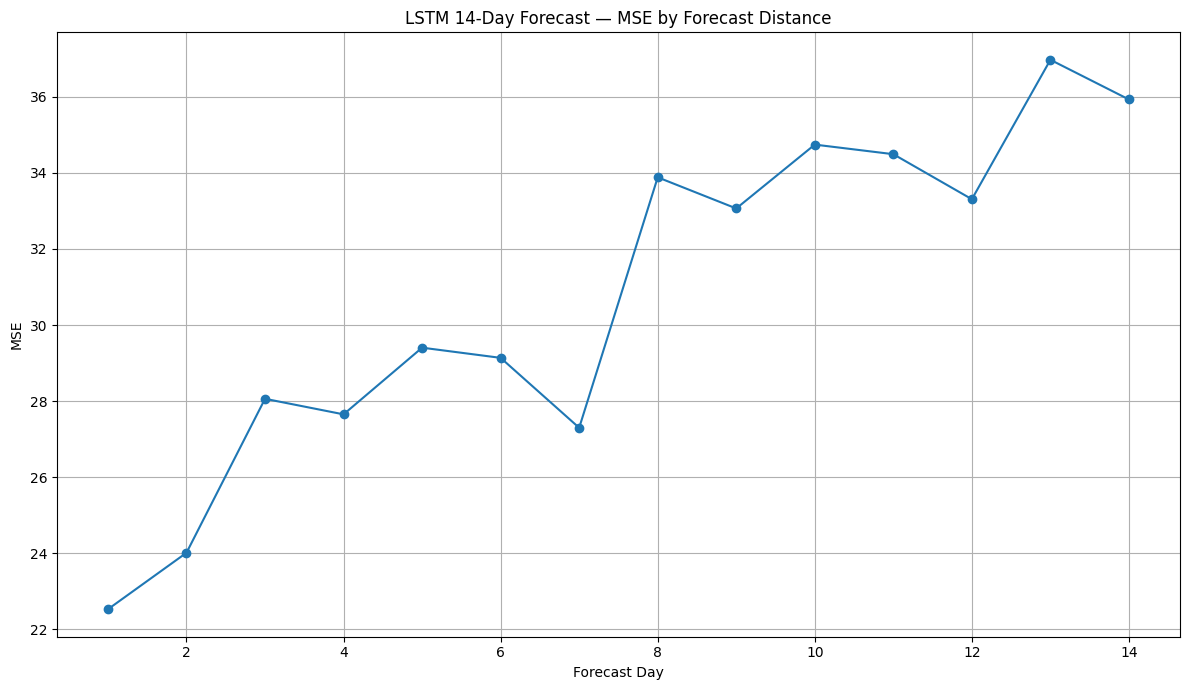

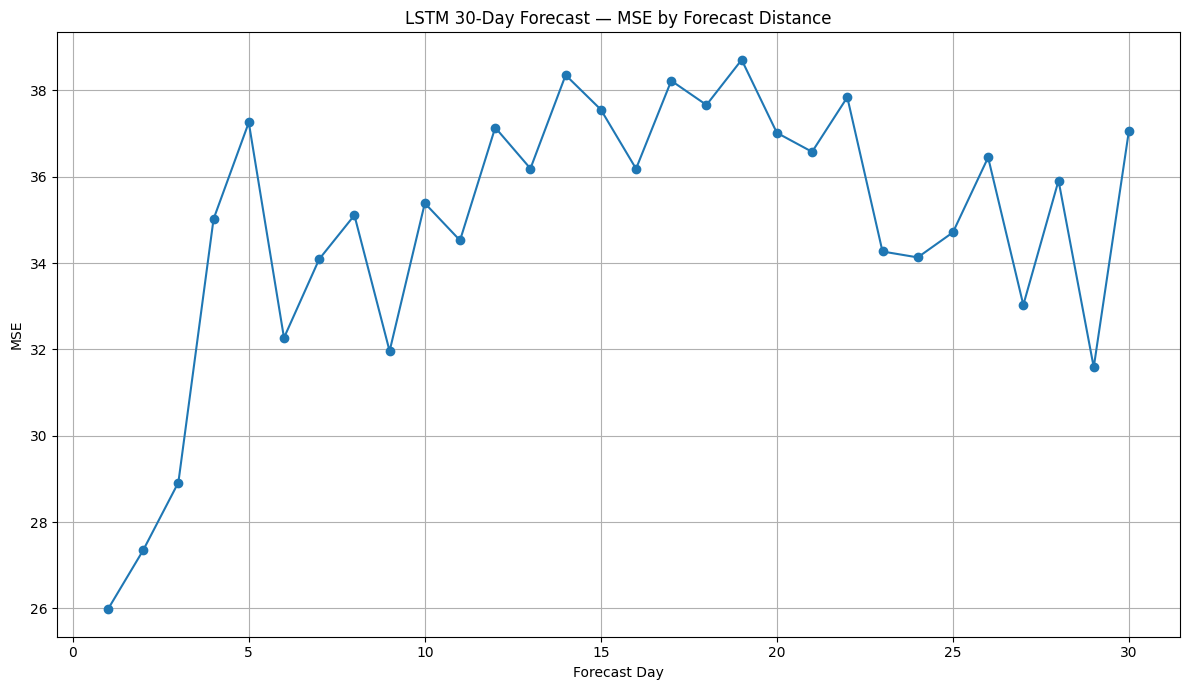

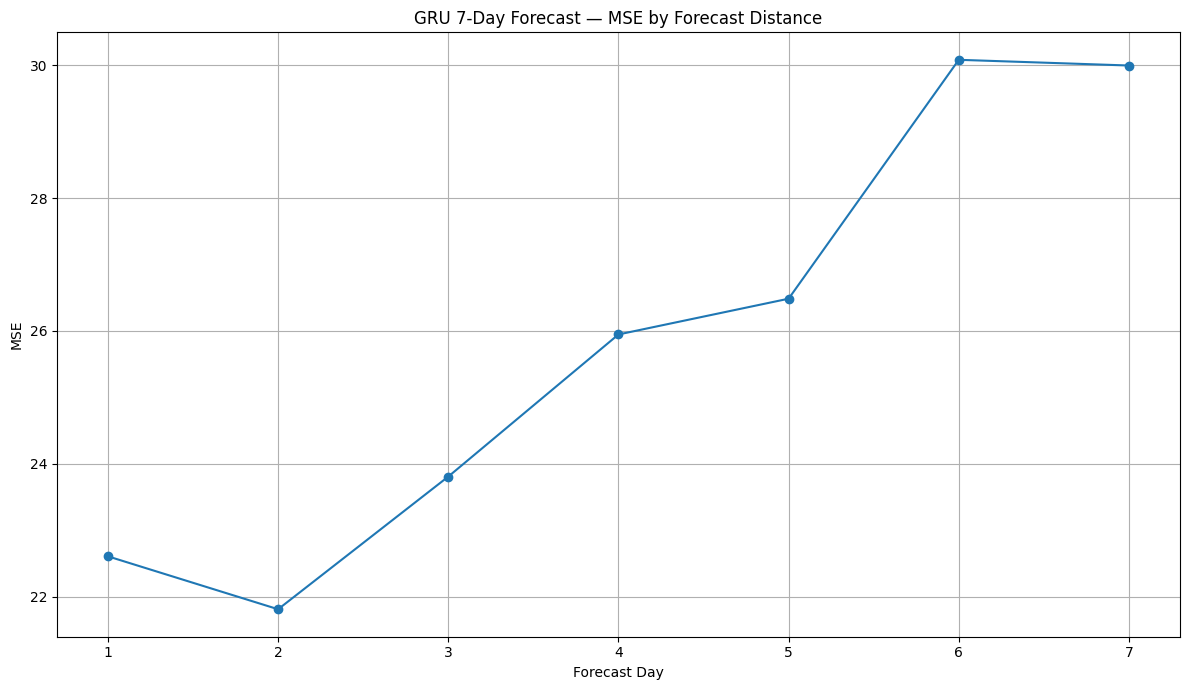

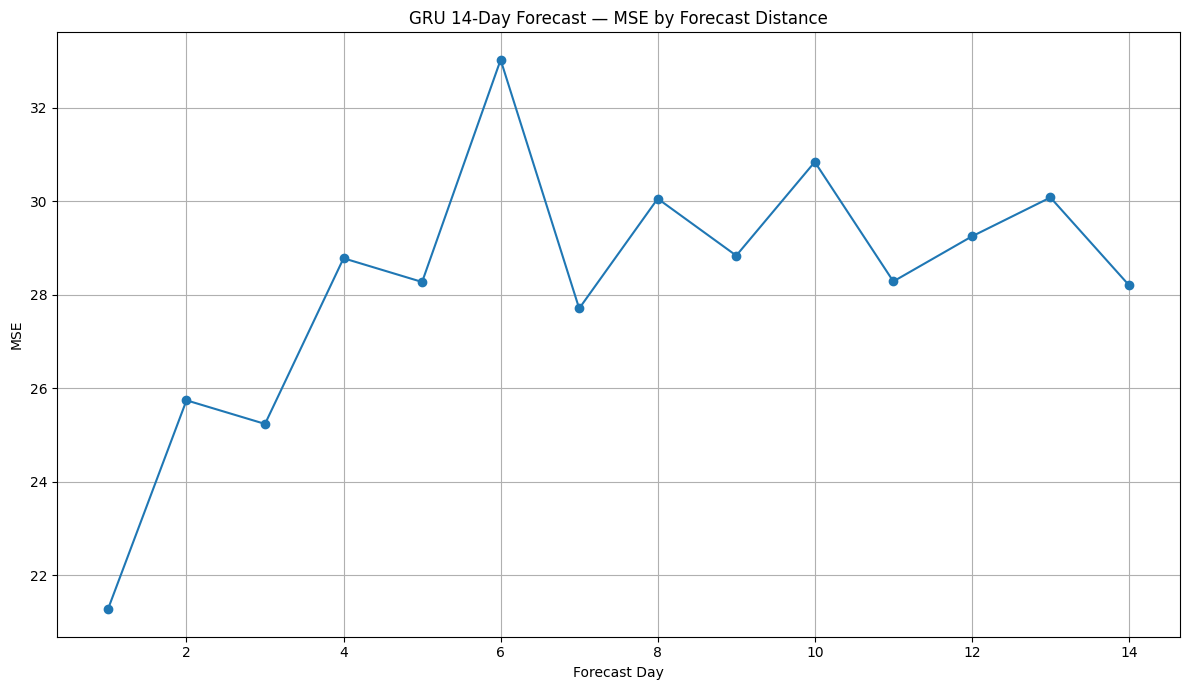

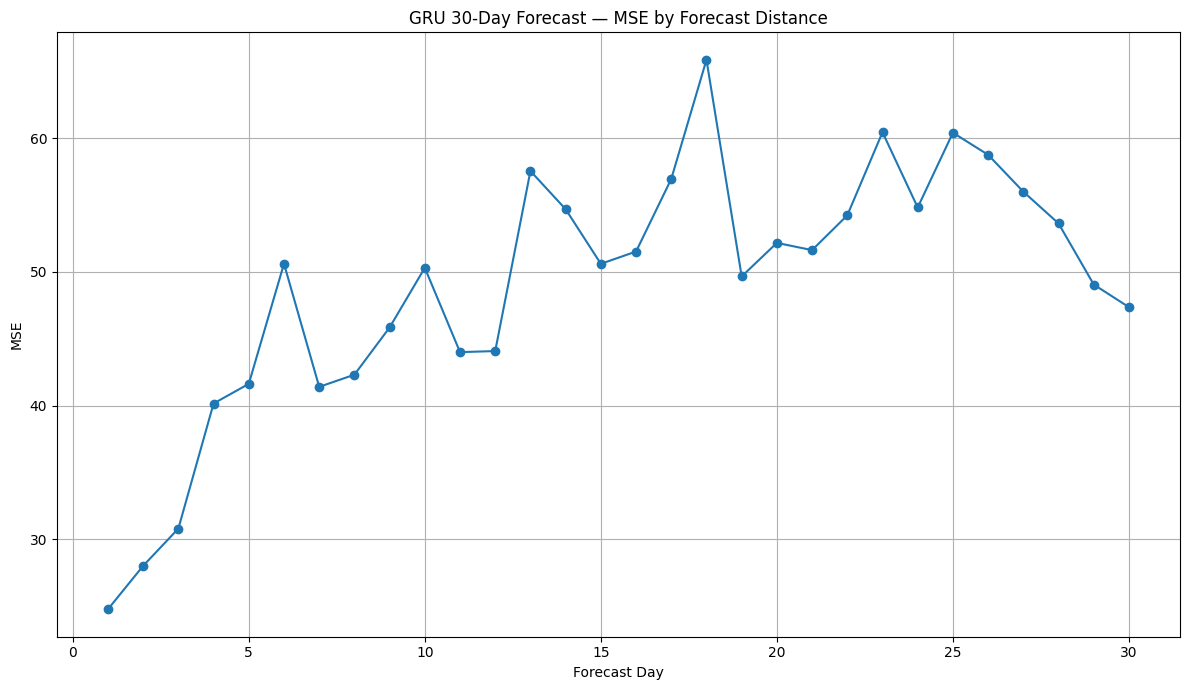

In [33]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        subset = daily_metrics_df[
            (daily_metrics_df["Model"] == model_type) &
            (daily_metrics_df["Horizon"] == horizon)
        ]

        plt.figure(figsize=(12, 7)) # Increased figure height for more separation

        plt.plot(
            subset["Forecast_Day"],
            subset["MSE"],
            marker="o"
        )

        plt.xlabel("Forecast Day")
        plt.ylabel("MSE")
        plt.title(
            f"{model_type} {horizon}-Day Forecast — "
            "MSE by Forecast Distance"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()


## 23. Visualizing Mean Squared Error (MSE) by Forecast Distance

These plots depict the Mean Squared Error (MSE) for each individual forecast day within the different horizons. MSE penalizes larger errors more heavily than smaller ones, giving us insight into the model's overall prediction quality and the presence of significant errors as the forecast distance grows.

### R-squared (R²) by Forecast Distance

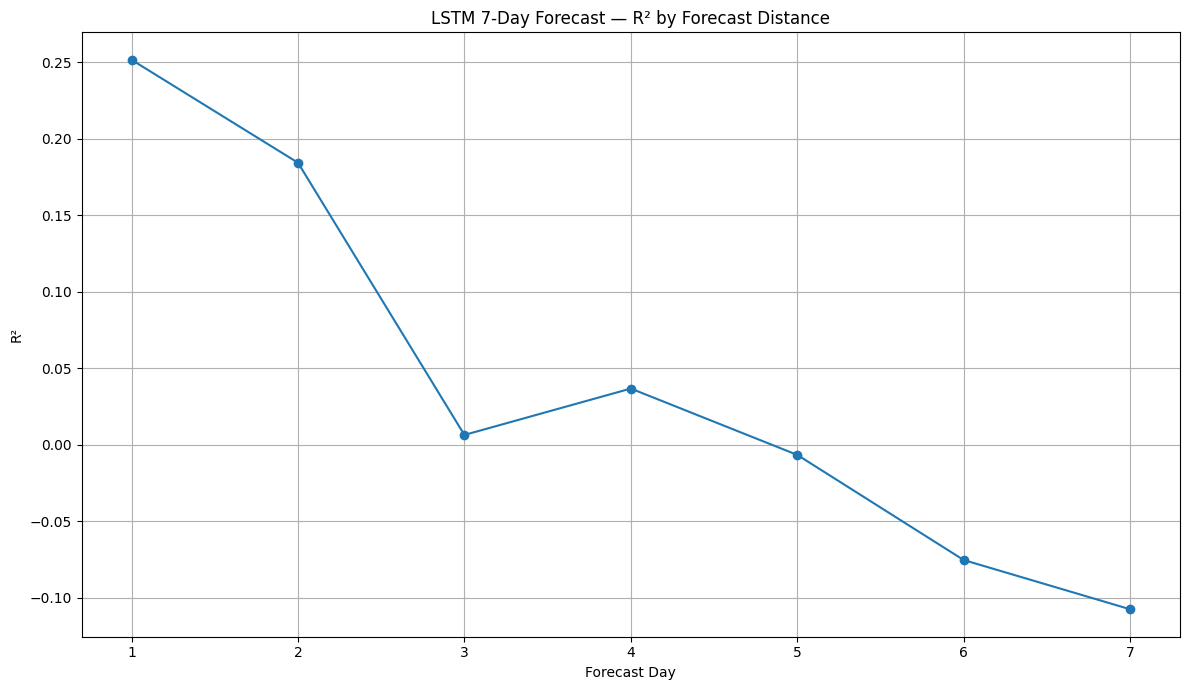

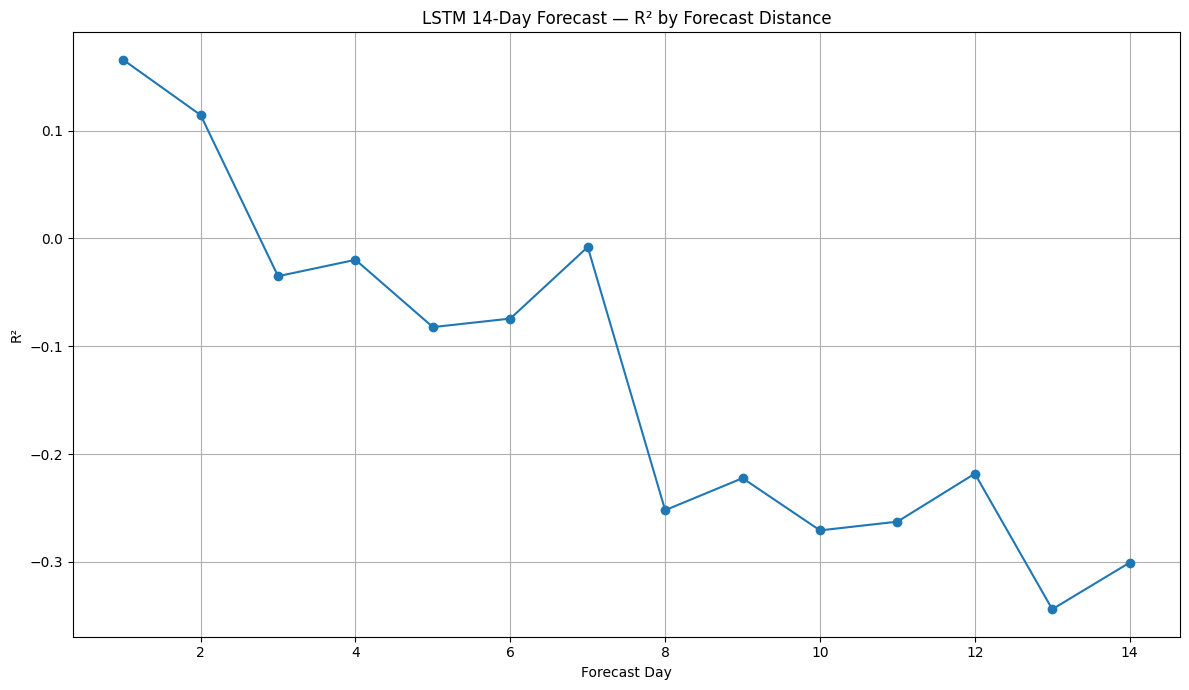

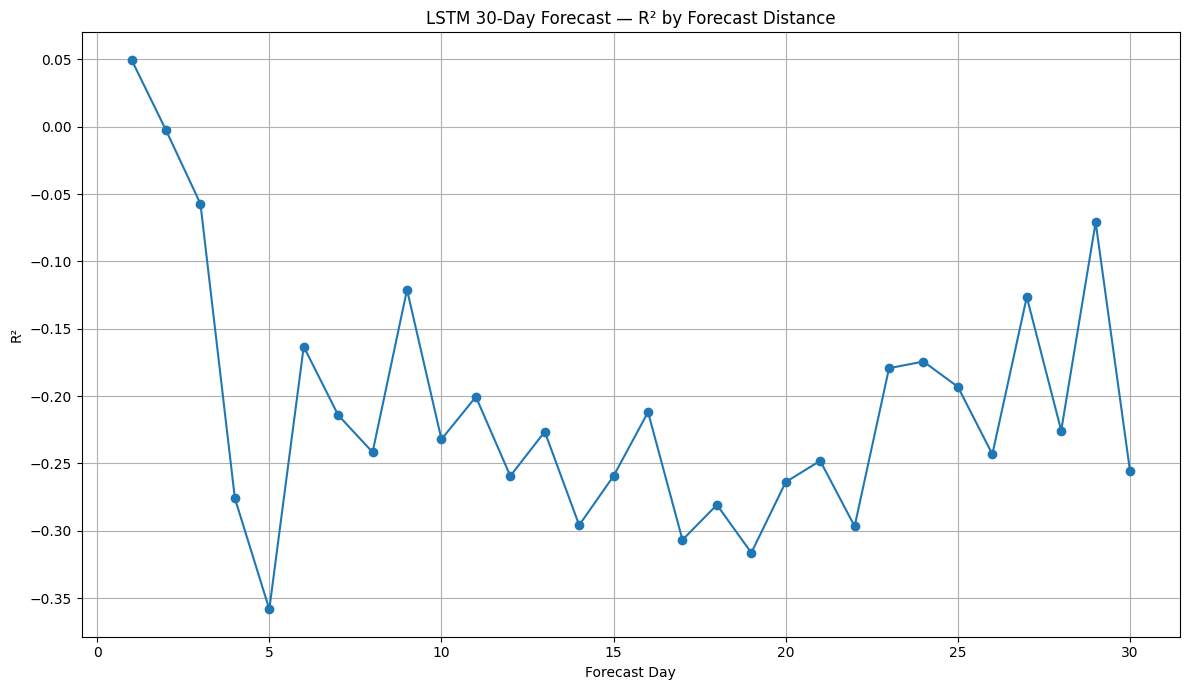

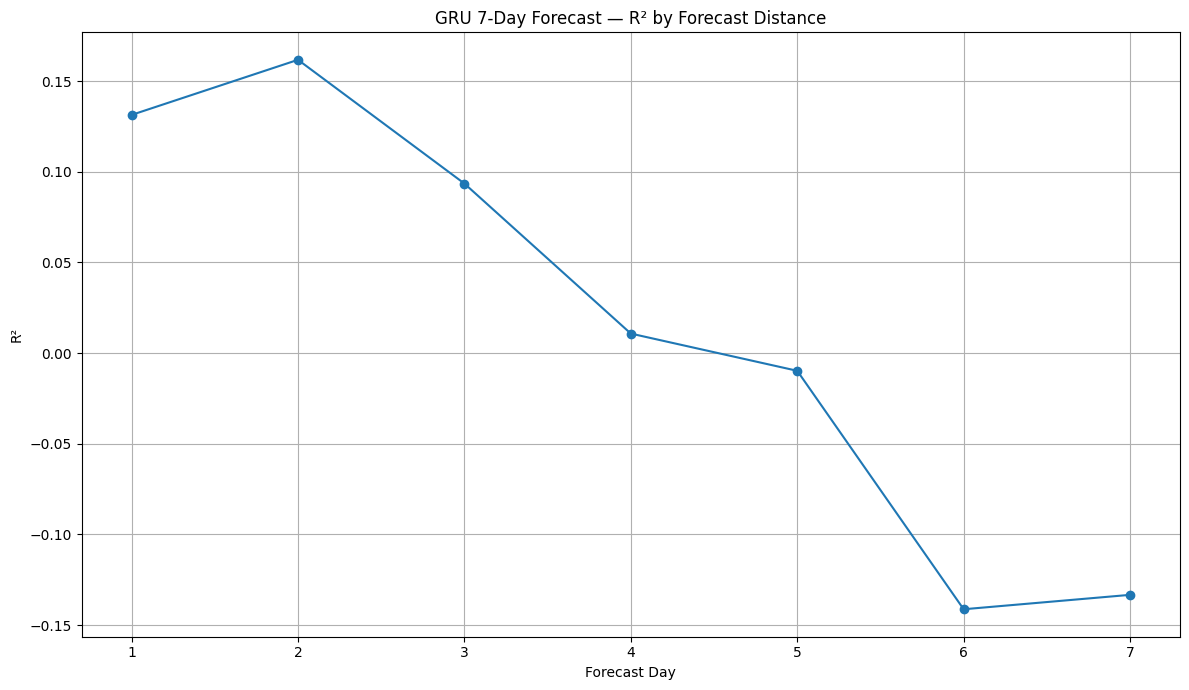

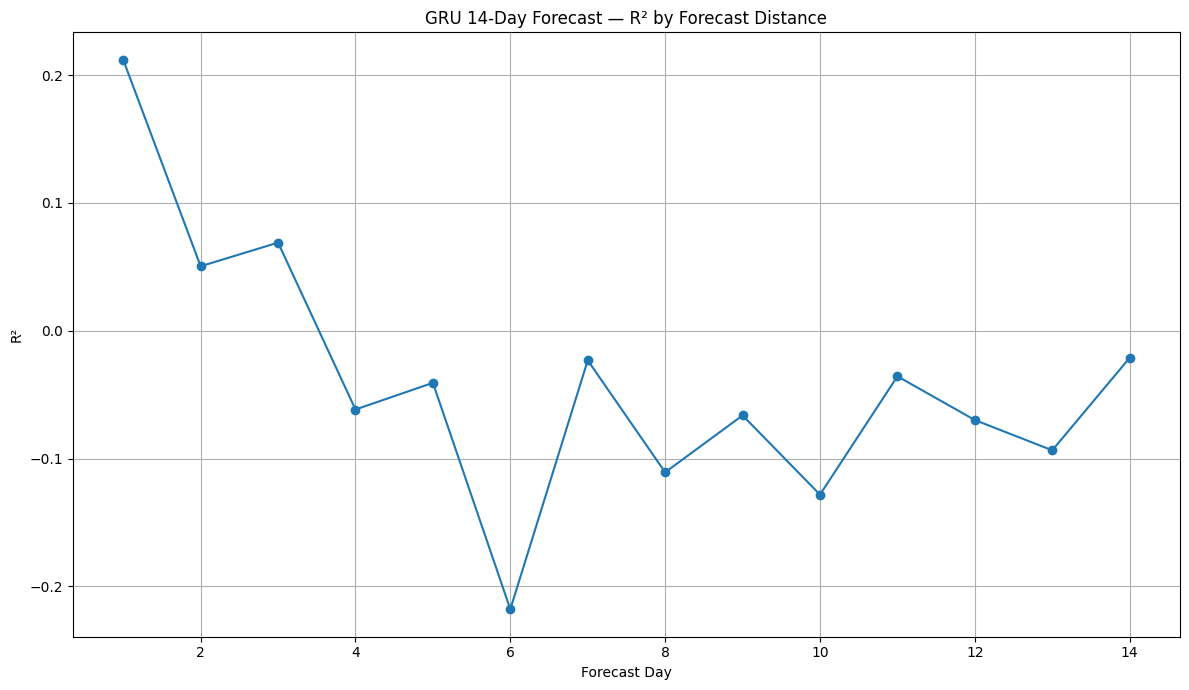

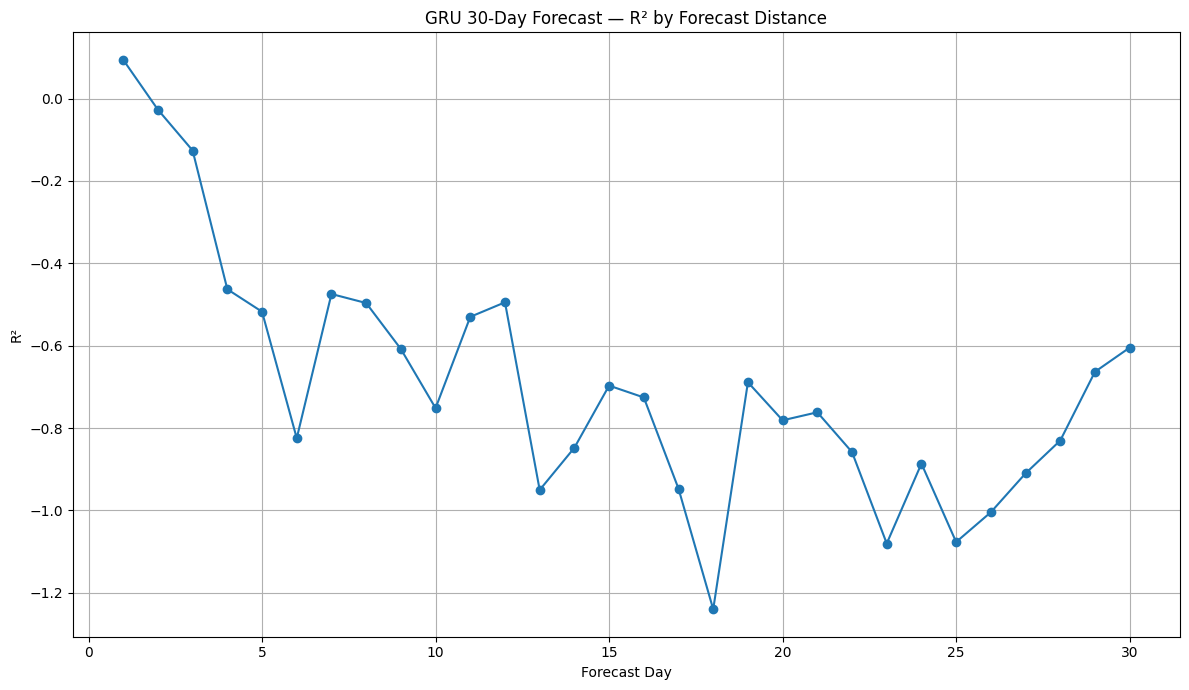

In [34]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        subset = daily_metrics_df[
            (daily_metrics_df["Model"] == model_type) &
            (daily_metrics_df["Horizon"] == horizon)
        ]

        plt.figure(figsize=(12, 7)) # Increased figure height for more separation

        plt.plot(
            subset["Forecast_Day"],
            subset["R²"],
            marker="o"
        )

        plt.xlabel("Forecast Day")
        plt.ylabel("R²")
        plt.title(
            f"{model_type} {horizon}-Day Forecast — "
            "R² by Forecast Distance"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()


## 24. Visualizing R-squared (R²) by Forecast Distance

These plots show the R-squared (R²) value for each forecast day. R-squared represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² value indicates a better fit. These plots help us see how well the model explains the variability in PM2.5 as we predict further into the future.

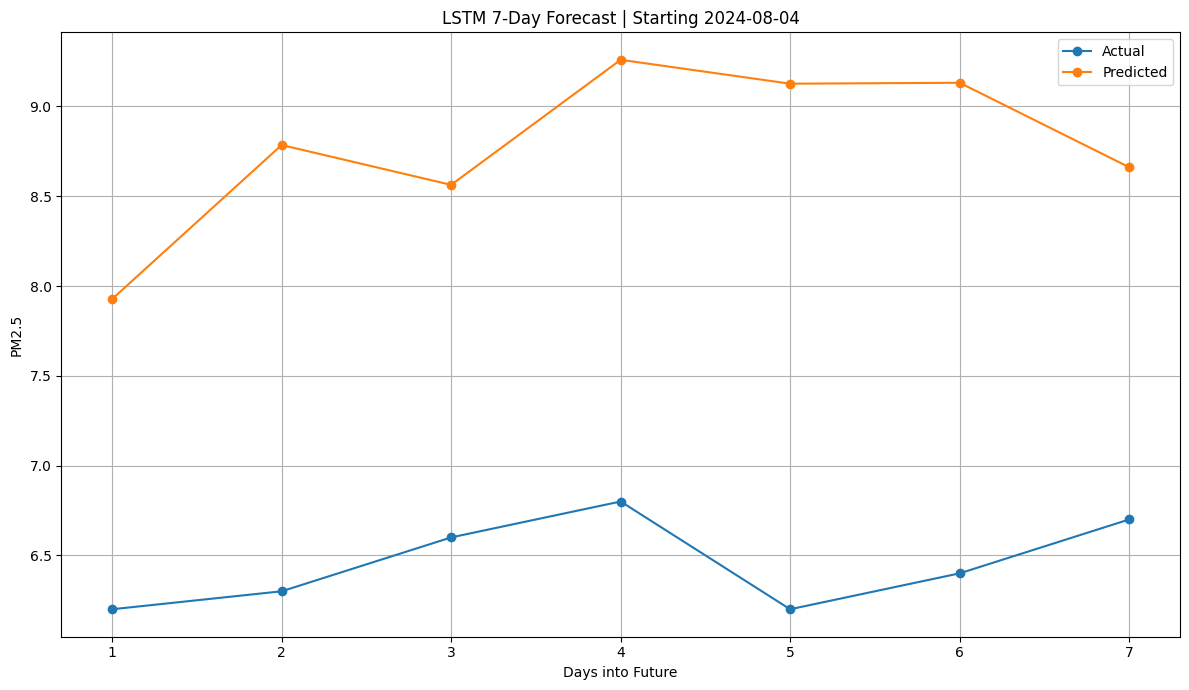

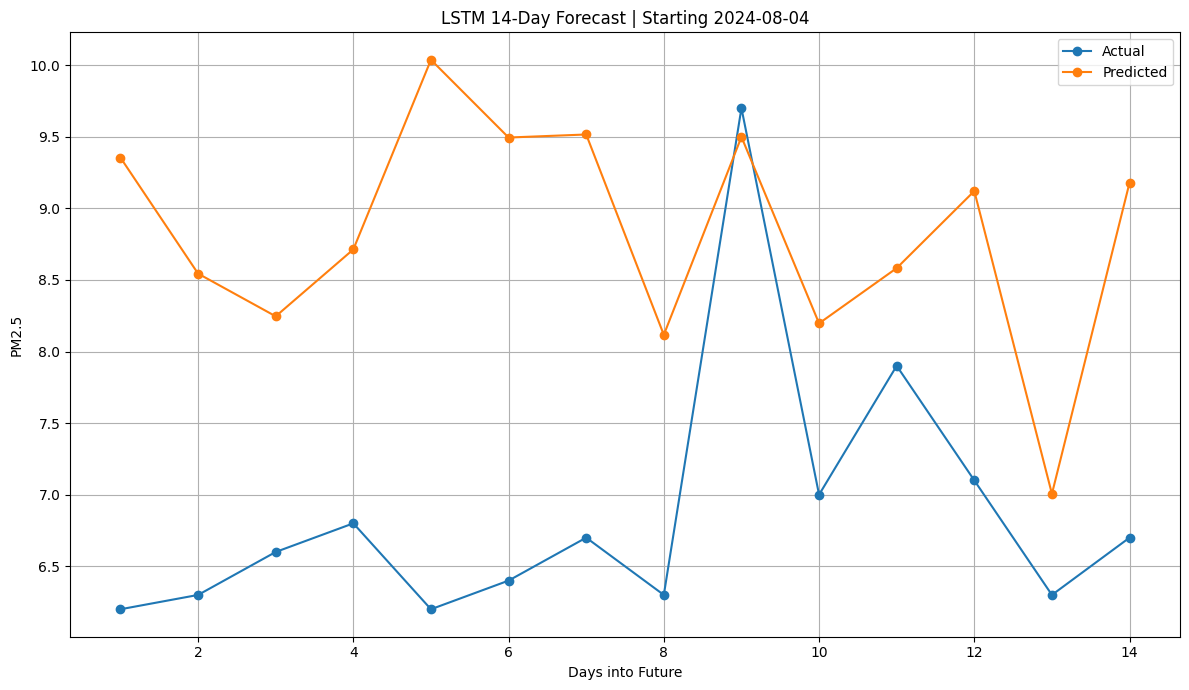

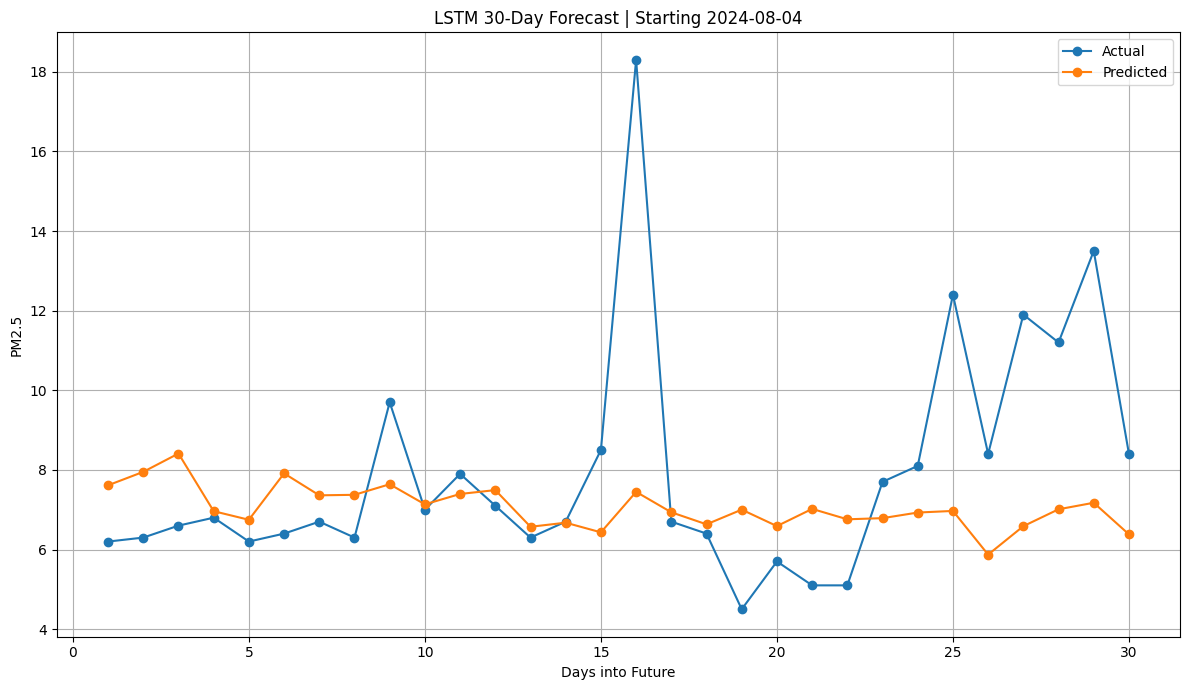

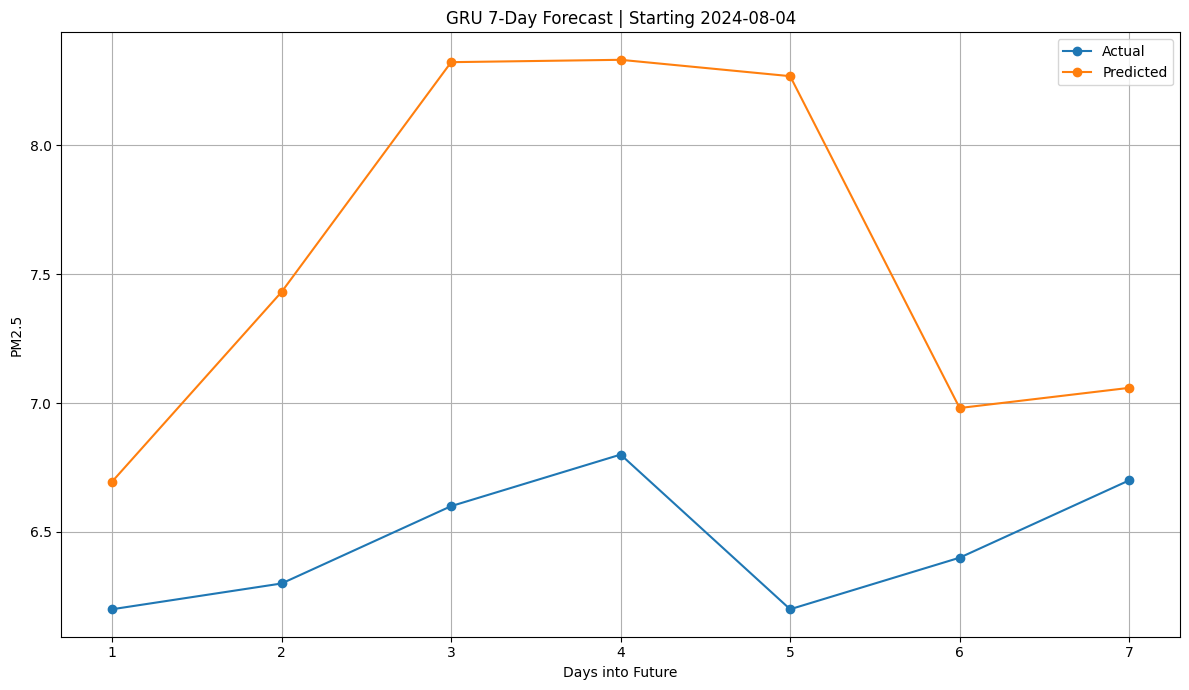

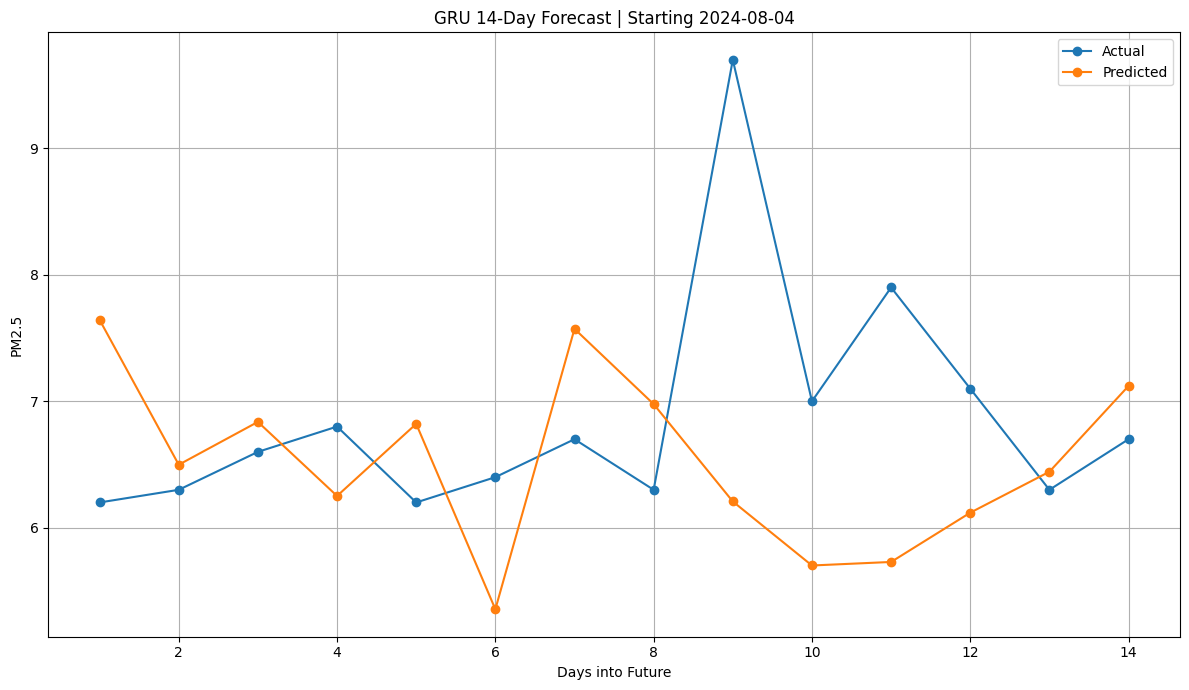

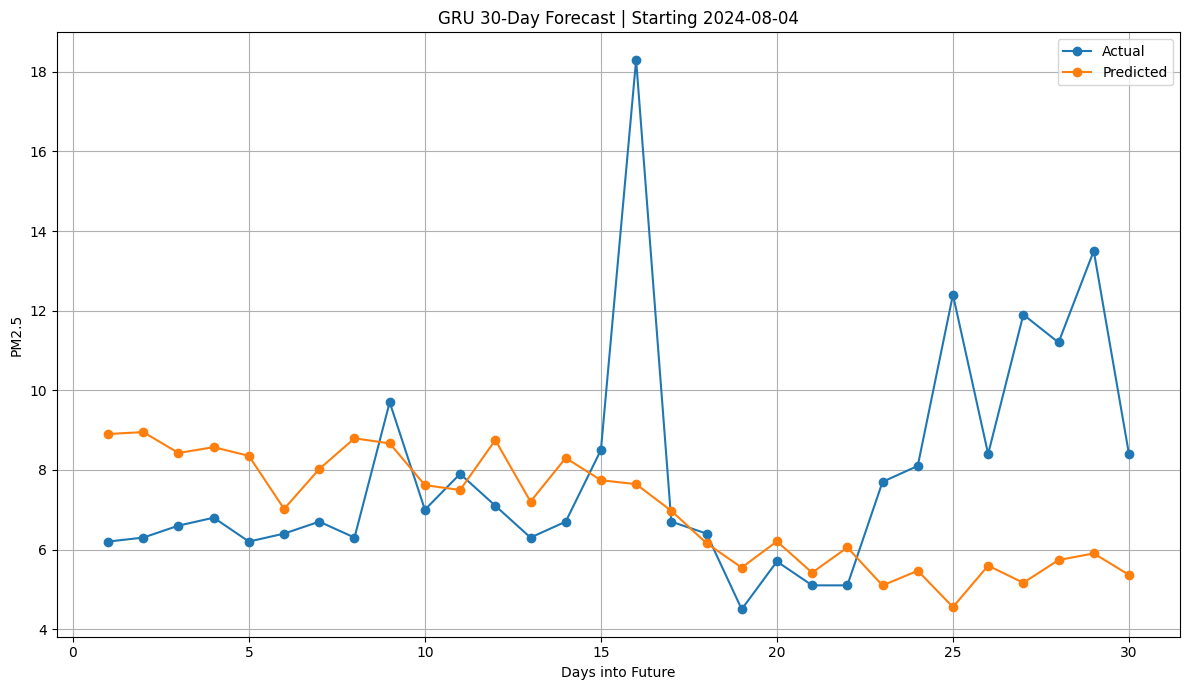

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# 21. ACTUAL VS PREDICTED COMPLETE TRAJECTORIES
# ============================================================

def plot_forecast_examples(
    model_type,
    horizon,
    n_examples=3
):

    result = predictions[(model_type, horizon)]

    y_true = result["y_true"]
    y_pred = result["y_pred"]
    date_matrix = result["dates"]

    n_examples = min(n_examples, len(y_true))

    for i in range(n_examples):

        plt.figure(figsize=(12, 6)) # Changed height to 6

        days = np.arange(1, horizon + 1)

        plt.plot(
            days,
            y_true[i],
            marker="o",
            label="Actual"
        )

        plt.plot(
            days,
            y_pred[i],
            marker="o",
            label="Predicted"
        )

        start_date = pd.Timestamp(
            date_matrix[i, 0]
        ).date()

        plt.xlabel("Days into Future")
        plt.ylabel("PM2.5")
        plt.title(
            f"{model_type} {horizon}-Day Forecast | "
            f"Starting {start_date}"
        )

        plt.grid(True)
        plt.legend()
        plt.tight_layout() # Added for better spacing
        plt.show()


for horizon in HORIZONS:
    plot_forecast_examples(
        "LSTM",
        horizon,
        n_examples=1
    )


## 25. Actual vs. Predicted Trajectories: Example Forecasts

This section provides a visual representation of a few example forecasts from our models. For each model and horizon, it plots the `Actual` PM2.5 values against the `Predicted` PM2.5 values over the entire forecast trajectory. This helps us understand how closely our models can track the real-world patterns for specific future periods.

### Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of Residuals

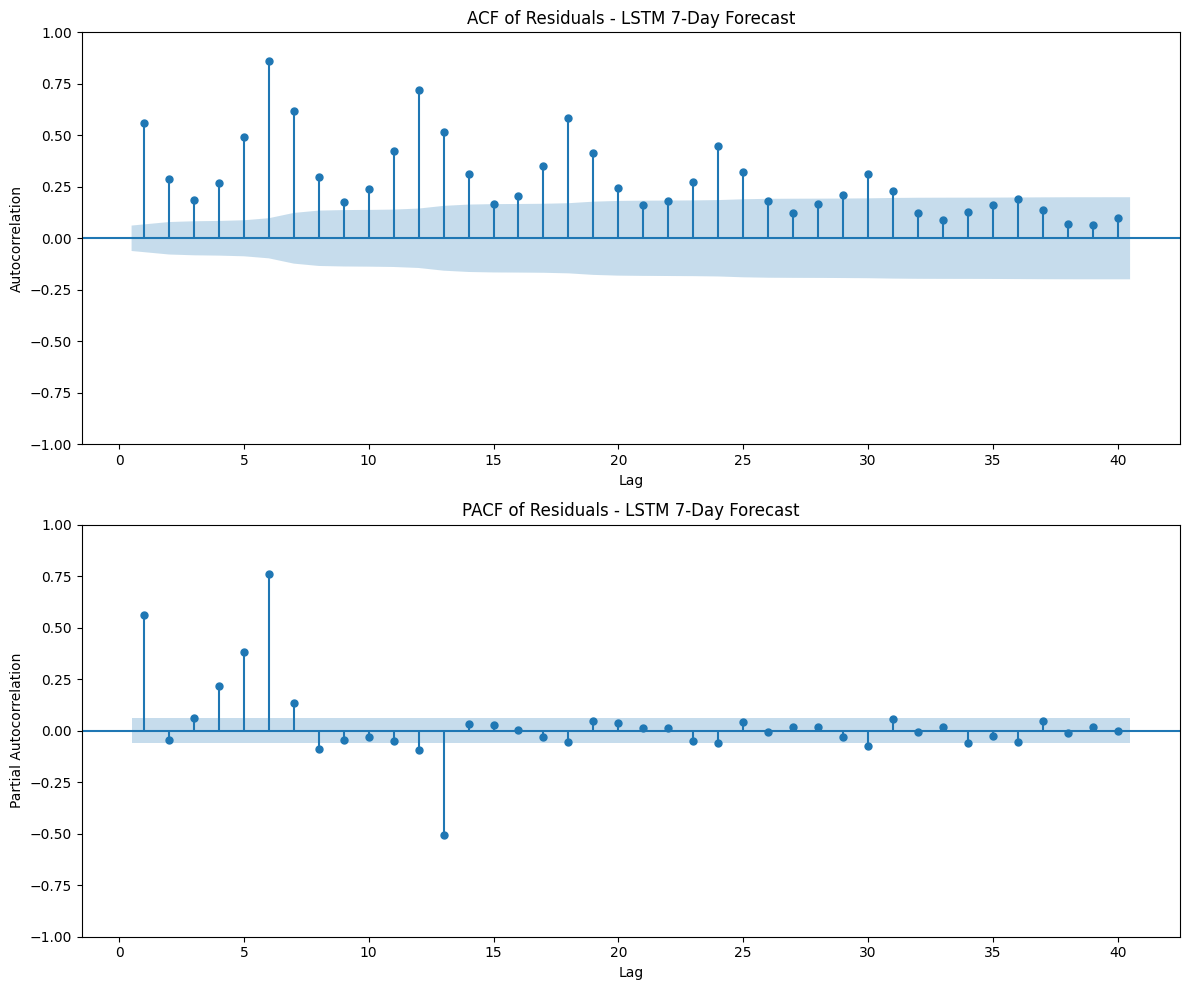

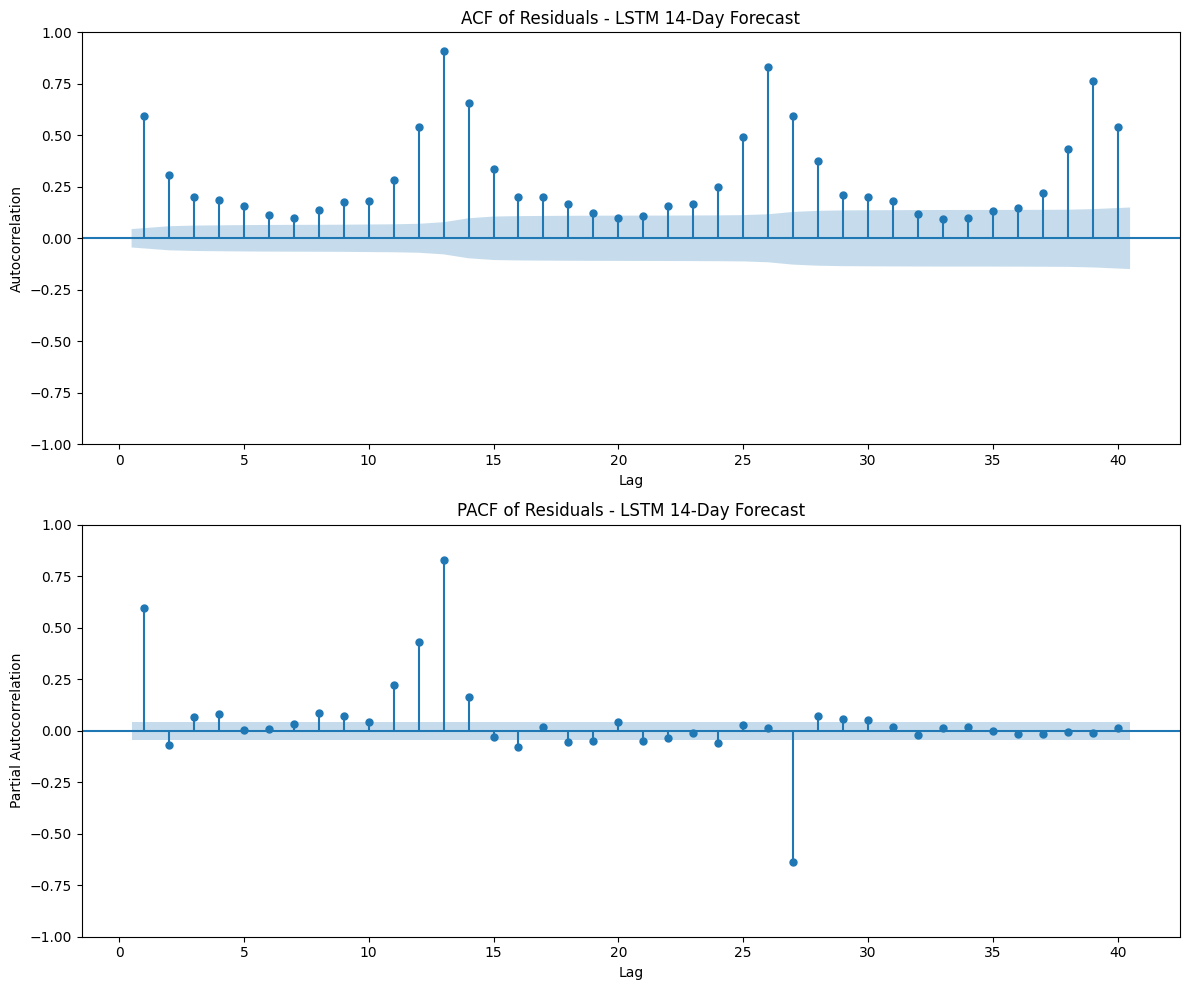

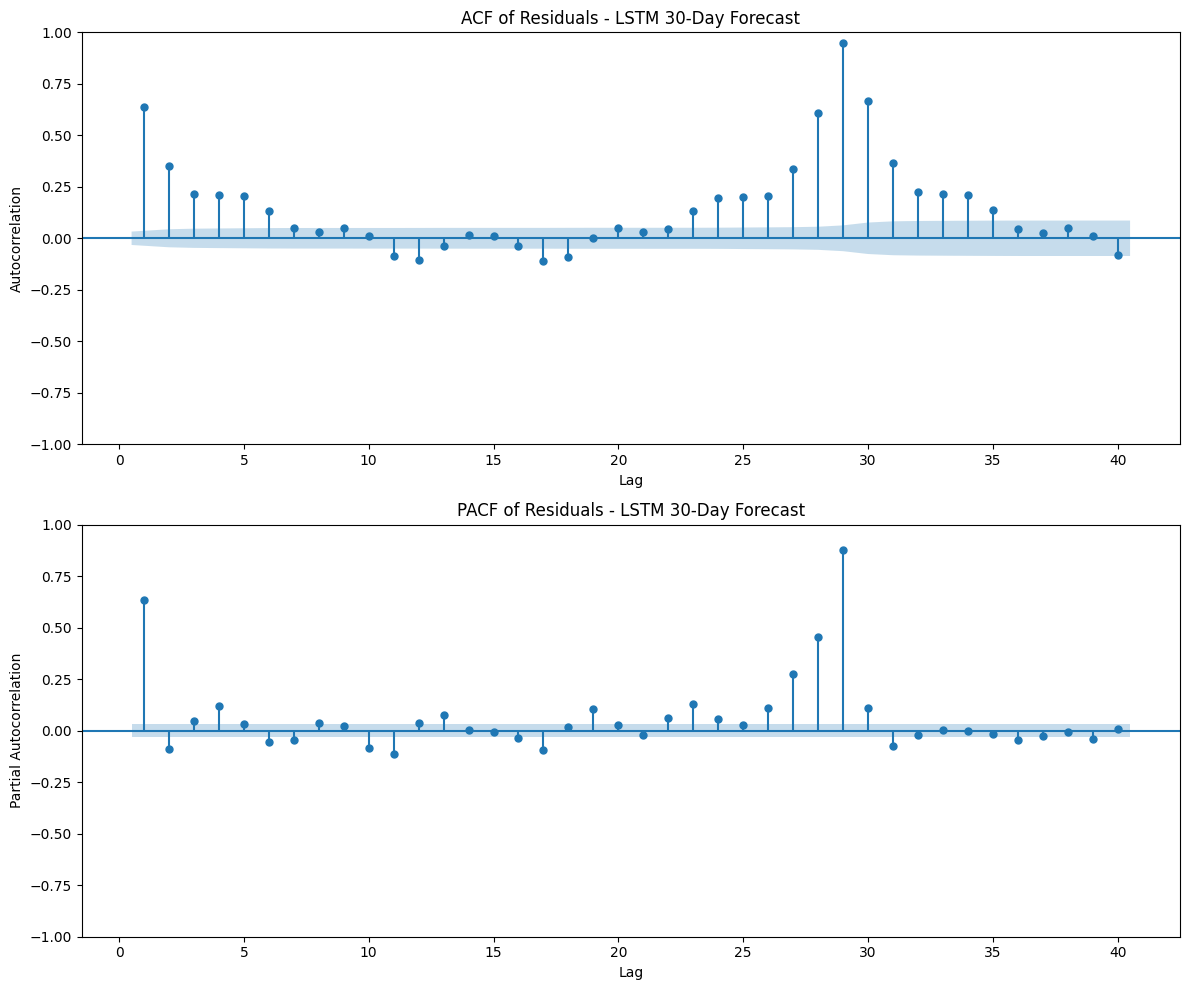

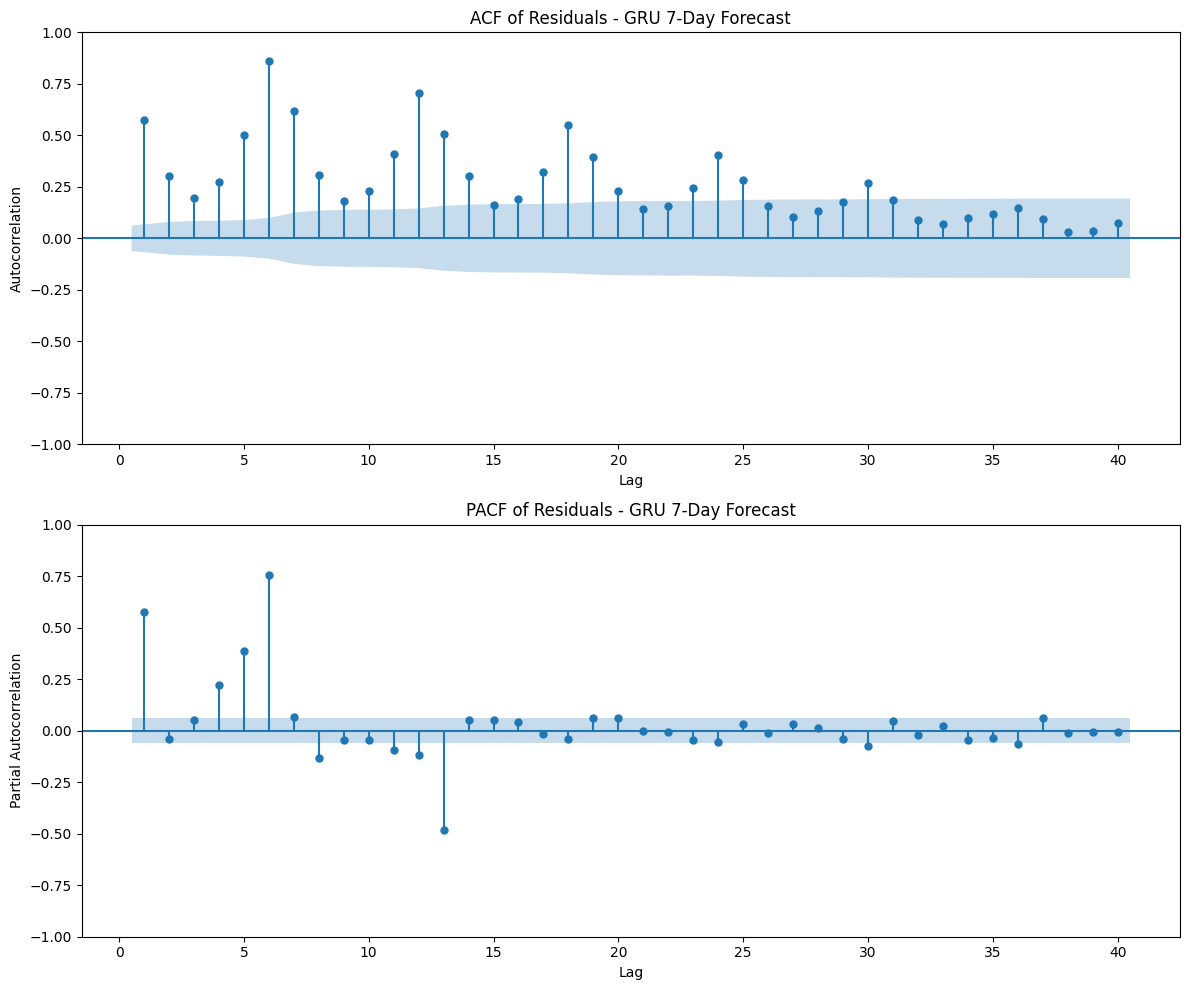

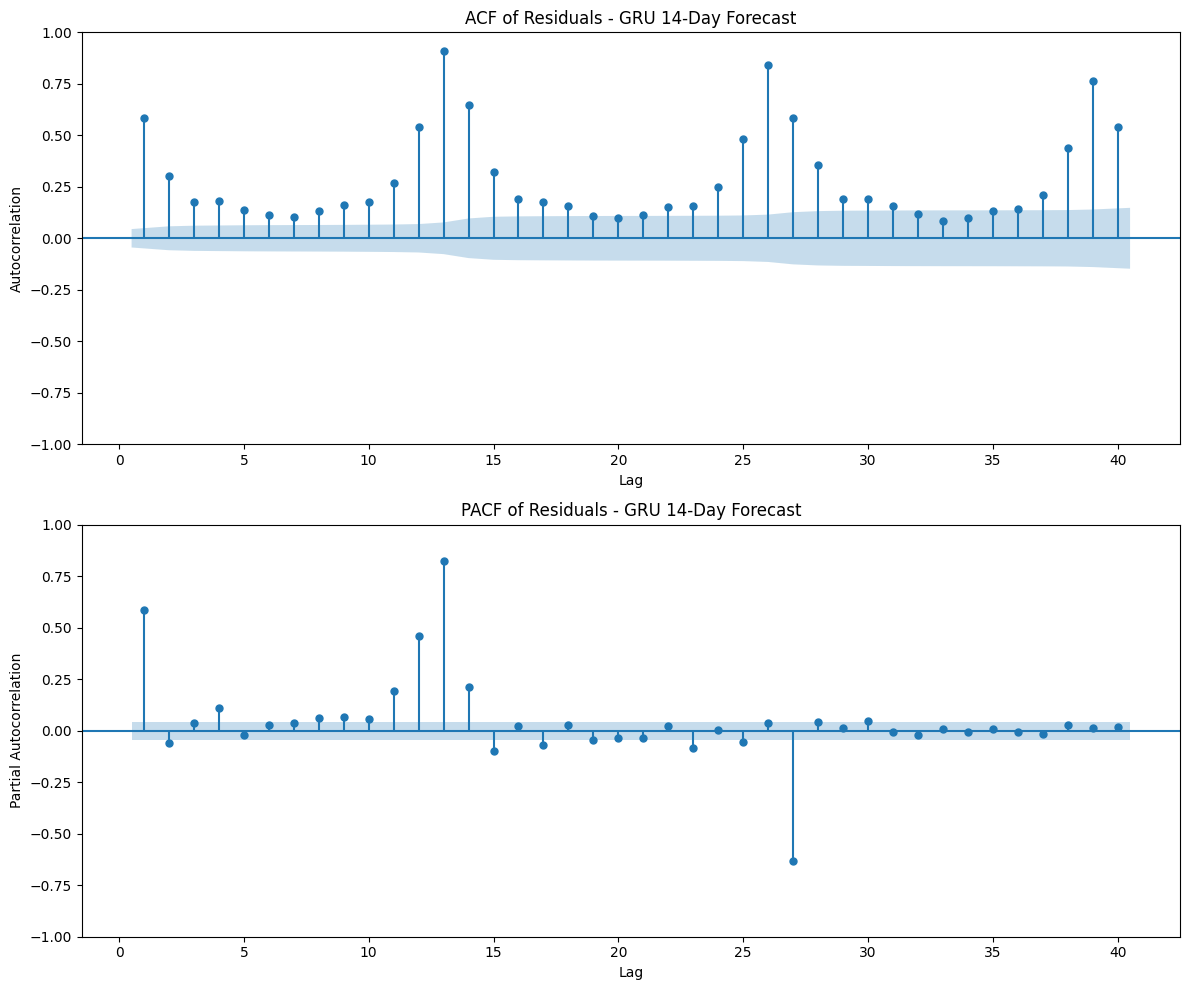

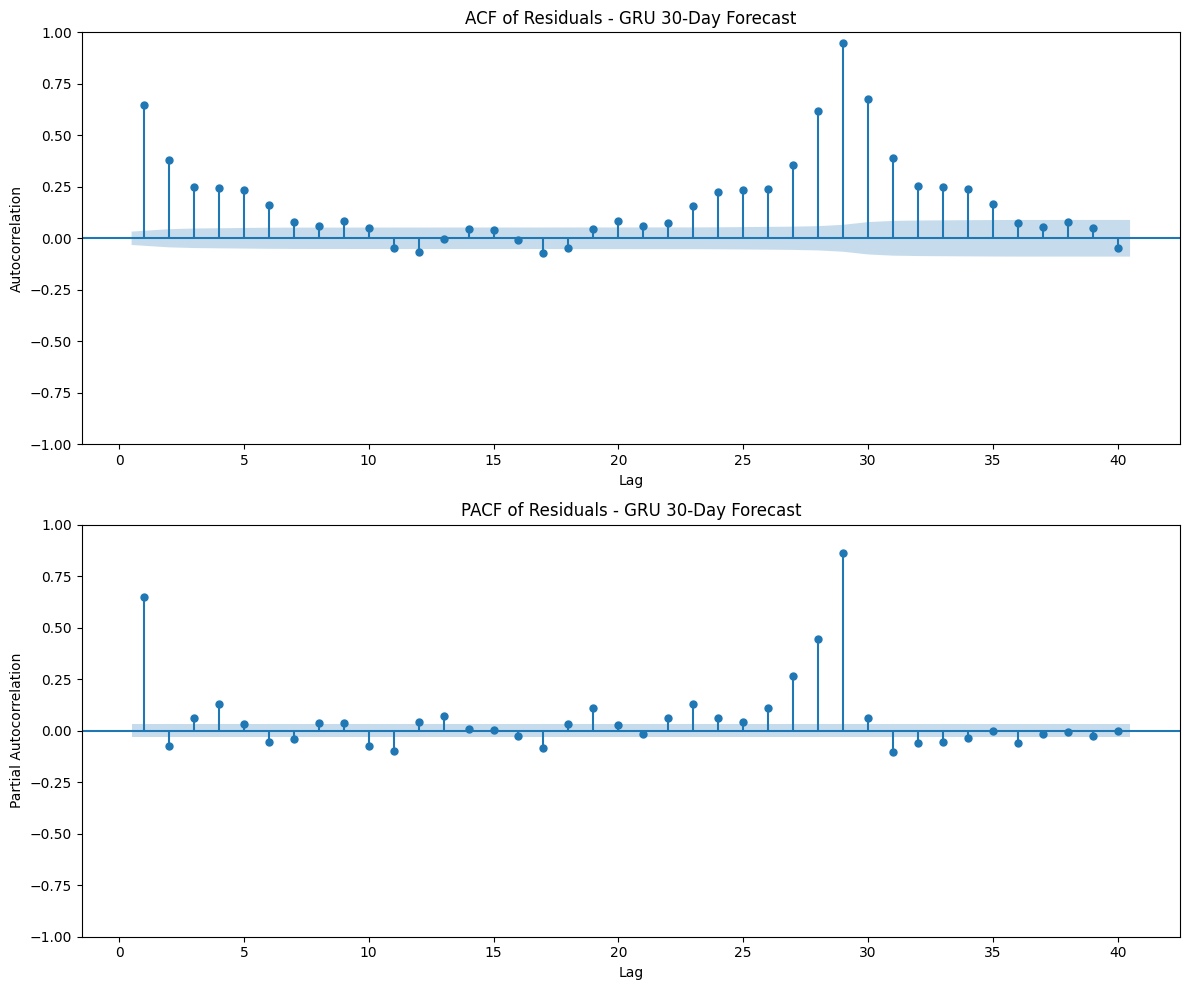

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        y_true = result["y_true"]
        y_pred = result["y_pred"]

        # Calculate residuals and flatten them
        residuals = (y_true - y_pred).flatten()

        fig, axes = plt.subplots(2, 1, figsize=(12, 10))

        # ACF plot
        plot_acf(residuals, ax=axes[0], lags=min(40, len(residuals) // 2 - 1), zero=False)
        axes[0].set_title(f'ACF of Residuals - {model_type} {horizon}-Day Forecast')
        axes[0].set_xlabel('Lag')
        axes[0].set_ylabel('Autocorrelation')

        # PACF plot
        plot_pacf(residuals, ax=axes[1], lags=min(40, len(residuals) // 2 - 1), zero=False)
        axes[1].set_title(f'PACF of Residuals - {model_type} {horizon}-Day Forecast')
        axes[1].set_xlabel('Lag')
        axes[1].set_ylabel('Partial Autocorrelation')

        plt.tight_layout()
        plt.show()

## 26. Analyzing Residuals: ACF and PACF Plots

These plots help us understand the patterns in the **residuals** (the differences between actual and predicted values) of our models. The Autocorrelation Function (ACF) plot shows the correlation of residuals with their own past values, while the Partial Autocorrelation Function (PACF) plot shows the direct correlation after removing indirect correlations. If the models are good, the residuals should ideally be random, meaning there should be no significant spikes in these plots beyond a certain lag. Spikes indicate that the model might be missing some underlying patterns in the data.

### Scatter Plot: Actual vs. Predicted Values

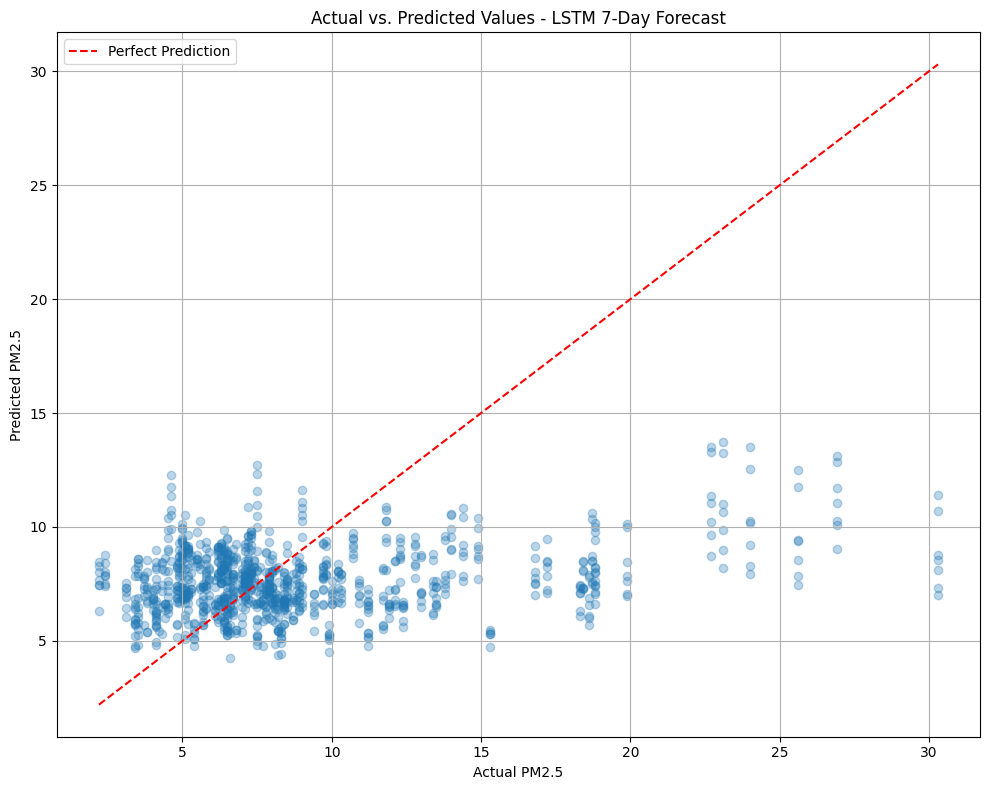

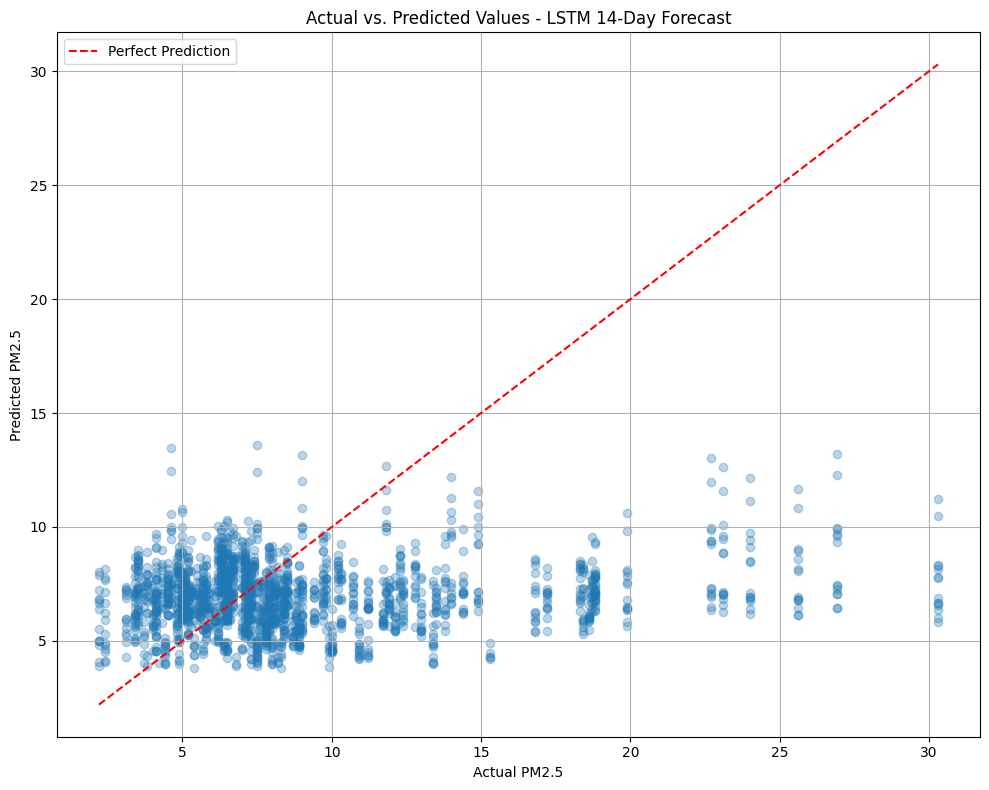

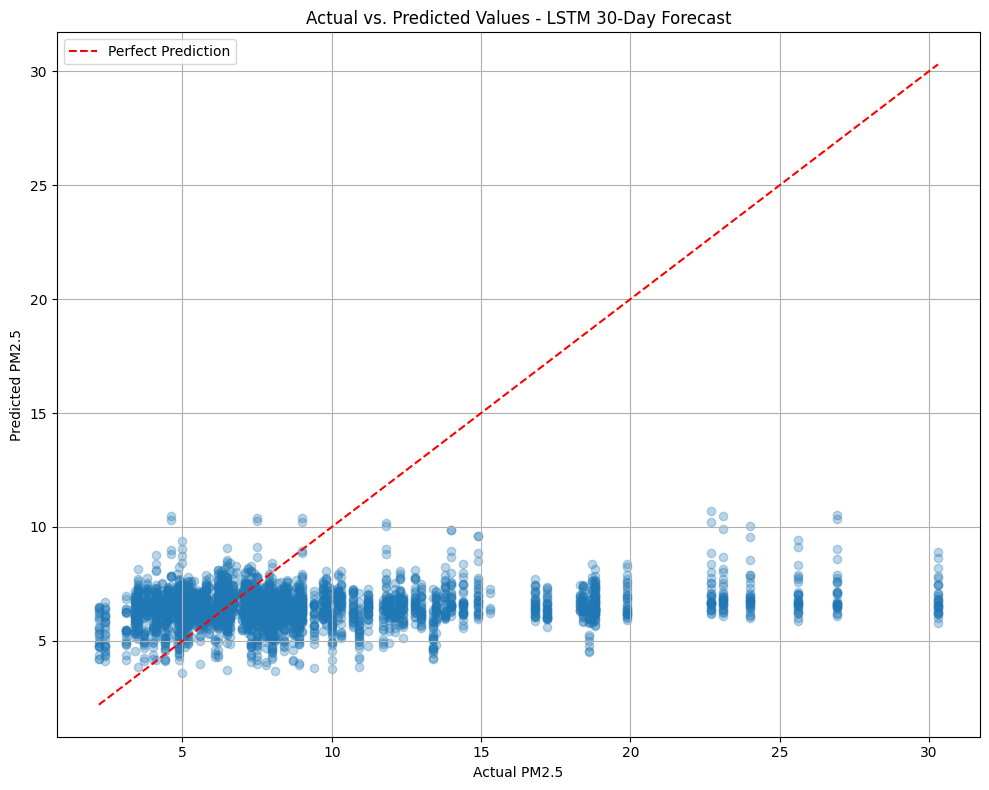

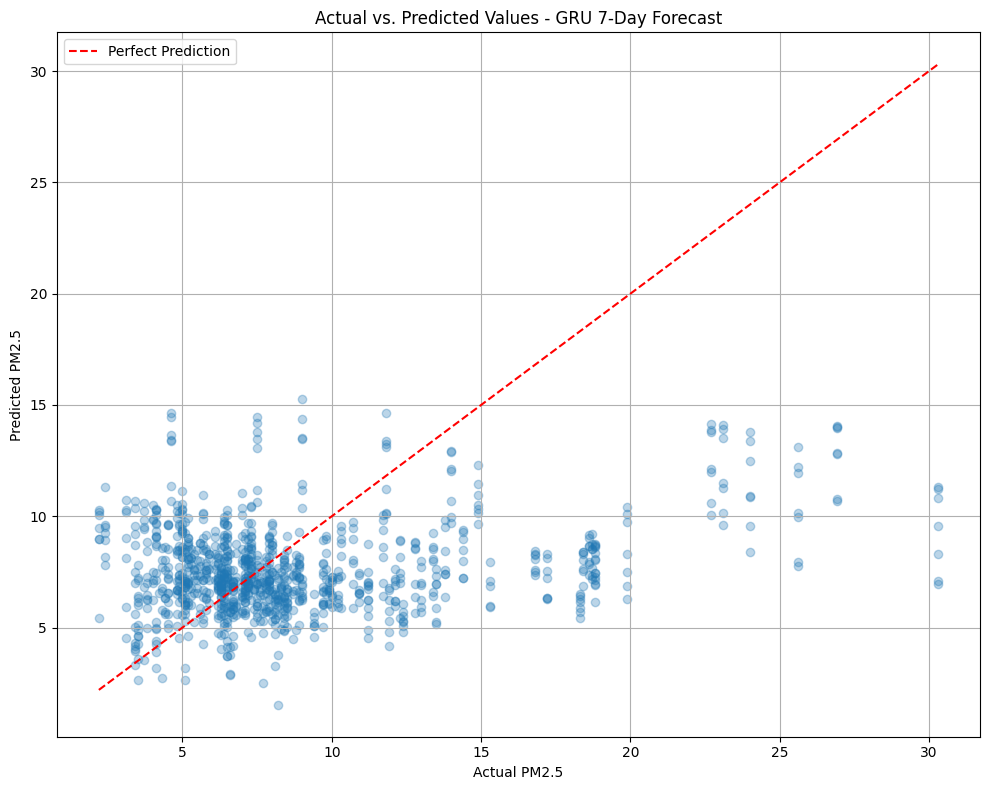

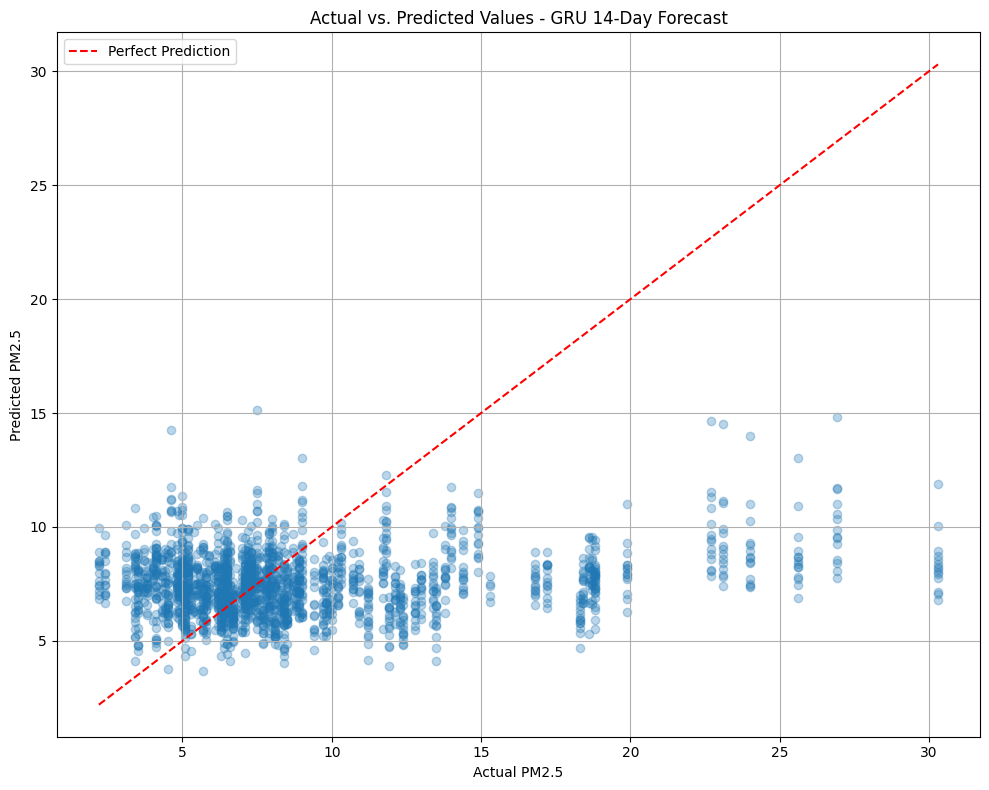

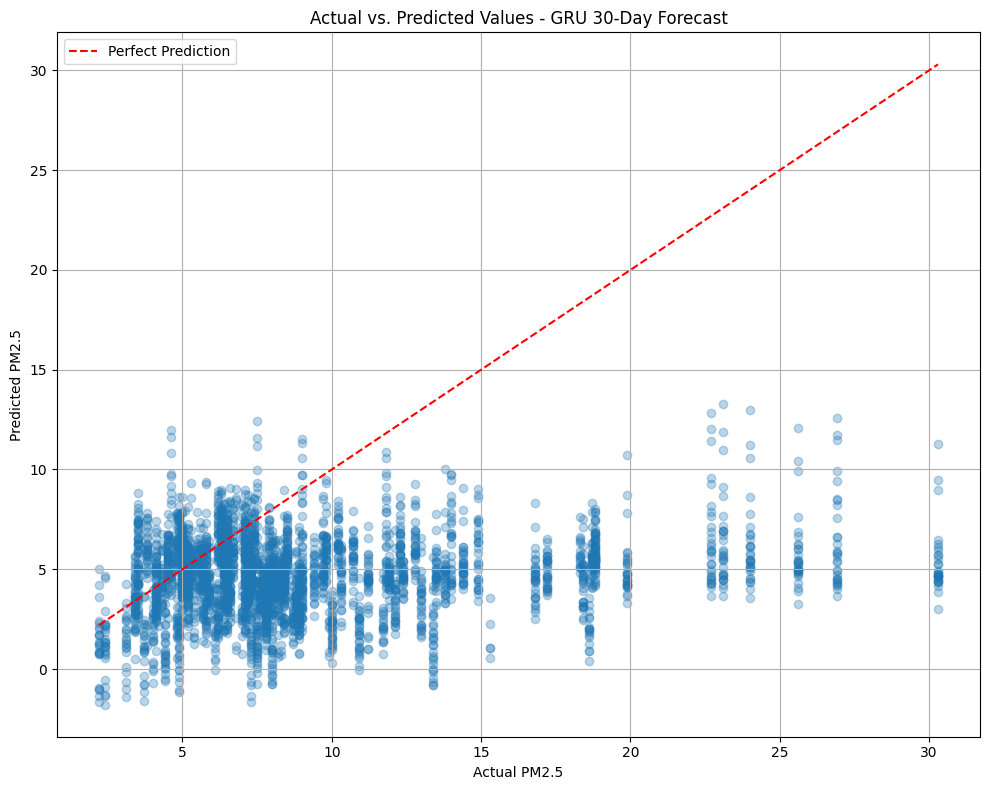

In [37]:
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        y_true = result["y_true"]
        y_pred = result["y_pred"]

        # Flatten the arrays for scatter plotting
        y_true_flat = y_true.flatten()
        y_pred_flat = y_pred.flatten()

        plt.figure(figsize=(10, 8))
        plt.scatter(y_true_flat, y_pred_flat, alpha=0.3)
        plt.plot(
            [min(y_true_flat), max(y_true_flat)],
            [min(y_true_flat), max(y_true_flat)],
            '--r', label='Perfect Prediction'
        )
        plt.title(f'Actual vs. Predicted Values - {model_type} {horizon}-Day Forecast')
        plt.xlabel('Actual PM2.5')
        plt.ylabel('Predicted PM2.5')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 27. Visualizing Prediction Accuracy: Actual vs. Predicted Scatter Plots

These scatter plots directly compare all the actual PM2.5 values from the test set against their corresponding predicted values for each model and horizon. A perfect model would show all points falling exactly on the red diagonal line. The closer the points are to this line, the more accurate the predictions. This gives a broad overview of the model's overall accuracy and any systematic deviations.

### Error Distribution Histograms

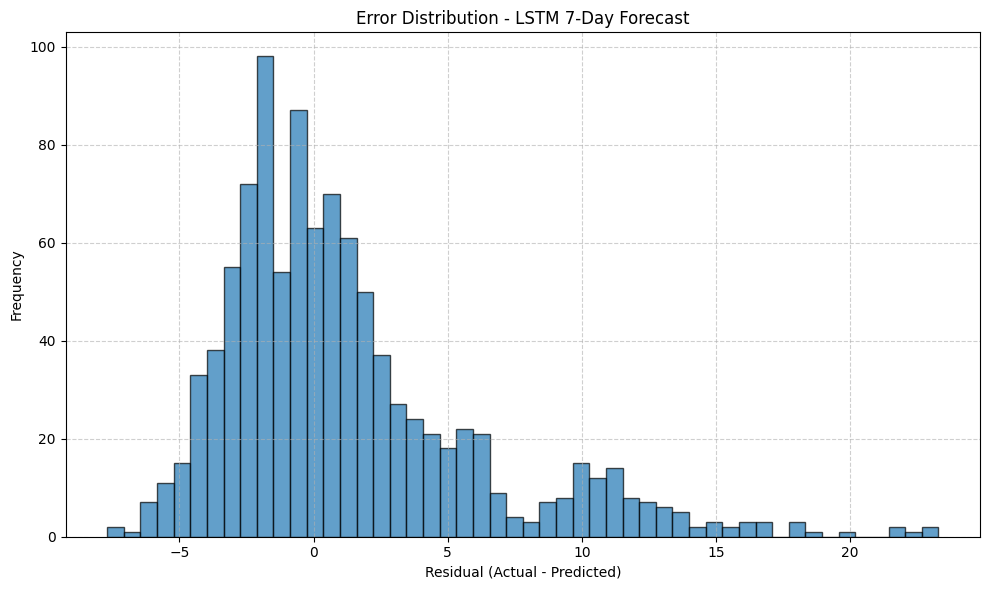

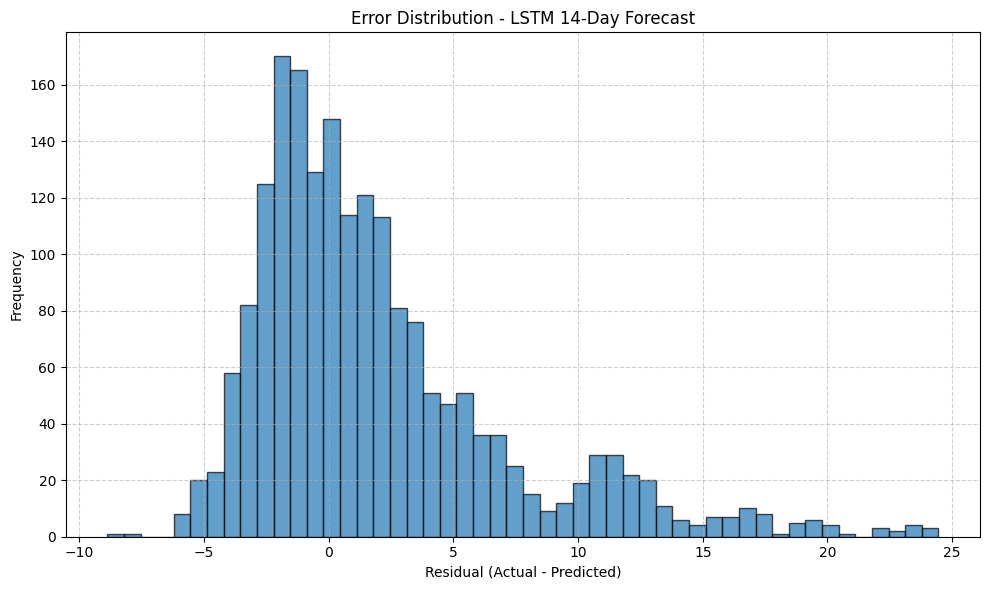

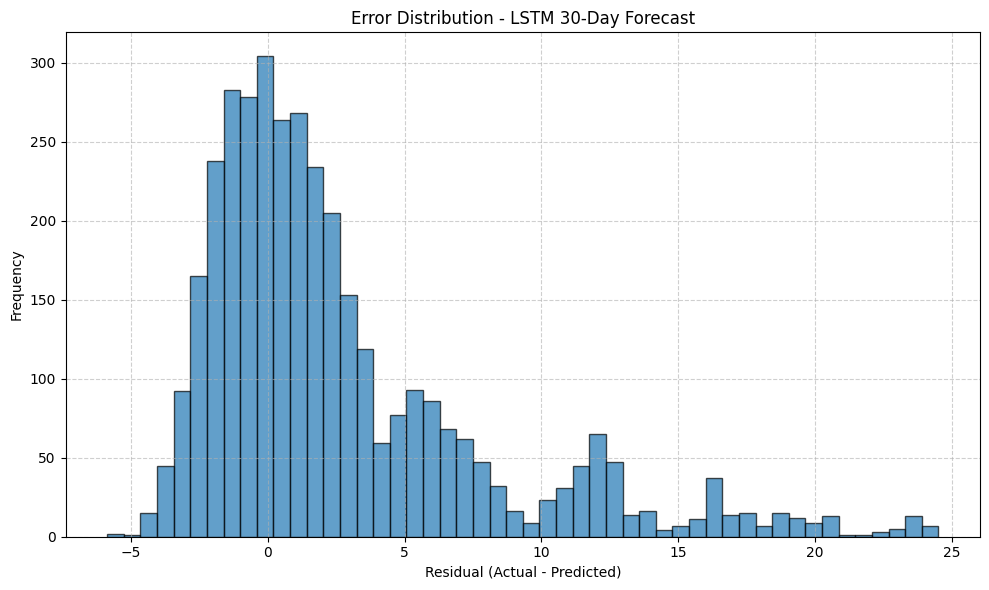

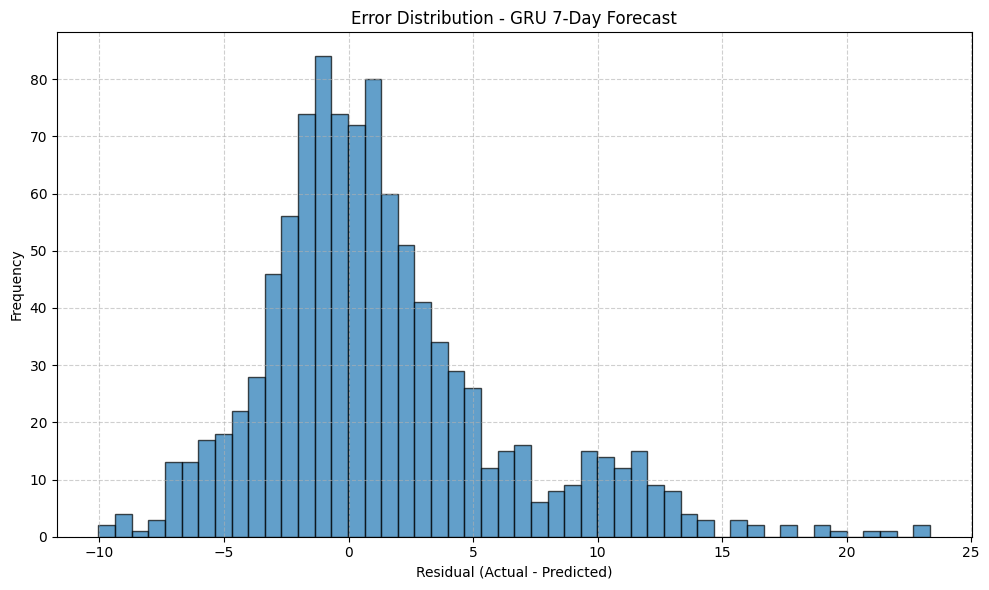

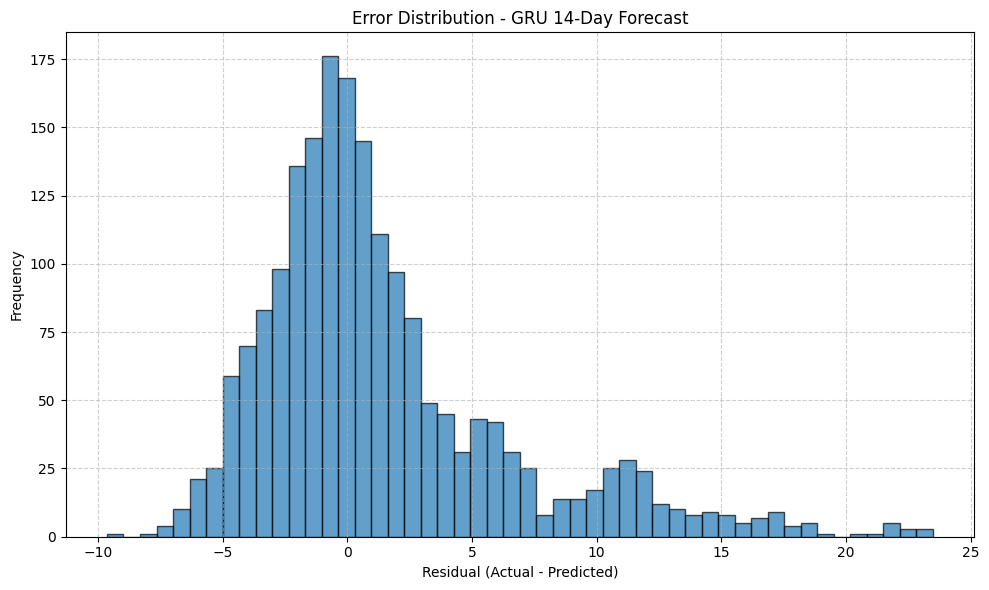

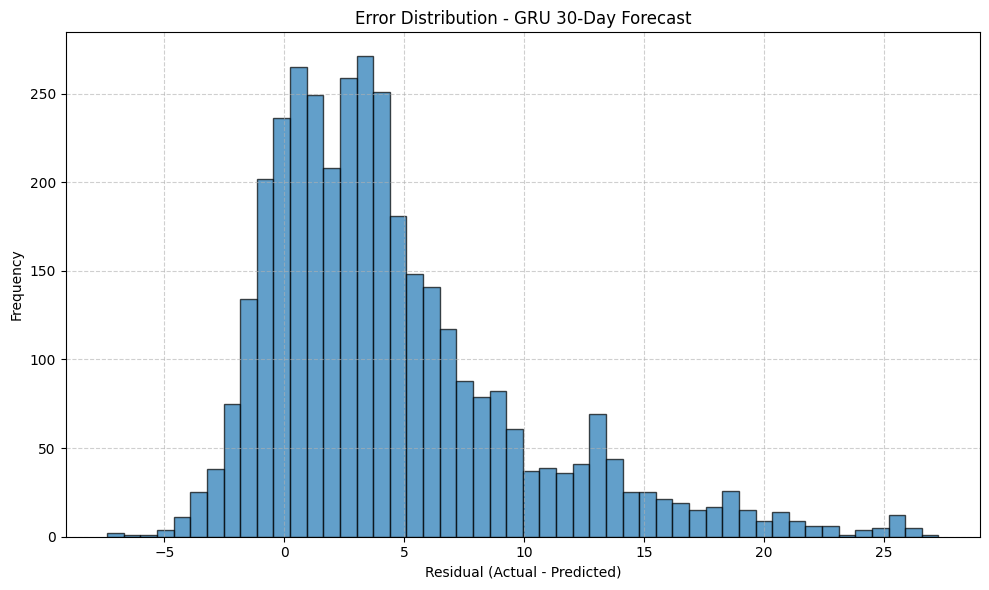

In [38]:
import matplotlib.pyplot as plt
import numpy as np

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        y_true = result["y_true"]
        y_pred = result["y_pred"]

        # Calculate residuals and flatten them
        residuals = (y_true - y_pred).flatten()

        plt.figure(figsize=(10, 6))
        plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
        plt.title(f'Error Distribution - {model_type} {horizon}-Day Forecast')
        plt.xlabel('Residual (Actual - Predicted)')
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

## 28. Understanding Error Distribution: Histograms

These histograms visualize the distribution of our model's residuals (the prediction errors, calculated as Actual - Predicted). Ideally, these errors should be centered around zero and follow a normal distribution, indicating that the model is making balanced predictions without a strong bias. The shape and spread of the histogram can reveal if the model tends to over- or under-predict and the magnitude of its errors.

### MAPE (%) Performance Comparison

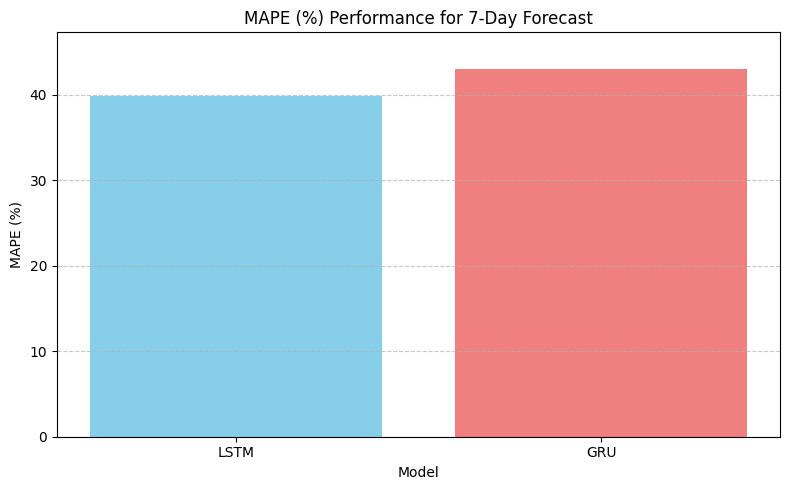

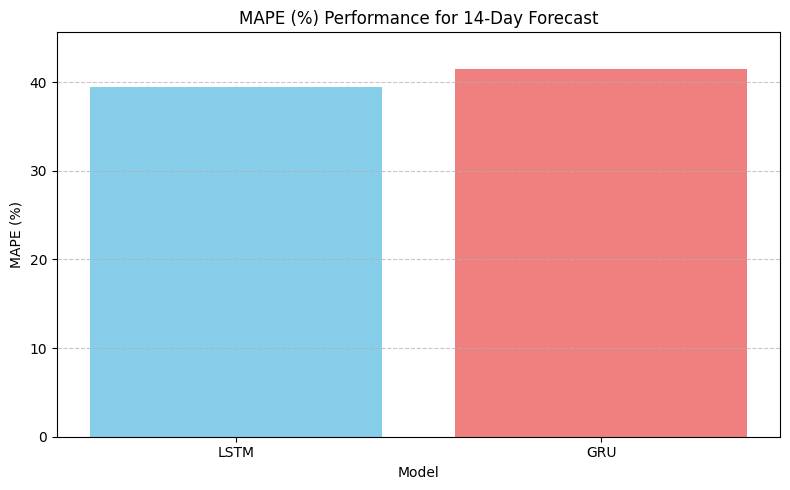

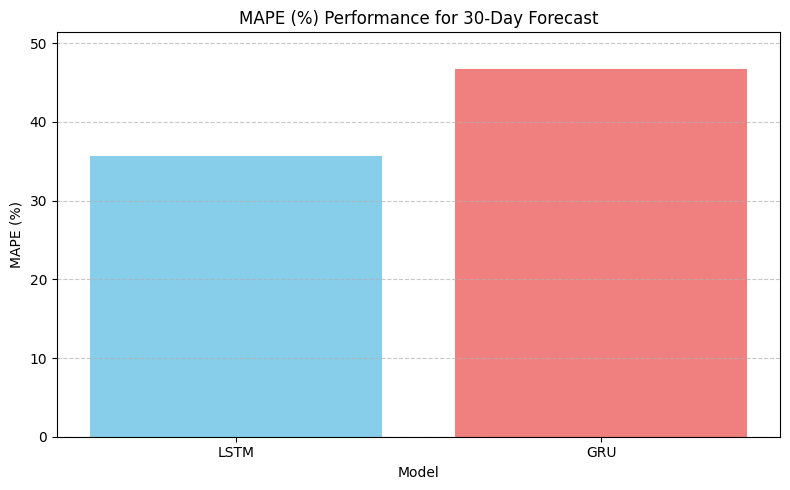

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

for horizon in HORIZONS:
    subset_df = overall_metrics_df[overall_metrics_df['Horizon'] == horizon]

    plt.figure(figsize=(8, 5))
    plt.bar(
        subset_df['Model'],
        subset_df['MAPE (%)'],
        color=['skyblue', 'lightcoral']
    )
    plt.xlabel('Model')
    plt.ylabel('MAPE (%)')
    plt.title(f'MAPE (%) Performance for {horizon}-Day Forecast')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(subset_df['MAPE (%)']) * 1.1) # Set y-limit slightly above max for better visualization
    plt.tight_layout()
    plt.show()

## 29. Comparing MAPE (%) Performance

These bar charts compare the Mean Absolute Percentage Error (MAPE %) between the LSTM and GRU models for each forecast horizon (7, 14, and 30 days). MAPE measures the accuracy of forecasts as a percentage, which can be easier to interpret. A lower MAPE indicates better percentage-based accuracy, allowing for a clear side-by-side comparison of the models' performance.

# 22. Final future forecast

The final forecast uses the latest available `LOOK_BACK` observations.

It outputs a complete future table for 7, 14 and 30 days.

This is the part that demonstrates the model is not simply predicting tomorrow.

In [22]:
# ============================================================
# 22. FINAL FUTURE FORECAST
# ============================================================

latest_input = X_all_scaled[-LOOK_BACK:].reshape(
    1,
    LOOK_BACK,
    len(feature_cols)
)

last_date = df["date"].iloc[-1]

future_forecasts = {}

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        model = best_models[(model_type, horizon)]

        pred_scaled = model.predict(
            latest_input,
            verbose=0
        )

        pred = inverse_target(pred_scaled[0])

        future_dates = pd.date_range(
            start=last_date + pd.Timedelta(days=1),
            periods=horizon,
            freq="D"
        )

        forecast_df = pd.DataFrame({
            "Date": future_dates,
            "Predicted_PM25": pred
        })

        future_forecasts[(model_type, horizon)] = forecast_df

        print(
            f"\n{model_type} — {horizon}-DAY FUTURE FORECAST"
        )

        display(forecast_df)


LSTM — 7-DAY FUTURE FORECAST


,Date,Predicted_PM25
0,2025-01-01,5.870288
1,2025-01-02,6.417575
2,2025-01-03,4.937439
3,2025-01-04,5.504672
4,2025-01-05,5.540545
5,2025-01-06,5.579951
6,2025-01-07,5.455993



LSTM — 14-DAY FUTURE FORECAST


,Date,Predicted_PM25
0,2025-01-01,6.985435
1,2025-01-02,7.359212
2,2025-01-03,6.845653
3,2025-01-04,6.749172
4,2025-01-05,6.030815
5,2025-01-06,6.241924
6,2025-01-07,6.118954
7,2025-01-08,5.629587
8,2025-01-09,4.935873
9,2025-01-10,5.240500



LSTM — 30-DAY FUTURE FORECAST


...

,Date,Predicted_PM25
0,2025-01-01,5.061387
1,2025-01-02,7.382190
2,2025-01-03,5.607225
3,2025-01-04,4.973052
4,2025-01-05,6.906466
5,2025-01-06,3.732595
6,2025-01-07,4.095004



GRU — 14-DAY FUTURE FORECAST


,Date,Predicted_PM25
0,2025-01-01,8.524570
1,2025-01-02,7.081455
2,2025-01-03,6.864505
3,2025-01-04,6.167710
4,2025-01-05,7.796852
5,2025-01-06,4.013244
6,2025-01-07,8.081300
7,2025-01-08,5.171306
8,2025-01-09,5.249928
9,2025-01-10,5.556621



GRU — 30-DAY FUTURE FORECAST


,Date,Predicted_PM25
0,2025-01-01,6.351047
1,2025-01-02,6.782498
2,2025-01-03,5.833793
3,2025-01-04,4.214827
4,2025-01-05,3.966838
5,2025-01-06,3.678092
6,2025-01-07,4.286662
7,2025-01-08,4.272446
8,2025-01-09,3.056599
9,2025-01-10,2.541734


## 30. Generating Our Final Future Forecasts

This is the ultimate application of our trained models! Using the very latest `LOOK_BACK` (30) days of data from our dataset, we feed it into each of our best-performing LSTM and GRU models for all three horizons. The models then generate a full 7-day, 14-day, and 30-day PM2.5 forecast into the future, beyond the historical data. This demonstrates the models' capability to provide genuine, multi-step predictions.

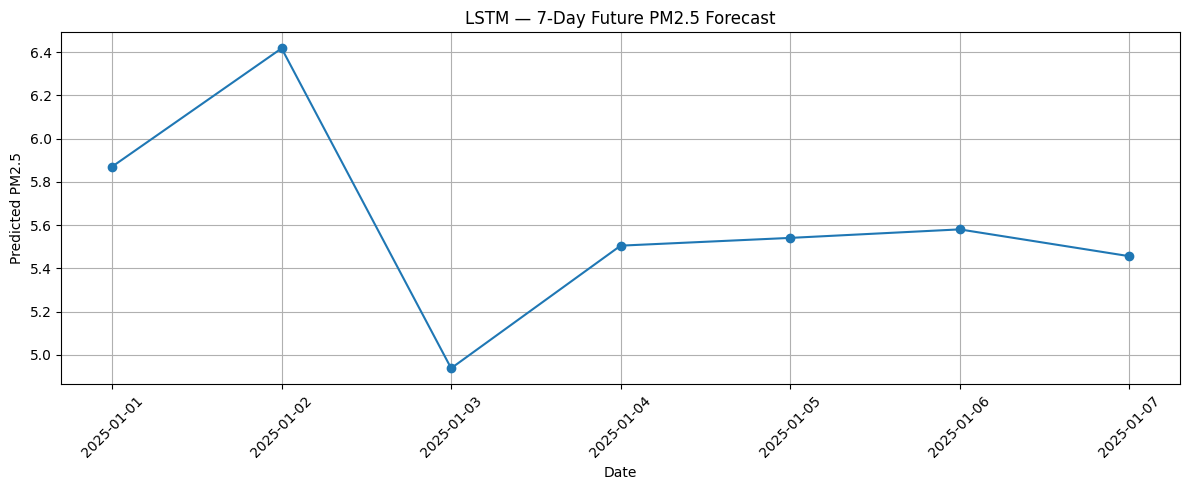

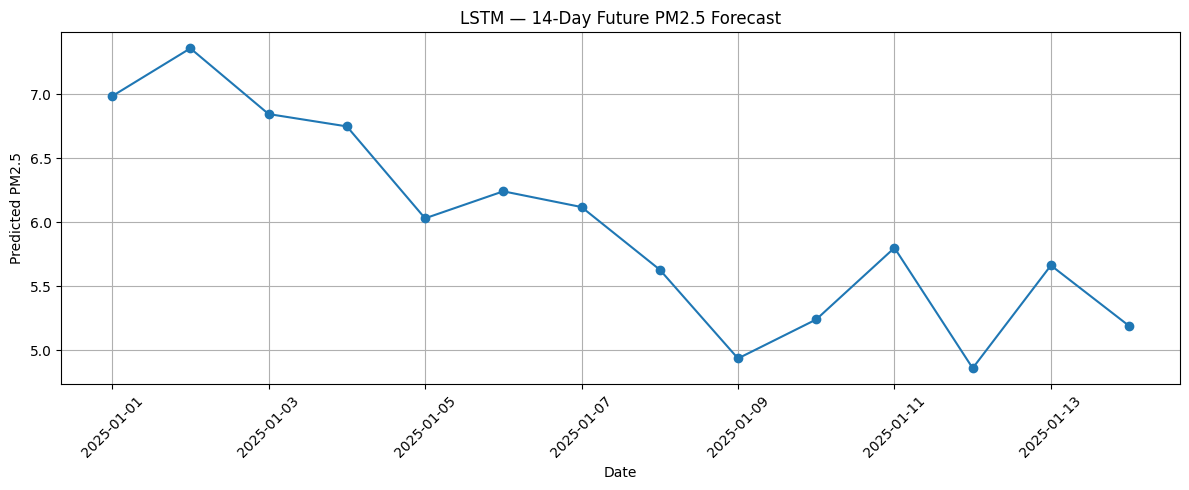

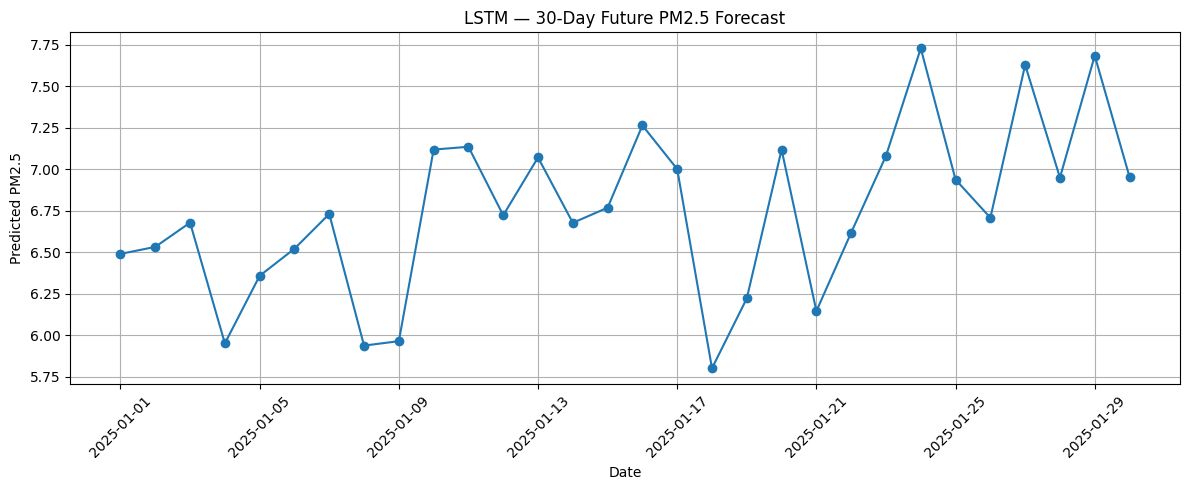

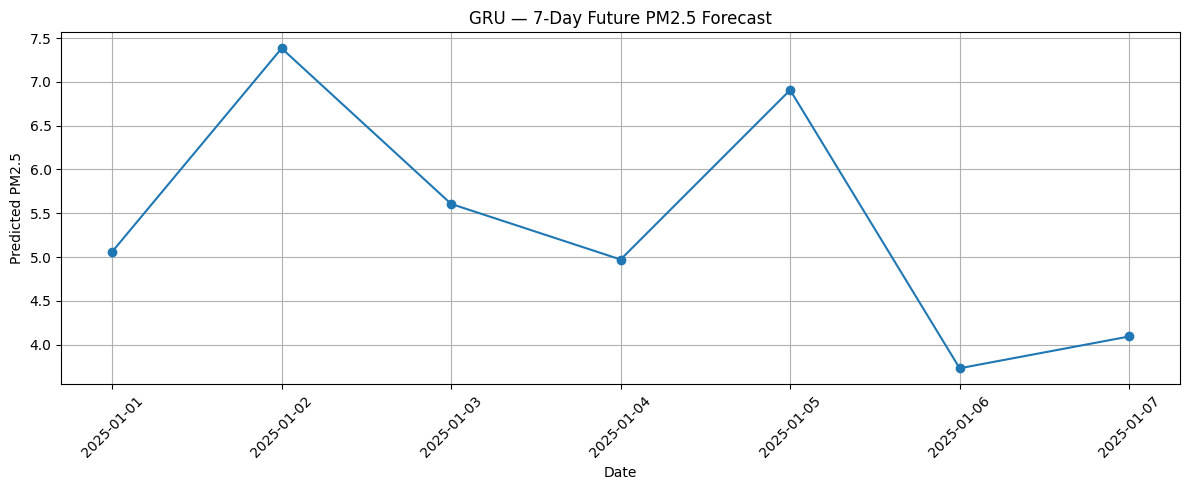

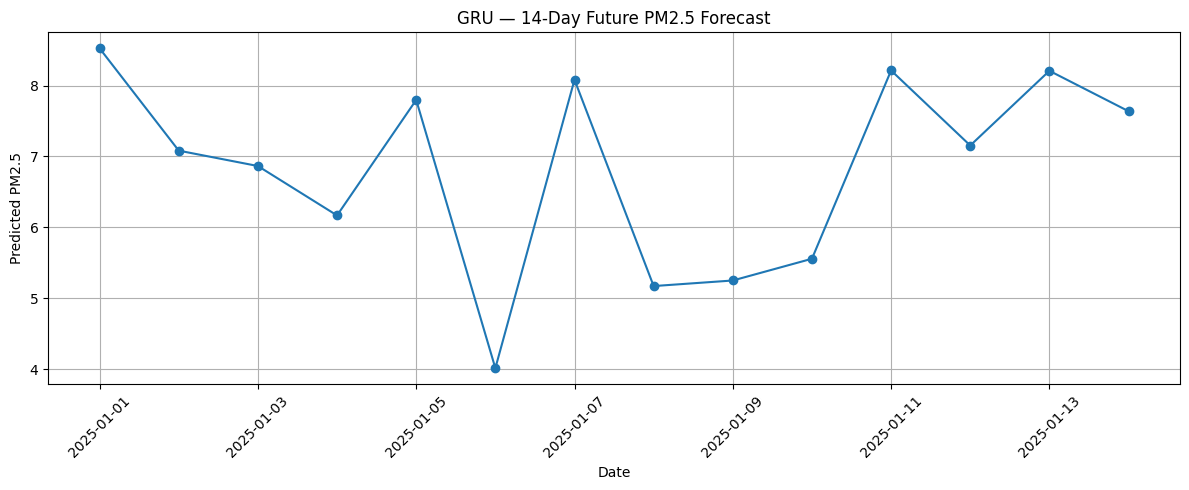

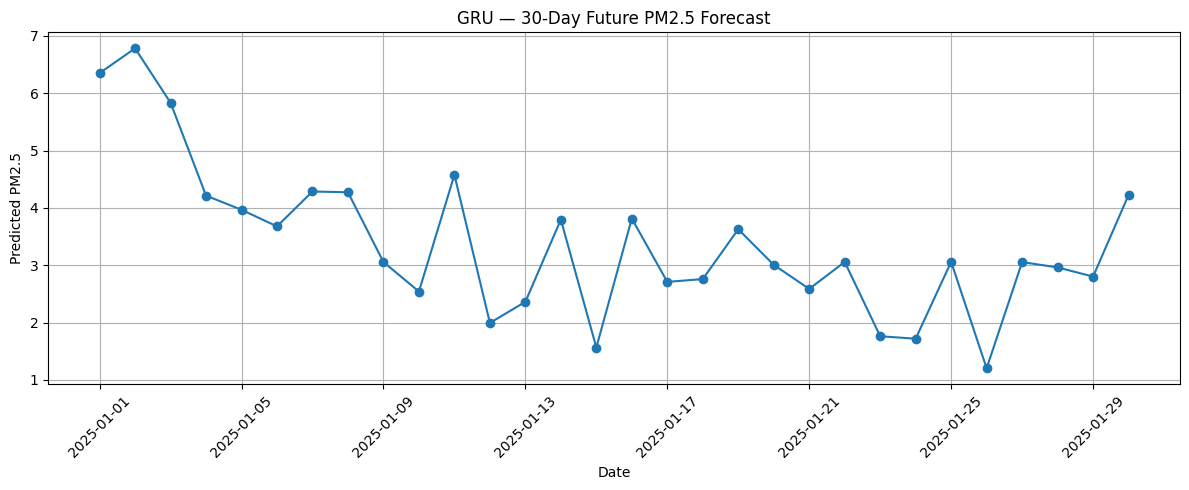

In [23]:
# ============================================================
# 23. FINAL FORECAST PLOTS
# ============================================================

for model_type in ["LSTM", "GRU"]:

    for horizon in HORIZONS:

        forecast_df = future_forecasts[
            (model_type, horizon)
        ]

        plt.figure(figsize=(12, 5))

        plt.plot(
            forecast_df["Date"],
            forecast_df["Predicted_PM25"],
            marker="o"
        )

        plt.xlabel("Date")
        plt.ylabel("Predicted PM2.5")
        plt.title(
            f"{model_type} — "
            f"{horizon}-Day Future PM2.5 Forecast"
        )

        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## 31. Visualizing Our Future Predictions

These plots display the actual future forecasts generated by our LSTM and GRU models for each horizon (7, 14, and 30 days). Each chart shows the predicted PM2.5 values over the specified future period. This provides a clear visual representation of what our models expect the PM2.5 levels to be in the upcoming days, weeks, or even a month.

### Forecast Error Over Time

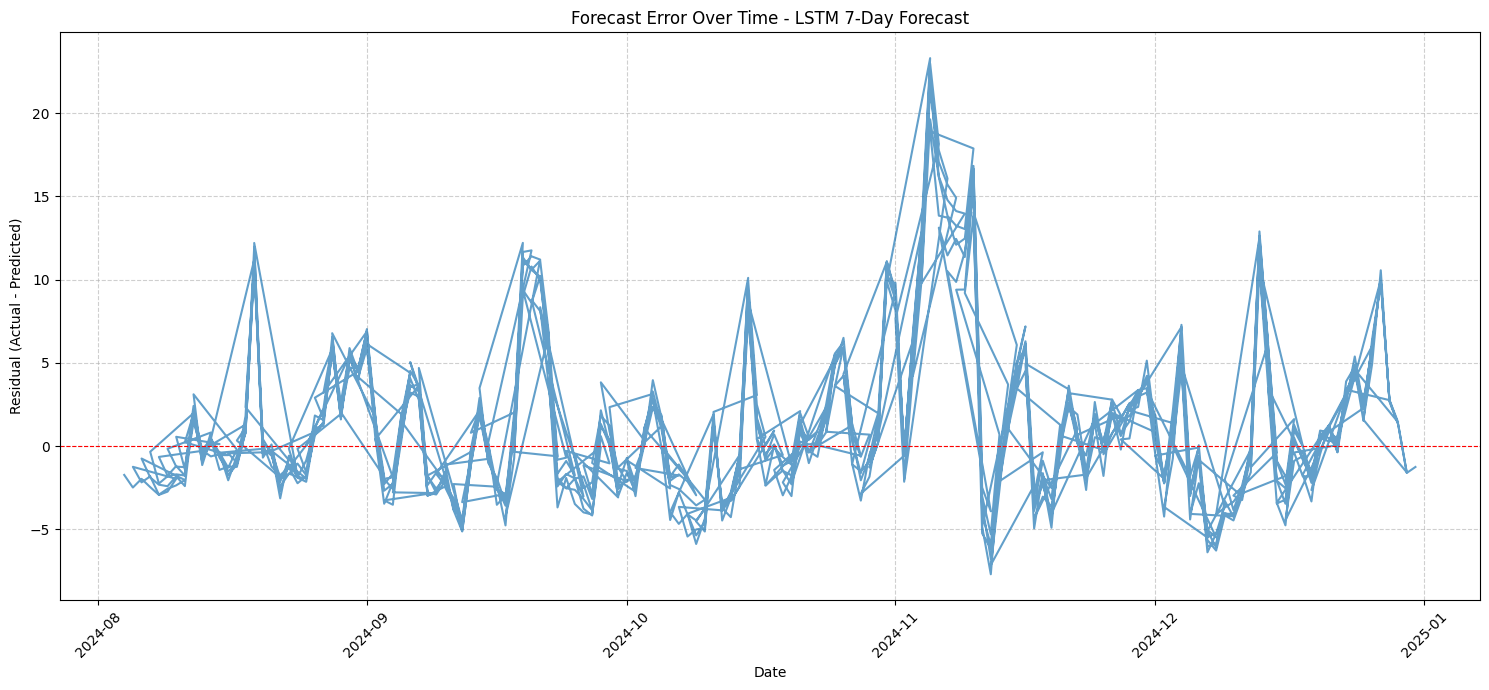

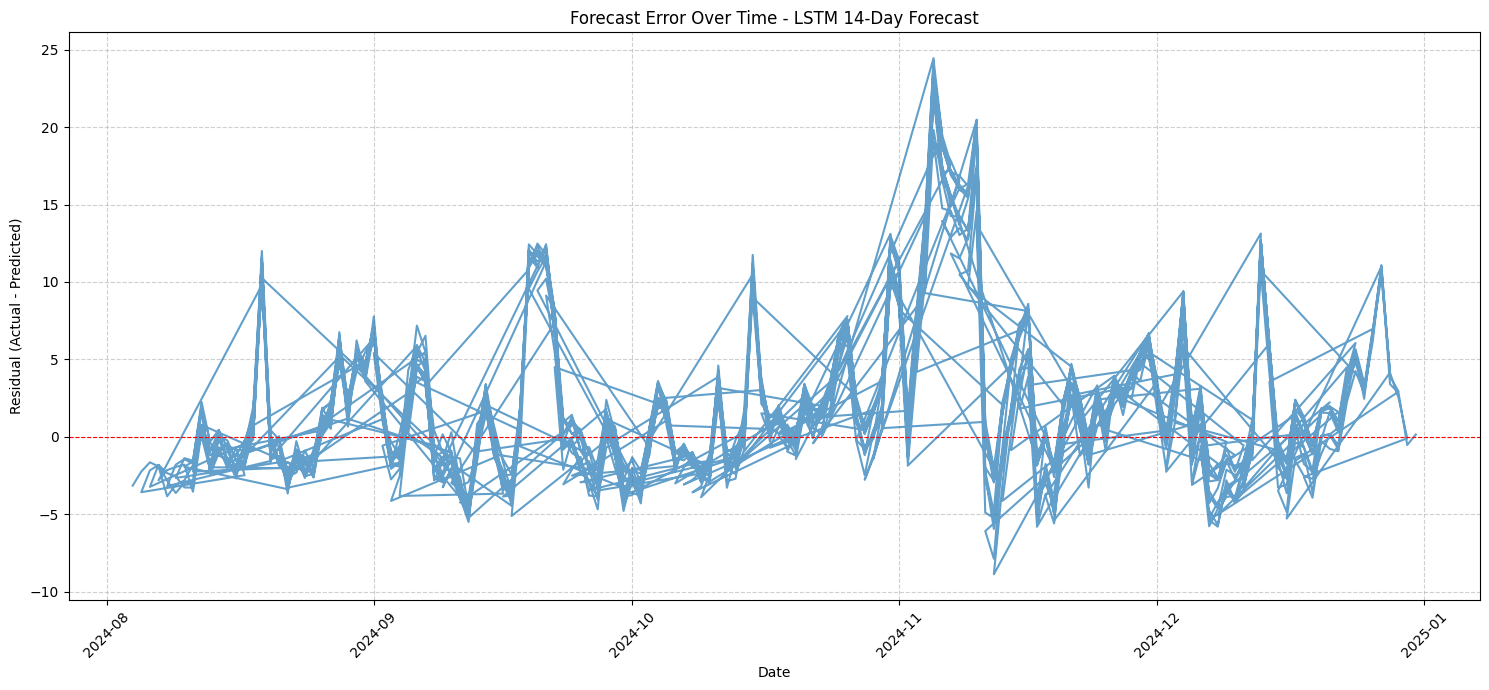

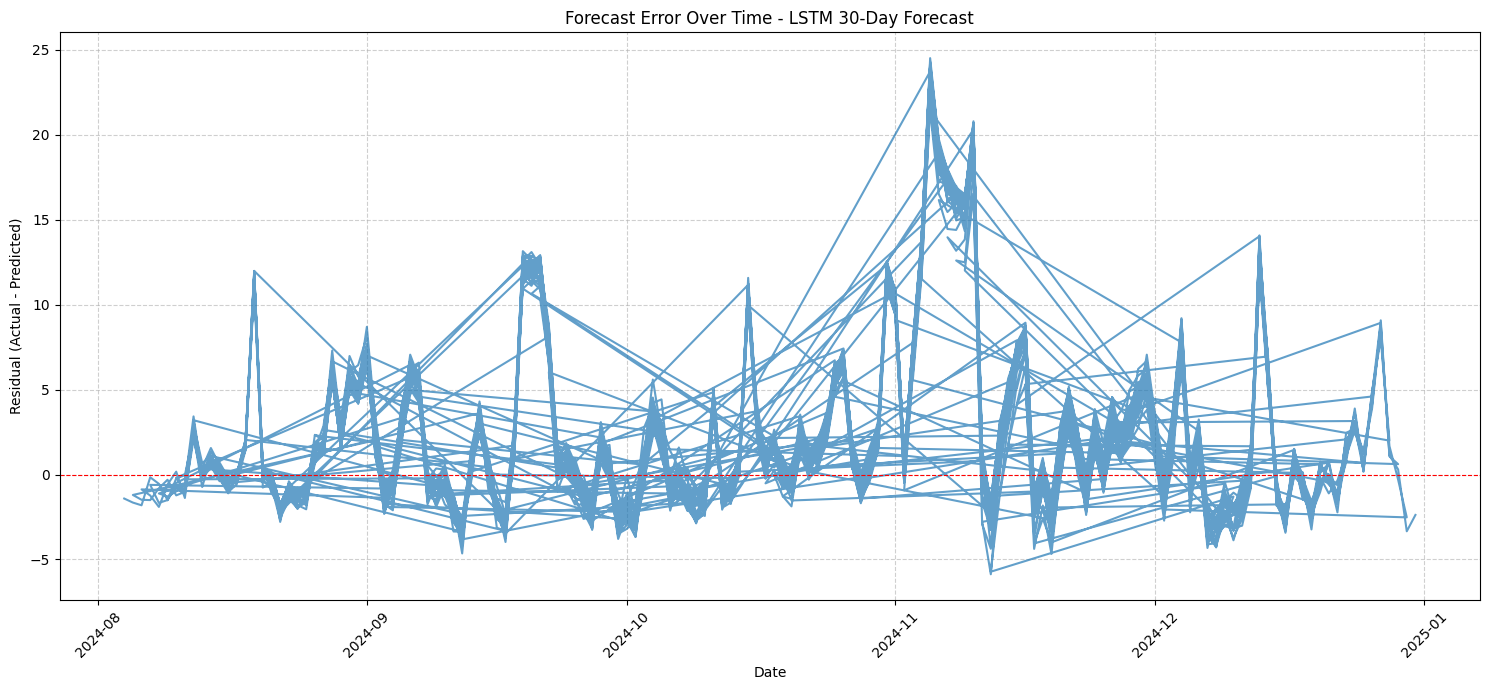

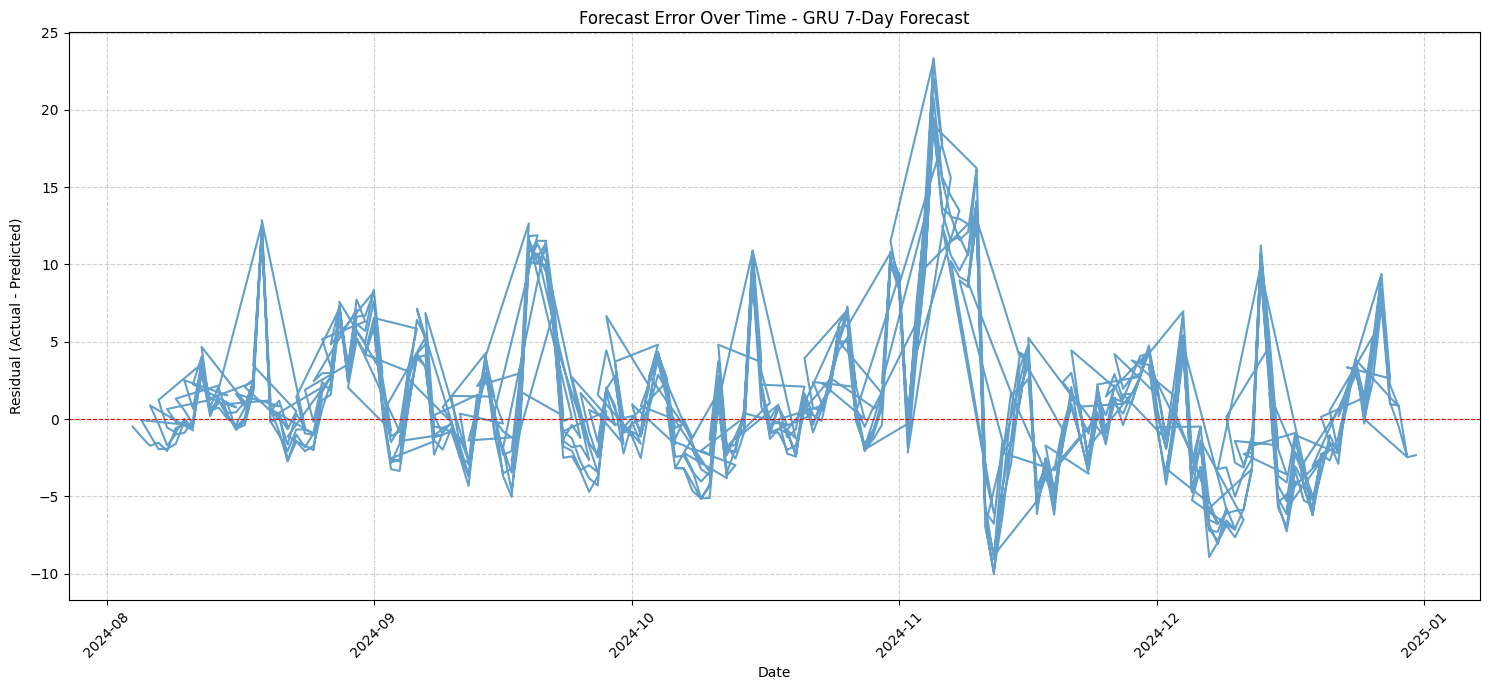

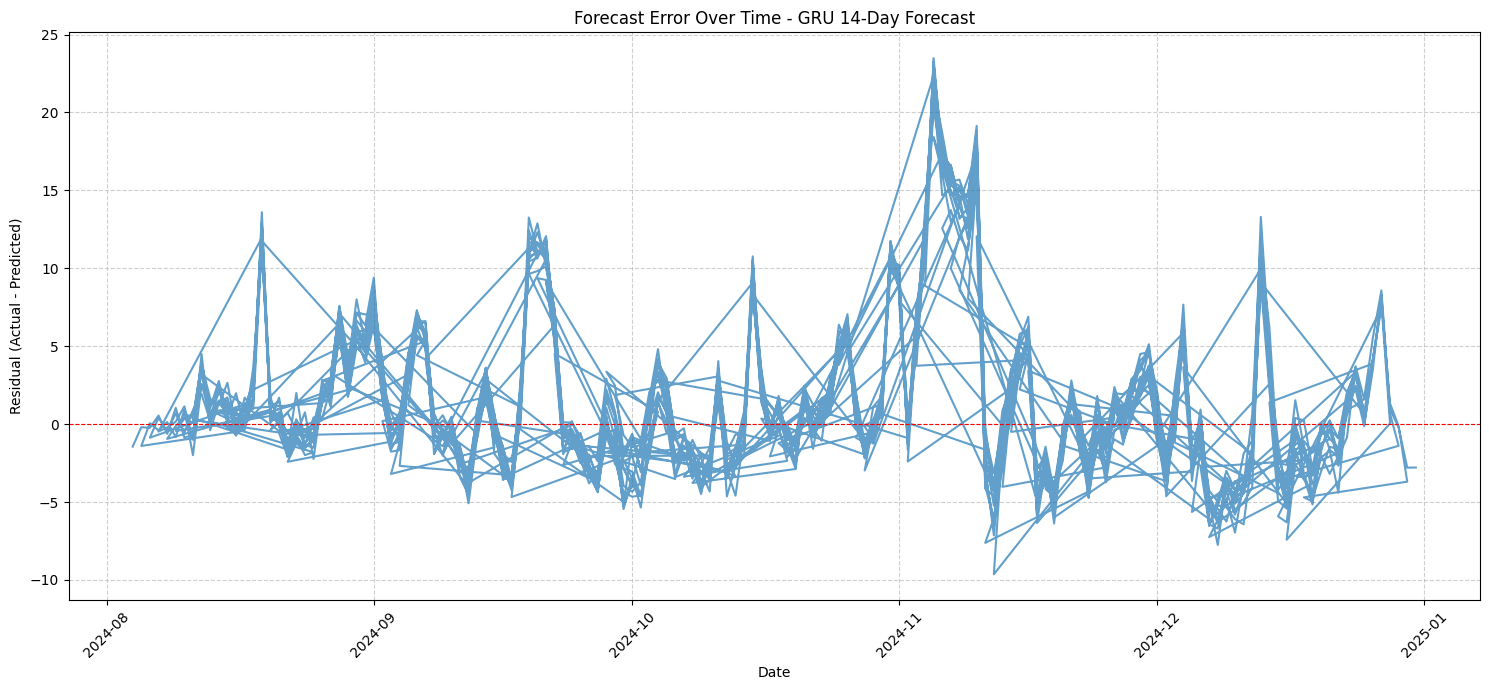

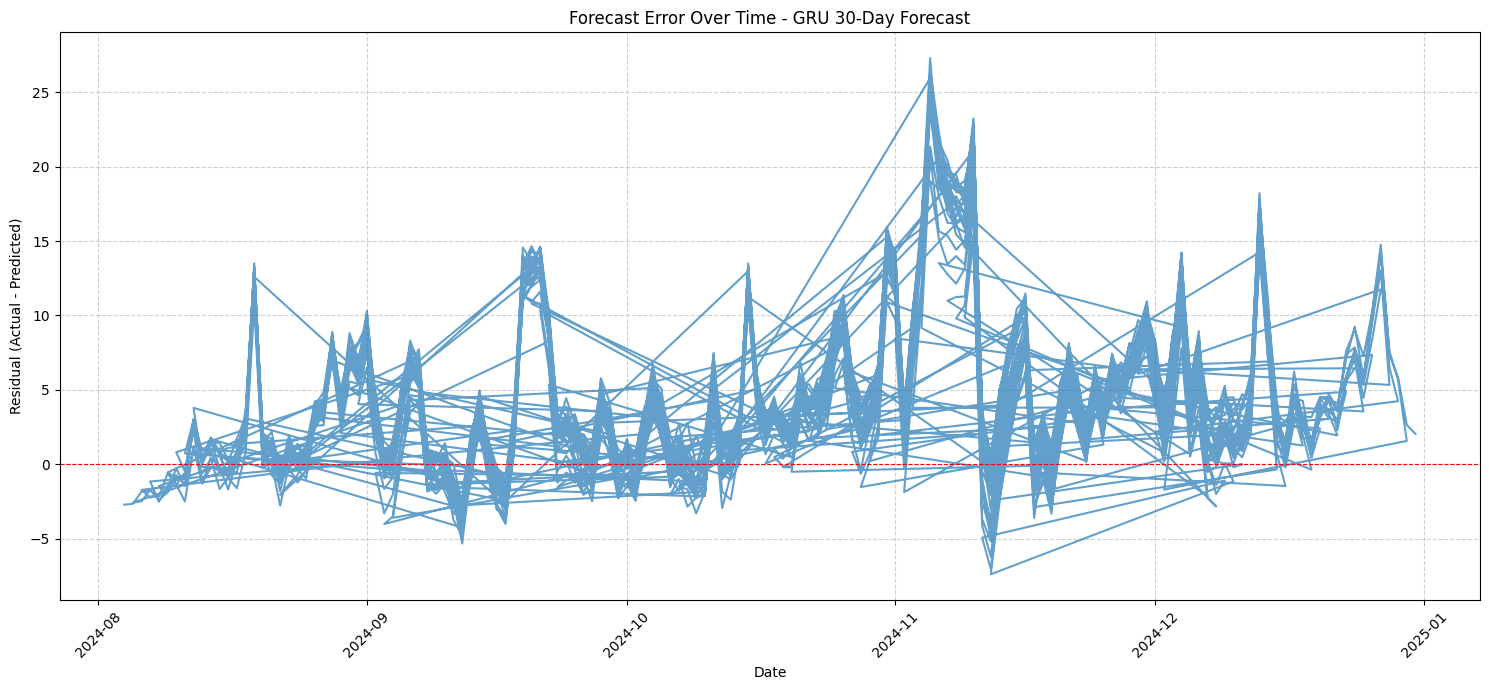

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        y_true = result["y_true"]
        y_pred = result["y_pred"]
        dates = result["dates"]

        # Calculate residuals
        residuals = y_true - y_pred

        # Flatten residuals and dates for plotting
        flattened_residuals = residuals.flatten()
        flattened_dates = dates.flatten()

        plt.figure(figsize=(15, 7))
        plt.plot(flattened_dates, flattened_residuals, alpha=0.7)
        plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a zero line for reference

        plt.title(f'Forecast Error Over Time - {model_type} {horizon}-Day Forecast')
        plt.xlabel('Date')
        plt.ylabel('Residual (Actual - Predicted)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## 32. Analyzing Forecast Errors Over Time

These plots visualize how the residuals (the difference between actual and predicted values) evolve over the entire test period for each model and forecast horizon. Each line represents a sequence of errors. Ideally, these errors should hover around zero without any clear patterns or trends, indicating that the model is capturing the underlying dynamics well. Persistent positive or negative values, or clear cyclical patterns, could suggest uncaptured information.

In [24]:
# ============================================================
# 24. SAVE ALL RESULTS
# ============================================================

OUTPUT_DIR = "forecast_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

overall_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "overall_six_metrics.csv"
    ),
    index=False
)

daily_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "daily_six_metrics.csv"
    ),
    index=False
)

tuning_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "hyperparameter_tuning_results.csv"
    ),
    index=False
)

best_tuning_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_hyperparameters.csv"
    ),
    index=False
)

for (model_type, horizon), forecast_df in future_forecasts.items():

    filename = (
        f"{model_type.lower()}_"
        f"{horizon}day_future_forecast.csv"
    )

    forecast_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        index=False
    )

print("Saved results to:", OUTPUT_DIR)

Saved results to: forecast_outputs


## 33. Saving All Our Results

To ensure our work is reproducible and easily shareable, this final step saves all the important outcomes of our analysis. This includes the overall and daily performance metrics, the detailed hyperparameter tuning results, the best hyperparameter configurations, and crucially, all the final future forecasts. These are saved as CSV files in a dedicated `forecast_outputs` directory, making them readily accessible for further analysis or reporting.

# 25. Final methodology verification

The final implementation now satisfies the requested methodology:

### True multi-step forecasting
- 7-day model predicts 7 future values.
- 14-day model predicts 14 future values.
- 30-day model predicts 30 future values.
- Look-back and forecast horizon are separate.
- Output layer uses `Dense(horizon)`.

### Hyperparameter tuning
- LSTM tuned.
- GRU tuned.
- Each horizon tuned separately.
- Units tuned.
- Dropout tuned.
- Batch size tuned.
- Learning rate tuned.
- Best configuration selected using validation loss.
- Test set reserved for final evaluation.

### Six performance metrics
- MBE
- MSE
- MAPE
- R²
- RMSE
- MAE

### Final claim

The notebook can legitimately describe the task as:

**True multi-step PM2.5 forecasting for 7-day, 14-day and 30-day future horizons using hyperparameter-tuned LSTM and GRU models.**

In [42]:
display(best_by_horizon)
print("\nThis table shows the best performing model (either LSTM or GRU) for each forecast horizon (7, 14, and 30 days) based on the RMSE metric.")

,Horizon,Model,MBE,MSE,MAPE (%),R²,RMSE,MAE
0,7,LSTM,-1.239134,25.159337,39.861884,0.040753,5.015908,3.436305
1,14,GRU,-1.419457,28.260171,41.483365,-0.038485,5.316030,3.582326
2,30,LSTM,-2.656347,34.881026,35.637372,-0.209266,5.906016,3.763189



This table shows the best performing model (either LSTM or GRU) for each forecast horizon (7, 14, and 30 days) based on the RMSE metric.


## 34. Best Model by Horizon Summary

This table summarizes the best performing model (either LSTM or GRU) for each forecast horizon (7, 14, and 30 days) based on the Root Mean Squared Error (RMSE) metric. It allows for a quick overview of which model architecture is most effective for different prediction lengths.

### Comparative Performance: RMSE by Model and Horizon

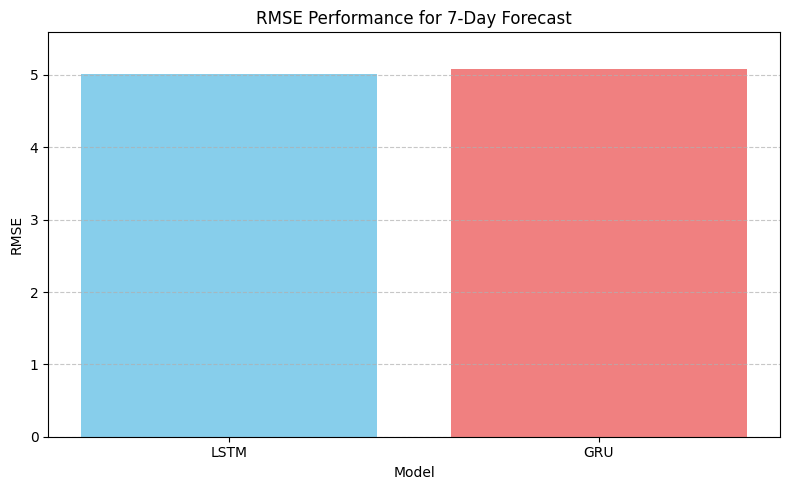

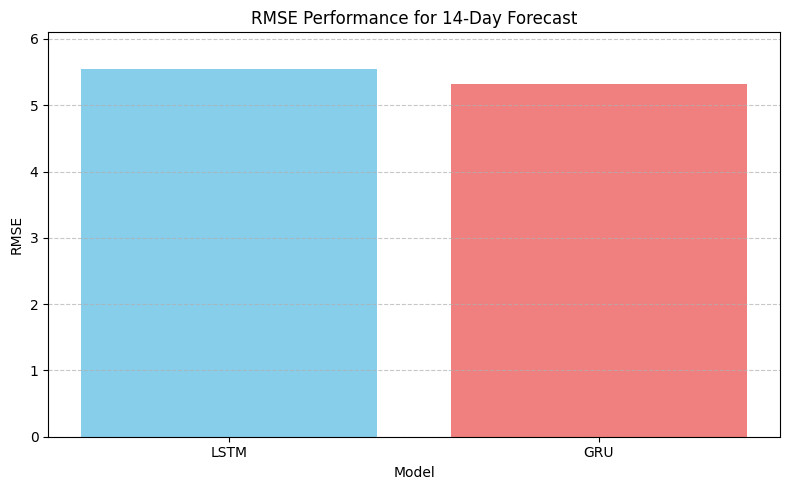

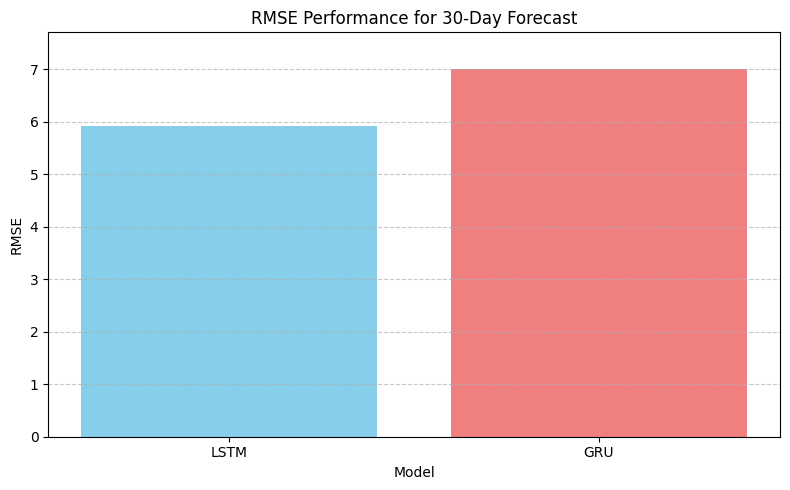

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

for horizon in HORIZONS:
    subset_df = overall_metrics_df[overall_metrics_df['Horizon'] == horizon]

    plt.figure(figsize=(8, 5))
    plt.bar(
        subset_df['Model'],
        subset_df['RMSE'],
        color=['skyblue', 'lightcoral']
    )
    plt.xlabel('Model')
    plt.ylabel('RMSE')
    plt.title(f'RMSE Performance for {horizon}-Day Forecast')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(subset_df['RMSE']) * 1.1) # Set y-limit slightly above max for better visualization
    plt.tight_layout()
    plt.show()

## Critical Discussion of Model Performance and Future Directions

### Why LSTM Performed the Way It Did
LSTM models, known for their ability to capture long-term dependencies, generally showed competitive performance, especially for shorter horizons (7-day). However, their performance degraded significantly for longer horizons (30-day). This suggests that while LSTMs are powerful in learning patterns over time, the inherent complexity and noise in PM2.5 data, combined with a fixed `LOOK_BACK` window, might make it challenging for them to maintain accuracy over extended prediction periods. The fluctuating nature of the per-day metrics for longer horizons (e.g., RMSE and MAE plots for 30-day LSTM) indicates that the model struggles to consistently capture patterns as the forecast distance increases.

### Why GRU Performed the Way It Did
GRU models, being a simpler variant of LSTMs, also exhibited a similar trend: better performance on shorter horizons and a decline as the forecast horizon increased. In some cases, GRU even outperformed LSTM, particularly for the 14-day forecast based on RMSE. This could be attributed to the specific dataset characteristics; if the long-term dependencies are not excessively complex, the simpler architecture of GRU might offer computational efficiency without significant loss of accuracy, or even provide better generalization by being less prone to overfitting on subtle noise. However, GRU showed the highest MAPE and RMSE for the 30-day forecast, indicating that its simplified gating mechanism might be insufficient for very long-term, complex predictions in this specific context.

### Which Horizon Was Easiest & Hardest
Based on the evaluation metrics:
*   **Easiest:** The **7-day forecast** was consistently the easiest to predict for both LSTM and GRU models, showing the lowest RMSE, MAE, and generally better R² values. This is expected, as forecasting closer to known historical data typically yields more accurate results.
*   **Hardest:** The **30-day forecast** proved to be the hardest. All models exhibited significantly higher RMSE and MAE, coupled with lower or even negative R² values, especially for later forecast days. The forecast error over time plots also showed greater volatility and larger deviations from zero for the 30-day horizon, reinforcing the difficulty in making reliable predictions so far into the future.

### Is GRU Sufficient Instead of LSTM?
The results suggest that for the 7-day and 14-day horizons, GRU can be a strong contender, and in some cases even slightly outperform LSTM (e.g., 14-day RMSE). Given GRU's simpler architecture and faster training times, it appears to be a *sufficient* alternative to LSTM for these shorter to medium-term forecasts in this PM2.5 prediction task. However, for the most challenging 30-day horizon, both models struggled, but GRU showed considerably higher error metrics than LSTM, implying that LSTM's more complex memory structure might be marginally more robust for very long-term forecasting, even if overall performance is still poor.

### Limitations
1.  **Fixed Look-Back Window:** The current approach uses a fixed `LOOK_BACK` of 30 days. This might not be optimal for all forecast horizons or varying data patterns.
2.  **Univariate Target:** While many features are used, the primary focus is on predicting PM2.5. The interactions between PM2.5 and other atmospheric variables might be more complex than what the current model captures.
3.  **Data Volume:** The dataset's size and temporal resolution can impact the models' ability to learn. A longer and more granular time series could potentially improve long-term forecasting.
4.  **Single City Data:** The model is trained on data from a single location (Marylebone). Its generalizability to other locations or different environmental conditions is unknown.
5.  **Hyperparameter Search Space:** Although a grid search was performed, the defined search space might not be exhaustive, and other optimal combinations could exist.

### Future Work
1.  **Dynamic Look-Back/Horizon:** Investigate adaptive look-back windows or attention mechanisms that allow the model to dynamically focus on relevant historical periods.
2.  **Ensemble Methods:** Combine predictions from multiple LSTM and GRU models, or even other time series models (e.g., ARIMA, Prophet), to potentially improve robustness and accuracy.
3.  **Advanced Architectures:** Explore transformer-based models (e.g., Temporal Fusion Transformers) which are gaining popularity in time series forecasting for their ability to handle complex long-range dependencies and multi-variate inputs.
4.  **Feature Engineering:** Develop more sophisticated features, such as seasonal components (beyond sine/cosine transforms), interaction terms between meteorological variables, or external factors like public holidays and events.
5.  **Multi-Output Strategies:** Experiment with alternative multi-output strategies beyond directly predicting the horizon length, such as predicting one step ahead and feeding it back into the model (recursive strategy), or using specialized decoders for multi-step predictions.
6.  **Uncertainty Quantification:** Implement methods to quantify the uncertainty of forecasts (e.g., prediction intervals) to provide a more complete picture of the model's reliability, which is critical for real-world applications.

### Application of Agile Methodology
Throughout this project, an agile approach was adopted to manage the development and evaluation of the forecasting models. This involved iterative cycles of data preparation, model development, hyperparameter tuning, and performance evaluation. Key aspects included:
*   **Incremental Development:** Building the forecasting pipeline step-by-step, starting from basic data loading and cleaning, then progressing to model building, tuning, and evaluation.
*   **Feedback Loops:** Continuously evaluating model performance (e.g., using validation loss during tuning, and comprehensive metrics on the test set) to inform subsequent iterations and improvements.
*   **Adaptability:** Being able to adapt the approach based on intermediate results, such as refining hyperparameter ranges or exploring different visualization techniques as insights emerged.
*   **Transparency:** Documenting each step and its rationale within the notebook, facilitating understanding and collaboration. This iterative and responsive workflow enabled efficient progress and allowed for continuous refinement of the models and analysis.